In [2]:
# %%
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
from scipy.optimize import minimize
import time
import warnings
warnings.filterwarnings('ignore')
import matplotlib as mpl
mpl.rc('text', usetex=True)
mpl.rc('text.latex', preamble=r'''
    \usepackage[utf8]{inputenc}
    \usepackage{amsmath,amsfonts}
''')
mpl.rc('font', **{'family':'serif','serif':['Computer Modern']})
mpl.rcParams.update({'font.size':16})
print("✓ 导入库完成")

# %%
# 定义双摆动力学类（与三步优化器兼容）
class DoublePendulumDynamics:
    """双摆动力学模型"""
    def __init__(self, m1=1.0, m2=1.0, l1=1.0, l2=1.0, g=9.81):
        self.m1, self.m2 = m1, m2
        self.l1, self.l2 = l1, l2
        self.g = g

    def f(self, state, u):
        """动力学方程 dx/dt = f(x, u)"""
        θ1, θ2, ω1, ω2 = state
        Δ = θ2 - θ1
        
        # 质量矩阵
        M11 = (self.m1 + self.m2) * self.l1**2
        M12 = self.m2 * self.l1 * self.l2 * np.cos(Δ)
        M21 = M12
        M22 = self.m2 * self.l2**2
        
        # 科里奥利和离心力
        C1 = -self.m2 * self.l1 * self.l2 * (2*ω1*ω2 + ω2**2) * np.sin(Δ)
        C2 = self.m2 * self.l1 * self.l2 * ω1**2 * np.sin(Δ)
        
        # 重力项
        G1 = -(self.m1 + self.m2) * self.g * self.l1 * np.sin(θ1)
        G2 = -self.m2 * self.g * self.l2 * np.sin(θ2)
        
        # 求解关节加速度
        M = np.array([[M11, M12], [M21, M22]])
        CG = np.array([C1 + G1, C2 + G2])
        
        try:
            dd = np.linalg.solve(M, u - CG)
        except np.linalg.LinAlgError:
            # 如果矩阵奇异，使用伪逆
            dd = np.linalg.pinv(M) @ (u - CG)
        
        return np.array([ω1, ω2, dd[0], dd[1]])

    def rk4_step(self, state, u, dt):
        """四阶龙格-库塔积分"""
        k1 = self.f(state, u)
        k2 = self.f(state + dt/2*k1, u)
        k3 = self.f(state + dt/2*k2, u)
        k4 = self.f(state + dt*k3, u)
        return state + dt/6*(k1 + 2*k2 + 2*k3 + k4)

print("✓ 动力学模型定义完成")

# %%
# 加载MPC轨迹数据集
try:
    # 尝试加载数据文件
    mpc_data = np.load('mpc_trajectories.npy')
    print(f"✓ 成功加载数据文件")
    print(f"  数据形状: {mpc_data.shape}")
    print(f"  数据格式: (轨迹数, 时间步, 状态+控制维度)")
    
    # 检查数据格式
    if len(mpc_data.shape) == 3 and mpc_data.shape[2] == 6:
        print(f"  ✓ 数据格式正确: {mpc_data.shape[0]} 轨迹, {mpc_data.shape[1]} 时间步, 6维 (4状态+2控制)")
    else:
        print(f"  ⚠ 数据格式可能不正确，期望 (N, T, 6)，实际 {mpc_data.shape}")
        
except FileNotFoundError:
    print("❌ 找不到 'mpc_trajectories.npy' 文件")
    print("请确保文件在当前目录下，或者修改文件路径")
    mpc_data = None
except Exception as e:
    print(f"❌ 加载数据时出错: {e}")
    mpc_data = None

# %%
# 将MPC数据转换为三步优化器期望的格式
if mpc_data is not None:
    # 选择前20条轨迹进行测试
    N_TEST_TRAJECTORIES = min(20, mpc_data.shape[0])
    
    # 创建generated_trajectories列表（三步优化器期望的格式）
    generated_trajectories = []
    
    for i in range(N_TEST_TRAJECTORIES):
        trajectory_data = mpc_data[i]  # 形状: (100, 6)
        
        # 分离状态和控制
        states = trajectory_data[:, :4]    # (100, 4) - θ1, θ2, ω1, ω2
        controls = trajectory_data[:, 4:]  # (100, 2) - τ1, τ2
        
        # 创建轨迹字典
        trajectory_dict = {
            'states': states,
            'controls': controls
        }
        
        generated_trajectories.append(trajectory_dict)
    
    print(f"✓ 数据转换完成")
    print(f"  转换了 {N_TEST_TRAJECTORIES} 条轨迹")
    print(f"  每条轨迹: 状态 {generated_trajectories[0]['states'].shape}, 控制 {generated_trajectories[0]['controls'].shape}")
    
    # 数据统计
    print(f"\n📊 数据集统计:")
    all_states = np.concatenate([traj['states'] for traj in generated_trajectories], axis=0)
    all_controls = np.concatenate([traj['controls'] for traj in generated_trajectories], axis=0)
    
    print(f"  状态范围:")
    print(f"    θ1: [{all_states[:,0].min():.3f}, {all_states[:,0].max():.3f}] rad")
    print(f"    θ2: [{all_states[:,1].min():.3f}, {all_states[:,1].max():.3f}] rad") 
    print(f"    ω1: [{all_states[:,2].min():.3f}, {all_states[:,2].max():.3f}] rad/s")
    print(f"    ω2: [{all_states[:,3].min():.3f}, {all_states[:,3].max():.3f}] rad/s")
    
    print(f"  控制范围:")
    print(f"    τ1: [{all_controls[:,0].min():.3f}, {all_controls[:,0].max():.3f}] N⋅m")
    print(f"    τ2: [{all_controls[:,1].min():.3f}, {all_controls[:,1].max():.3f}] N⋅m")
    
else:
    print("❌ 无法转换数据，请先正确加载数据文件")
    generated_trajectories = None

# %%
# 验证数据和检查安全性（可选）
if generated_trajectories is not None:
    print("🔍 验证数据完整性...")
    
    # 创建一个临时的优化器来计算末端执行器位置
    dyn_temp = DoublePendulumDynamics()
    
    def forward_kinematics_temp(state, l1=1.0, l2=1.0):
        """临时前向运动学函数"""
        θ1, θ2 = state[0], state[1]
        x1 = l1 * np.sin(θ1)
        y1 = -l1 * np.cos(θ1)
        x2 = x1 + l2 * np.sin(θ2)
        y2 = y1 - l2 * np.cos(θ2)
        return x2, y2
    
    # 检查几条轨迹的安全性
    obstacle_x = -0.25  # 测试障碍位置
    safety_stats = []
    
    for i in range(min(5, len(generated_trajectories))):
        traj = generated_trajectories[i]
        states = traj['states']
        
        # 计算末端执行器位置
        ee_positions = []
        for state in states:
            x_ee, y_ee = forward_kinematics_temp(state)
            ee_positions.append([x_ee, y_ee])
        ee_positions = np.array(ee_positions)
        
        # 检查安全违反
        violations = np.sum(ee_positions[:, 0] < obstacle_x)
        safety_stats.append(violations)
        
        print(f"  轨迹 {i}: 末端执行器X范围 [{ee_positions[:,0].min():.3f}, {ee_positions[:,0].max():.3f}], "
              f"违反障碍x={obstacle_x}: {violations}/{len(states)} 次")
    
    total_violations = sum(safety_stats)
    total_timesteps = len(safety_stats) * len(generated_trajectories[0]['states'])
    
    print(f"\n📈 安全性统计 (障碍位置 x={obstacle_x}):")
    print(f"  总违反次数: {total_violations}/{total_timesteps} ({total_violations/total_timesteps*100:.1f}%)")
    print(f"  需要优化的轨迹: {sum(1 for v in safety_stats if v > 0)}/{len(safety_stats)}")

# %%
# 快速功能测试
if generated_trajectories is not None:
    print("🧪 快速功能测试...")
    
    try:
        # 测试动力学方程
        test_state = np.array([np.pi/4, np.pi/3, 0.1, -0.1])
        test_control = np.array([1.0, -0.5])
        
        dyn_test = DoublePendulumDynamics()
        
        # 测试动力学计算
        dx = dyn_test.f(test_state, test_control)
        print(f"  ✓ 动力学方程测试: f({test_state[:2]}, {test_control}) = {dx[:2]}")
        
        # 测试积分
        next_state = dyn_test.rk4_step(test_state, test_control, 0.1)
        print(f"  ✓ RK4积分测试: 下一状态前两维 = {next_state[:2]}")
        
        # 测试前向运动学
        x_ee, y_ee = forward_kinematics_temp(test_state)
        print(f"  ✓ 前向运动学测试: 末端执行器位置 = ({x_ee:.3f}, {y_ee:.3f})")
        
        print("  ✓ 所有功能测试通过")
        
    except Exception as e:
        print(f"  ❌ 功能测试失败: {e}")

# %%
# 准备工作完成提示
print("\n" + "="*60)
print("🎉 准备工作完成！")
print("="*60)

if generated_trajectories is not None:
    print(f"✅ 数据加载成功: {len(generated_trajectories)} 条轨迹已准备就绪")
    print(f"✅ 动力学模型已定义并测试通过")
    print(f"✅ 变量 'generated_trajectories' 已创建，三步优化器可以直接使用")
    print(f"\n🚀 现在可以运行三步式CBF-CLF优化器了！")
    print(f"\n📝 使用建议:")
    print(f"   - 轨迹索引范围: 0-{len(generated_trajectories)-1}")
    print(f"   - 建议障碍位置: -0.3 到 -0.1")
    print(f"   - 推荐测试轨迹: 0, 3, 7, 12, 18 (随机选择)")
else:
    print("❌ 数据准备失败，请检查数据文件")
    print("📋 故障排除:")
    print("   1. 确认 'mpc_trajectories.npy' 文件在当前目录")
    print("   2. 检查文件是否损坏")
    print("   3. 确认数据格式为 (N, T, 6)")

print("="*60)

# %%
# # 可选：可视化一条示例轨迹
# if generated_trajectories is not None:
#     # 选择第一条轨迹进行可视化
#     example_traj = generated_trajectories[0]
#     example_states = example_traj['states']
#     example_controls = example_traj['controls']
    
#     # 计算末端执行器轨迹
#     ee_trajectory = []
#     for state in example_states:
#         x_ee, y_ee = forward_kinematics_temp(state)
#         ee_trajectory.append([x_ee, y_ee])
#     ee_trajectory = np.array(ee_trajectory)
    
#     # 创建可视化
#     fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))
#     fig.suptitle('Example MPC Trajectory (Before Optimization)', fontsize=14)
    
#     time_steps = np.arange(len(example_states)) * 0.1
    
#     # 1. 末端执行器轨迹
#     ax1.plot(ee_trajectory[:, 0], ee_trajectory[:, 1], 'b-', linewidth=2, label='End Effector Path')
#     ax1.scatter(ee_trajectory[0, 0], ee_trajectory[0, 1], c='green', s=100, marker='o', label='Start')
#     ax1.scatter(ee_trajectory[-1, 0], ee_trajectory[-1, 1], c='red', s=100, marker='*', label='End')
    
#     # 添加测试障碍
#     test_obstacle = -0.25
#     ax1.axvline(x=test_obstacle, color='red', linestyle='--', alpha=0.7, label=f'Test Obstacle x={test_obstacle}')
#     ax1.fill_betweenx(ax1.get_ylim(), -3, test_obstacle, alpha=0.2, color='red')
    
#     ax1.set_xlabel('X Position (m)')
#     ax1.set_ylabel('Y Position (m)')
#     ax1.set_title('End Effector Workspace Trajectory')
#     ax1.legend()
#     ax1.grid(True, alpha=0.3)
#     ax1.set_aspect('equal')
    
#     # 2. 关节角度

#     ax2.plot(time_steps, example_states[:, 0], 'b-', label=r'$\theta_1$')
#     ax2.plot(time_steps, example_states[:, 1], 'r-', label=r'$\theta_2$')

#     ax2.axhline(y=np.pi, color='k', linestyle=':', alpha=0.7, label='Target (π)')
#     ax2.set_xlabel('Time (s)')
#     ax2.set_ylabel('Joint Angle (rad)')
#     ax2.set_title('Joint Angles Over Time')
#     ax2.legend()
#     ax2.grid(True, alpha=0.3)
    
#     # 3. 角速度
#     ax3.plot(time_steps, example_states[:, 2], 'b-', label='ω1')
#     ax3.plot(time_steps, example_states[:, 3], 'r-', label='ω2')
#     ax3.axhline(y=0, color='k', linestyle=':', alpha=0.7, label='Target (0)')
#     ax3.set_xlabel('Time (s)')
#     ax3.set_ylabel('Angular Velocity (rad/s)')
#     ax3.set_title('Angular Velocities Over Time')
#     ax3.legend()
#     ax3.grid(True, alpha=0.3)
    
#     # 4. 控制输入
#     ax4.plot(time_steps, example_controls[:, 0], 'g-', label='τ1')
#     ax4.plot(time_steps, example_controls[:, 1], 'm-', label='τ2')
#     ax4.set_xlabel('Time (s)')
#     ax4.set_ylabel('Torque (N⋅m)')
#     ax4.set_title('Control Inputs Over Time')
#     ax4.legend()
#     ax4.grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.show()
    
    # 统计信息
    # violations = np.sum(ee_trajectory[:, 0] < test_obstacle)
    # print(f"示例轨迹统计:")
    # print(f"  初始角度: θ1={example_states[0,0]:.3f}, θ2={example_states[0,1]:.3f}")
    # print(f"  最终角度: θ1={example_states[-1,0]:.3f}, θ2={example_states[-1,1]:.3f}")
    # print(f"  目标角度: θ1=π={np.pi:.3f}, θ2=π={np.pi:.3f}")
    # print(f"  末端执行器X范围: [{ee_trajectory[:,0].min():.3f}, {ee_trajectory[:,0].max():.3f}]")
    # print(f"  障碍违反 (x<{test_obstacle}): {violations}/{len(example_states)} 次")
    # print(f"  平均控制幅度: τ1={np.abs(example_controls[:,0]).mean():.3f}, τ2={np.abs(example_controls[:,1]).mean():.3f}")

✓ 导入库完成
✓ 动力学模型定义完成
✓ 成功加载数据文件
  数据形状: (5000, 100, 6)
  数据格式: (轨迹数, 时间步, 状态+控制维度)
  ✓ 数据格式正确: 5000 轨迹, 100 时间步, 6维 (4状态+2控制)
✓ 数据转换完成
  转换了 20 条轨迹
  每条轨迹: 状态 (100, 4), 控制 (100, 2)

📊 数据集统计:
  状态范围:
    θ1: [0.181, 5.899] rad
    θ2: [0.072, 6.187] rad
    ω1: [-4.333, 7.441] rad/s
    ω2: [-6.822, 5.095] rad/s
  控制范围:
    τ1: [-25.704, 22.515] N⋅m
    τ2: [-23.159, 24.888] N⋅m
🔍 验证数据完整性...
  轨迹 0: 末端执行器X范围 [-1.083, 0.613], 违反障碍x=-0.25: 8/100 次
  轨迹 1: 末端执行器X范围 [-0.917, 1.935], 违反障碍x=-0.25: 9/100 次
  轨迹 2: 末端执行器X范围 [-0.326, 0.999], 违反障碍x=-0.25: 5/100 次
  轨迹 3: 末端执行器X范围 [-0.027, 0.036], 违反障碍x=-0.25: 0/100 次
  轨迹 4: 末端执行器X范围 [-0.610, 0.215], 违反障碍x=-0.25: 5/100 次

📈 安全性统计 (障碍位置 x=-0.25):
  总违反次数: 27/500 (5.4%)
  需要优化的轨迹: 4/5
🧪 快速功能测试...
  ✓ 动力学方程测试: f([0.78539816 1.04719755], [ 1.  -0.5]) = [ 0.1 -0.1]
  ✓ RK4积分测试: 下一状态前两维 = [0.82971861 1.04371852]
  ✓ 前向运动学测试: 末端执行器位置 = (1.573, -1.207)
  ✓ 所有功能测试通过

🎉 准备工作完成！
✅ 数据加载成功: 20 条轨迹已准备就绪
✅ 动力学模型已定义并测试通过
✅ 变量 'generated_trajectories' 已创建，三步优化器可以直

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
from scipy.optimize import minimize
import time
import warnings
warnings.filterwarnings('ignore')

class ThreeStageOptimizer:
    """
    三步式CBF-CLF轨迹优化器
    
    Stage 1: CBF-softCLF - 纯状态修正，CBF硬约束，CLF软约束
    Stage 2: 纯CLF - 纯控制修正，最小化动力学残差
    Stage 3: CBF-CLF联合精细化 - 状态+控制微调，严格约束
    """
    
    def __init__(self, dynamics, dt=0.1, l1=1.0, l2=1.0):
        self.dyn = dynamics
        self.dt = dt
        self.l1 = l1
        self.l2 = l2
        
    def forward_kinematics(self, state):
        """计算末端执行器位置"""
        θ1, θ2 = state[0], state[1]
        x1 = self.l1 * np.sin(θ1)
        y1 = -self.l1 * np.cos(θ1)
        x2 = x1 + self.l2 * np.sin(θ2)
        y2 = y1 - self.l2 * np.cos(θ2)
        return np.array([x2, y2])
    
    def cbf_constraint_value(self, state, x_min, margin=0.05):
        """CBF约束值：>0 安全，<0 违反"""
        end_pos = self.forward_kinematics(state)
        return end_pos[0] - (x_min + margin)
    
    def dynamics_residual(self, x_current, u, x_next_target):
        """动力学残差"""
        x_next_pred = self.dyn.rk4_step(x_current, u, self.dt)
        return x_next_pred - x_next_target
    
    def stage1_cbf_soft_clf(self, states_original, controls_original, x_min,
                        max_iter=300, verbose=True):
        """
        第一阶段：CBF-硬约束 + 最小动力学残差
        - 优化变量：所有 T 步的状态（包括初始状态）
        - 硬约束：∀ t,  x_ee(t) - x_min >= 0
        - 目标：最小化动力学残差
        """
        if verbose:
            print("=== Stage 1: CBF-Hard (State Optimization) ===")
        T = len(states_original)
        n_vars = T * 4  # 每个时刻 4 维状态

        def objective(x_flat):
            states_var = x_flat.reshape(T, 4)
            cost = 0.0
            for t in range(T - 1):
                x_cur = states_var[t]
                u_cur = controls_original[t]
                x_next_var = states_var[t + 1]
                x_next_dyn = self.dyn.rk4_step(x_cur, u_cur, self.dt)
                diff = x_next_var - x_next_dyn
                cost += np.sum(diff**2)
            # 状态正则化，避免漂移过远
            cost += 0.01 * np.sum((states_var - states_original)**2)
            return cost

        def cbf_ineq(x_flat):
            states_var = x_flat.reshape(T, 4)
            # 返回 ∀ t: x_ee(t) - x_min >= 0
            return np.array([
                self.forward_kinematics(states_var[t])[0] - x_min
                for t in range(T)
            ])

        # 构造约束和边界
        constraints = [{'type': 'ineq', 'fun': cbf_ineq}]
        bounds = [(-3*np.pi, 3*np.pi), (-3*np.pi, 3*np.pi),
                  (-25, 25),           (-25, 25)] * T
        x0 = states_original.flatten()

        start_time = time.time()
        result = minimize(
            objective, x0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'maxiter': max_iter, 'ftol': 1e-9, 'eps': 1e-9}
        )
        stage1_time = time.time() - start_time

        if result.success:
            states_opt = result.x.reshape(T, 4)
        else:
            if verbose:
                print("  ⚠ Stage1 未收敛，保留原始状态轨迹")
            states_opt = states_original.copy()

        # 最终检查是否有任何时刻 x_ee < x_min
        violations = sum(
            1 for t in range(T)
            if self.forward_kinematics(states_opt[t])[0] < x_min
        )

        if verbose:
            print(f"  CBF 硬约束违反次数: {violations}/{T}")
            print(f"  优化成功: {result.success}, nit: {result.nit}, 用时: {stage1_time:.2f}s")

        info = {
            'success':    result.success,
            'nit':        result.nit,
            'time':       stage1_time,
            'cbf_violations': violations,
            'objective':  result.fun,
        }
        return states_opt, info

    
    def stage2_pure_clf(self, states_corrected, controls_original, 
                       w_dynamics=1.0, max_iter=200, verbose=True):
        """
        第二步：纯CLF优化
        优化目标：仅修正控制轨迹
        约束：最小化动力学残差
        """
        if verbose:
            print("\n=== Stage 2: Pure CLF (Control Correction) ===")
        
        T = len(states_corrected)
        n_ctrl = T - 1
        # 优化变量：前T-1步控制 (T-1) x 2
        n_vars = n_ctrl * 2
        
        def objective(u_flat):
            """目标函数：最小化动力学残差"""
            controls_var = u_flat.reshape(n_ctrl, 2)
            
            dynamics_cost = 0.0
            for t in range(n_ctrl):
                x_current = states_corrected[t]
                u_current = controls_var[t]
                x_next_target = states_corrected[t+1]
                
                # 计算动力学残差
                residual = self.dynamics_residual(x_current, u_current, x_next_target)
                dynamics_cost += np.sum(residual**2)
            
            # 控制修正正则化（不要偏离原控制太远）
            control_deviation = controls_var - controls_original[:n_ctrl]
            regularization = 0.01 * np.sum(control_deviation**2)
            
            return w_dynamics * dynamics_cost + regularization
        
        # 控制边界
        bounds = [(-25, 25) for _ in range(n_vars)]
        
        # 初始猜测：原始控制
        u0 = controls_original[:n_ctrl].flatten()
        
        if verbose:
            print(f"  优化变量维度: {n_vars}")
            print(f"  目标: 最小化动力学残差")
        
        start_time = time.time()
        result = minimize(
            objective, u0,
            method='L-BFGS-B',
            bounds=bounds,
            options={'maxiter': max_iter, 'ftol': 1e-9}
        )
        stage2_time = time.time() - start_time
        
        if result.success:
            controls_var_opt = result.x.reshape(n_ctrl, 2)
            controls_stage2 = np.vstack([controls_var_opt, controls_original[-1:]])
        else:
            controls_stage2 = controls_original
        
        # 验证动力学一致性
        simulated_states = [states_corrected[0].copy()]
        for t in range(n_ctrl):
            x_next = self.dyn.rk4_step(simulated_states[-1], controls_stage2[t], self.dt)
            simulated_states.append(x_next)
        simulated_states = np.array(simulated_states)
        
        dynamics_error = np.mean(np.linalg.norm(simulated_states - states_corrected, axis=1))
        
        if verbose:
            print(f"  优化时间: {stage2_time:.2f}s")
            print(f"  优化成功: {result.success}")
            print(f"  动力学误差: {dynamics_error:.6f}")
            print(f"  目标函数值: {result.fun:.6f}")
        
        stage2_info = {
            'success': result.success,
            'time': stage2_time,
            'dynamics_error': dynamics_error,
            'objective_value': result.fun,
            'simulated_states': simulated_states
        }
        
        return controls_stage2, stage2_info
    
    def stage3_cbf_clf_refinement(self, states_stage1, controls_stage2, x_min,
                                  w_state=0.1, w_ctrl=0.1, w_dynamics=100.0, w_cbf=500.0,
                                  dynamics_threshold=1e-2, max_iter=2, verbose=True):
        """
        第三步：CBF-CLF 联合精细化（使用 trust-constr 提升质量）
        - 优化变量：T-1 步的状态微调 + T-1 步的控制微调
        - 硬约束1：动力学残差 ≤ dynamics_threshold
        - 硬约束2：末端执行器 x_ee ≥ x_min
        - 目标：状态+控制微调正则化 + 动力学误差 + CBF 软罚项
        """
        if verbose:
            print("\n=== Stage 3: CBF-CLF Joint Refinement (trust-constr) ===")

        T = len(states_stage1)
        n_ctrl = T - 1
        n_states_var   = (T-1) * 4
        n_controls_var = n_ctrl * 2
        n_vars = n_states_var + n_controls_var

        # Objective: 微调正则 + 动力学 + CBF 软罚
        def objective(x):
            st_var = x[:n_states_var].reshape(T-1, 4)
            ct_var = x[n_states_var:].reshape(n_ctrl, 2)
            states_full = np.vstack([states_stage1[0:1], st_var])

            cost = 0.0
            # 状态/控制正则
            cost += w_state   * np.sum((st_var - states_stage1[1:])**2)
            cost += w_ctrl    * np.sum((ct_var - controls_stage2[:n_ctrl])**2)
            # 动力学一致性
            dyn_cost = 0.0
            for t in range(n_ctrl):
                res = self.dynamics_residual(states_full[t], ct_var[t], states_full[t+1])
                dyn_cost += np.sum(res**2)
            cost += w_dynamics * dyn_cost
            # CBF 软罚：对违反项平方
            cbf_cost = 0.0
            for t in range(T):
                val = self.cbf_constraint_value(states_full[t], x_min, margin=0.0)
                if val < 0:
                    cbf_cost += val**2
            cost += w_cbf * cbf_cost
            return cost

        # 动力学硬约束：|residual| ≤ threshold
        def dyn_constr(x):
            st_var = x[:n_states_var].reshape(T-1, 4)
            ct_var = x[n_states_var:].reshape(n_ctrl, 2)
            states_full = np.vstack([states_stage1[0:1], st_var])
            residuals = []
            for t in range(n_ctrl):
                res = self.dynamics_residual(states_full[t], ct_var[t], states_full[t+1])
                residuals.extend(res)
            return dynamics_threshold - np.abs(np.array(residuals))

        # CBF 硬约束：∀ t, x_ee - x_min ≥ 0
        def cbf_constr(x):
            st_var = x[:n_states_var].reshape(T-1, 4)
            states_full = np.vstack([states_stage1[0:1], st_var])
            return np.array([
                self.forward_kinematics(states_full[t])[0] - x_min
                for t in range(T)
            ])

        constraints = [
            {'type': 'ineq', 'fun': dyn_constr},
            {'type': 'ineq', 'fun': cbf_constr}
        ]

        # 边界：状态微调范围 + 控制微调范围
        bounds = []
        for _ in range(T-1):
            bounds += [(-3*np.pi, 3*np.pi),
                       (-3*np.pi, 3*np.pi),
                       (-20, 20),
                       (-20, 20)]
        for _ in range(n_ctrl):
            bounds += [(-20, 20), (-20, 20)]

        # 初始猜测：stage1 状态 + stage2 控制
        x0 = np.concatenate([
            states_stage1[1:].flatten(),
            controls_stage2[:n_ctrl].flatten()
        ])

        start_time = time.time()
        result = minimize(
            objective, x0,
            method='trust-constr',
            bounds=bounds,
            constraints=constraints,
            options={
                'maxiter': max_iter,
                'gtol': 1e-8,
                'verbose': 2
            }
        )
        stage3_time = time.time() - start_time

        # 解析输出
        if result.success:
            st_opt = result.x[:n_states_var].reshape(T-1, 4)
            ct_opt = result.x[n_states_var:].reshape(n_ctrl, 2)
            states_final   = np.vstack([states_stage1[0:1], st_opt])
            controls_final = np.vstack([ct_opt, controls_stage2[-1:]])
        else:
            if verbose:
                print("  ⚠ Stage3 未收敛，使用 Stage1/2 结果")
            states_final   = states_stage1
            controls_final = controls_stage2

        # 最终验证
        sim_states = [states_final[0].copy()]
        for t in range(n_ctrl):
            sim_states.append(self.dyn.rk4_step(sim_states[-1], controls_final[t], self.dt))
        sim_states = np.array(sim_states)
        final_dyn_err = np.mean(np.linalg.norm(sim_states - states_final, axis=1))
        final_cbf_viol = sum(
            1 for t in range(T)
            if self.forward_kinematics(states_final[t])[0] < x_min
        )

        if verbose:
            print(f"  Stage3 用时: {stage3_time:.2f}s, 成功: {result.success}, nit: {result.nit}")
            print(f"  最终动力学误差: {final_dyn_err:.4e}, 最终 CBF 违反: {final_cbf_viol}/{T}")

        info = {
            'success':        result.success,
            'nit':            result.nit,
            'time':           stage3_time,
            'dynamics_error': final_dyn_err,
            'cbf_violations': final_cbf_viol,
            'objective':      result.fun
        }
        return states_final, controls_final, info
    
    def optimize_three_stage(self, states_original, controls_original, x_min=-0.2, verbose=True):
        """
        完整的三步优化流程
        """
        if verbose:
            print("开始三步式CBF-CLF轨迹优化")
            print(f"障碍位置: x_min = {x_min}")
            print(f"轨迹长度: {len(states_original)} 步")
            print("="*60)
        
        total_start_time = time.time()
        
        # 第一步：CBF-softCLF
        states_stage1, stage1_info = self.stage1_cbf_soft_clf(
            states_original, controls_original, x_min, verbose=verbose
        )
        
        # 第二步：纯CLF
        controls_stage2, stage2_info = self.stage2_pure_clf(
            states_stage1, controls_original, verbose=verbose
        )
        
        # 第三步：联合精细化
        states_final, controls_final, stage3_info = self.stage3_cbf_clf_refinement(
            states_stage1, controls_stage2, x_min, verbose=verbose
        )
        
        total_time = time.time() - total_start_time
        
        if verbose:
            print(f"\n" + "="*60)
            print("三步优化完成!")
            print(f"总时间: {total_time:.2f}s")
            print(f"各阶段时间: {stage1_info['time']:.2f}s + {stage2_info['time']:.2f}s + {stage3_info['time']:.2f}s")
        
        # 汇总信息
        optimization_summary = {
            'stage1': stage1_info,
            'stage2': stage2_info,
            'stage3': stage3_info,
            'total_time': total_time,
            'overall_success': stage1_info['success'] and stage2_info['success'] and stage3_info['success']
        }
        
        return states_final, controls_final, optimization_summary


def test_three_stage_on_fm_trajectory(trajectory_index=0, x_min=-0.25):
    """
    对FM生成的轨迹进行三步优化测试
    
    参数:
    - trajectory_index: 要优化的轨迹索引 (0-99)
    - x_min: 障碍位置
    """
    # 动力学模型定义
    class DoublePendulumDynamics:
        def __init__(self, m1=1.0, m2=1.0, l1=1.0, l2=1.0, g=9.81):
            self.m1, self.m2 = m1, m2
            self.l1, self.l2 = l1, l2
            self.g = g

        def f(self, state, u):
            θ1, θ2, ω1, ω2 = state
            Δ = θ2 - θ1
            M11 = (self.m1 + self.m2) * self.l1**2
            M12 = self.m2 * self.l1 * self.l2 * np.cos(Δ)
            M21 = M12
            M22 = self.m2 * self.l2**2
            C1 = -self.m2 * self.l1 * self.l2 * (2*ω1*ω2 + ω2**2) * np.sin(Δ)
            C2 = self.m2 * self.l1 * self.l2 * ω1**2 * np.sin(Δ)
            G1 = -(self.m1 + self.m2) * self.g * self.l1 * np.sin(θ1)
            G2 = -self.m2 * self.g * self.l2 * np.sin(θ2)
            M = np.array([[M11, M12],[M21, M22]])
            dd = np.linalg.inv(M) @ (u - np.array([C1, C2]) - np.array([G1, G2]))
            return np.array([ω1, ω2, dd[0], dd[1]])

        def rk4_step(self, state, u, dt):
            k1 = self.f(state, u)
            k2 = self.f(state + dt/2*k1, u)
            k3 = self.f(state + dt/2*k2, u)
            k4 = self.f(state + dt*k3, u)
            return state + dt/6*(k1 + 2*k2 + 2*k3 + k4)
    
    print(f"=== 使用FM生成轨迹进行三步优化测试 ===")
    print(f"轨迹索引: {trajectory_index}")
    print(f"障碍位置: x_min = {x_min}")
    
    # 确保我们有FM生成的轨迹数据
    try:
        # 使用用户已有的generated_trajectories数据
        fm_trajectory = generated_trajectories[trajectory_index]
        states_original = fm_trajectory['states']
        controls_original = fm_trajectory['controls']
        
        print(f"✓ 成功加载FM轨迹 {trajectory_index}")
        print(f"  状态轨迹形状: {states_original.shape}")
        print(f"  控制轨迹形状: {controls_original.shape}")
        
    except (NameError, IndexError) as e:
        print(f"❌ 无法获取FM轨迹数据: {e}")
        print("请确保已经运行过FM生成代码并有generated_trajectories变量")
        return None
    
    # 初始化动力学和优化器
    dyn = DoublePendulumDynamics()
    optimizer = ThreeStageOptimizer(dyn, dt=0.1)
    
    # 检查原始轨迹的安全性
    original_ee_positions = []
    for state in states_original:
        ee_pos = optimizer.forward_kinematics(state)
        original_ee_positions.append(ee_pos)
    original_ee_positions = np.array(original_ee_positions)
    
    original_violations = np.sum(original_ee_positions[:, 0] < x_min)
    print(f"\n原始轨迹分析:")
    print(f"  CBF违反次数: {original_violations}/{len(states_original)}")
    print(f"  末端执行器X范围: [{original_ee_positions[:, 0].min():.3f}, {original_ee_positions[:, 0].max():.3f}]")
    
    if original_violations == 0:
        print("  ✓ 原始轨迹已经安全，仍将进行优化以展示方法")
    else:
        print(f"  ⚠ 原始轨迹违反安全约束，需要优化")
    
    # 执行三步优化
    print(f"\n开始三步优化...")
    states_optimized, controls_optimized, optimization_summary = optimizer.optimize_three_stage(
        states_original, controls_original, x_min=x_min, verbose=True
    )
    
    return states_original, controls_original, states_optimized, controls_optimized, optimization_summary, optimizer

# 可视化函数
def visualize_optimization_results(states_original, controls_original, 
                                 states_optimized, controls_optimized, 
                                 optimization_summary, optimizer, x_min=-0.25):
    """
    可视化优化结果，对比原始轨迹、优化后的状态轨迹和仿真轨迹
    """
    T = len(states_original)
    time_steps = np.arange(T) * 0.1
    
    # 计算末端执行器位置
    def compute_ee_trajectory(states):
        ee_positions = []
        for state in states:
            ee_pos = optimizer.forward_kinematics(state)
            ee_positions.append(ee_pos)
        return np.array(ee_positions)
    
    ee_original = compute_ee_trajectory(states_original)
    ee_optimized = compute_ee_trajectory(states_optimized)
    
    # 仿真优化后的控制
    print("正在仿真优化后的控制序列...")
    simulated_states = [states_optimized[0].copy()]
    for t in range(len(controls_optimized) - 1):
        next_state = optimizer.dyn.rk4_step(simulated_states[-1], controls_optimized[t], 0.1)
        simulated_states.append(next_state)
    simulated_states = np.array(simulated_states)
    ee_simulated = compute_ee_trajectory(simulated_states)
    
    # 创建可视化
    fig, axes = plt.subplots(3, 2, figsize=(18, 14))
    fig.suptitle(f'Three-Stage CBF-CLF Optimization Results (Obstacle at x={x_min})', fontsize=16)
    
    # 1. 末端执行器轨迹对比 (X-Y平面)
    ax = axes[0, 0]
    ax.plot(ee_original[:, 0], ee_original[:, 1], 'b-', linewidth=2.5, alpha=0.8, label='Original (FM Generated)')
    ax.plot(ee_optimized[:, 0], ee_optimized[:, 1], 'r-', linewidth=2.5, label='Optimized (State Trajectory)')
    ax.plot(ee_simulated[:, 0], ee_simulated[:, 1], 'g--', linewidth=2.5, label='Simulated (From Control)')
    
    # 障碍边界
    ax.axvline(x=x_min, color='black', linestyle='-', linewidth=3, alpha=0.9, label=f'Obstacle Boundary')
    y_min, y_max = ax.get_ylim()
    ax.fill_betweenx([y_min, y_max], -3, x_min, alpha=0.3, color='red', label='Forbidden Zone')
    
    # 标记起点和终点
    ax.scatter(ee_original[0,0], ee_original[0,1], c='blue', s=120, marker='o', zorder=5, edgecolor='white')
    ax.scatter(ee_original[-1,0], ee_original[-1,1], c='blue', s=120, marker='*', zorder=5, edgecolor='white')
    ax.scatter(ee_optimized[-1,0], ee_optimized[-1,1], c='red', s=120, marker='*', zorder=5, edgecolor='white')
    ax.scatter(ee_simulated[-1,0], ee_simulated[-1,1], c='green', s=120, marker='*', zorder=5, edgecolor='white')
    
    ax.set_xlabel('X Position (m)', fontsize=12)
    ax.set_ylabel('Y Position (m)', fontsize=12)
    ax.set_title('End Effector Trajectories in Workspace', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # 2. X位置随时间变化
    ax = axes[0, 1]
    ax.plot(time_steps, ee_original[:, 0], 'b-', linewidth=2.5, alpha=0.8, label='Original (FM)')
    ax.plot(time_steps, ee_optimized[:, 0], 'r-', linewidth=2.5, label='Optimized (State)')
    ax.plot(time_steps, ee_simulated[:, 0], 'g--', linewidth=2.5, label='Simulated (Control)')
    ax.axhline(y=x_min, color='black', linestyle='-', linewidth=3, alpha=0.9, label='Safety Boundary')
    ax.fill_between(time_steps, -3, x_min, alpha=0.3, color='red')
    
    # 标记违反区域
    original_violations = ee_original[:, 0] < x_min
    optimized_violations = ee_optimized[:, 0] < x_min
    simulated_violations = ee_simulated[:, 0] < x_min
    
    if np.any(original_violations):
        violation_times = time_steps[original_violations]
        ax.scatter(violation_times, ee_original[original_violations, 0], 
                  c='red', s=30, alpha=0.8, marker='x', label=f'Original Violations ({np.sum(original_violations)})')
    
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('X Position (m)', fontsize=12)
    ax.set_title('Safety Constraint Compliance Over Time', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # 3. 关节角度对比
    ax = axes[1, 0]
    ax.plot(time_steps, states_original[:, 0], 'b-', alpha=0.7, linewidth=2, label='Original θ1')
    ax.plot(time_steps, states_original[:, 1], 'b--', alpha=0.7, linewidth=2, label='Original θ2')
    ax.plot(time_steps, states_optimized[:, 0], 'r-', linewidth=2, label='Optimized θ1')
    ax.plot(time_steps, states_optimized[:, 1], 'r--', linewidth=2, label='Optimized θ2')
    ax.plot(time_steps, simulated_states[:, 0], 'g:', linewidth=2, label='Simulated θ1')
    ax.plot(time_steps, simulated_states[:, 1], 'g:', linewidth=2, label='Simulated θ2')
    ax.axhline(y=np.pi, color='black', linestyle=':', alpha=0.7, linewidth=2, label='Target (π)')
    
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Joint Angle (rad)', fontsize=12)
    ax.set_title('Joint Angle Evolution', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # 4. 控制输入对比
    ax = axes[1, 1]
    ax.plot(time_steps, controls_original[:, 0], 'b-', alpha=0.7, linewidth=2, label='Original τ1')
    ax.plot(time_steps, controls_original[:, 1], 'b--', alpha=0.7, linewidth=2, label='Original τ2')
    ax.plot(time_steps, controls_optimized[:, 0], 'r-', linewidth=2, label='Optimized τ1')
    ax.plot(time_steps, controls_optimized[:, 1], 'r--', linewidth=2, label='Optimized τ2')
    
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Torque (N·m)', fontsize=12)
    ax.set_title('Control Input Modification', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # 5. 状态跟踪误差
    ax = axes[2, 0]
    state_error = np.linalg.norm(simulated_states - states_optimized, axis=1)
    ax.plot(time_steps, state_error, 'purple', linewidth=3, label='State-Control Consistency Error')
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('State Error (L2 norm)', fontsize=12)
    ax.set_title('Dynamics Consistency Check', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')
    
    # 添加水平线显示阈值
    ax.axhline(y=1e-3, color='red', linestyle='--', alpha=0.7, label='Good Threshold (1e-3)')
    ax.axhline(y=1e-4, color='green', linestyle='--', alpha=0.7, label='Excellent Threshold (1e-4)')
    ax.legend(fontsize=9)
    
    # 6. 优化过程统计和分析
    ax = axes[2, 1]
    ax.axis('off')
    
    # 计算详细统计信息
    original_cbf_violations = np.sum(ee_original[:, 0] < x_min)
    optimized_cbf_violations = np.sum(ee_optimized[:, 0] < x_min)
    simulated_cbf_violations = np.sum(ee_simulated[:, 0] < x_min)
    
    avg_state_error = np.mean(state_error)
    max_state_error = np.max(state_error)
    final_state_error = state_error[-1]
    
    # 计算改善程度
    cbf_improvement = ((original_cbf_violations - simulated_cbf_violations) / max(original_cbf_violations, 1)) * 100
    
    # 计算最终倒立精度
    target_angles = np.array([np.pi, np.pi])
    final_angle_error = np.linalg.norm(simulated_states[-1, :2] - target_angles)
    
    info_text = f"""Three-Stage Optimization Analysis:

STAGE PERFORMANCE:
  Stage 1 (CBF-softCLF): {'✓' if optimization_summary['stage1']['success'] else '✗'}
    ├─ Time: {optimization_summary['stage1']['time']:.2f}s
    └─ CBF violations: {optimization_summary['stage1']['cbf_violations']}/{T}
    
  Stage 2 (Pure CLF): {'✓' if optimization_summary['stage2']['success'] else '✗'}
    ├─ Time: {optimization_summary['stage2']['time']:.2f}s
    └─ Dynamics error: {optimization_summary['stage2']['dynamics_error']:.6f}
    
  Stage 3 (Joint Refinement): {'✓' if optimization_summary['stage3']['success'] else '✗'}
    ├─ Time: {optimization_summary['stage3']['time']:.2f}s
    └─ Final dynamics: {optimization_summary['stage3']['dynamics_error']:.6f}

TOTAL TIME: {optimization_summary['total_time']:.2f}s

SAFETY PERFORMANCE:
  Original violations: {original_cbf_violations}/{T} ({original_cbf_violations/T*100:.1f}%)
  Final violations: {simulated_cbf_violations}/{T} ({simulated_cbf_violations/T*100:.1f}%)
  Safety improvement: {cbf_improvement:.1f}%

DYNAMICS CONSISTENCY:
  Average error: {avg_state_error:.2e}
  Maximum error: {max_state_error:.2e}
  Final error: {final_state_error:.2e}
  
TASK PERFORMANCE:
  Final angle error: {final_angle_error:.4f} rad
  Inversion success: {'✓' if final_angle_error < 0.2 else '✗'}

OVERALL SUCCESS: {'✓' if optimization_summary['overall_success'] else '✗'}
    """
    
    ax.text(0.05, 0.95, info_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcyan', alpha=0.9, edgecolor='darkblue'))
    
    plt.tight_layout()
    plt.show()
    
    # 打印关键结果摘要
    print(f"\n" + "="*70)
    print(f"🎯 THREE-STAGE OPTIMIZATION SUMMARY")
    print(f"="*70)
    print(f"Safety Improvement:")
    print(f"  ├─ Original CBF violations: {original_cbf_violations}/{T} ({original_cbf_violations/T*100:.1f}%)")
    print(f"  ├─ Optimized violations: {simulated_cbf_violations}/{T} ({simulated_cbf_violations/T*100:.1f}%)")
    print(f"  └─ Improvement: {cbf_improvement:.1f}%")
    print(f"")
    print(f"Dynamics Consistency:")
    print(f"  ├─ Average error: {avg_state_error:.2e}")
    print(f"  ├─ Max error: {max_state_error:.2e}")
    print(f"  └─ Quality: {'Excellent' if avg_state_error < 1e-4 else 'Good' if avg_state_error < 1e-3 else 'Acceptable' if avg_state_error < 1e-2 else 'Poor'}")
    print(f"")
    print(f"Performance:")
    print(f"  ├─ Total time: {optimization_summary['total_time']:.2f}s")
    print(f"  ├─ Final inversion error: {final_angle_error:.4f} rad")
    print(f"  └─ Overall success: {'✅ YES' if optimization_summary['overall_success'] and simulated_cbf_violations == 0 else '❌ NO'}")
    print(f"="*70)

# if __name__ == "__main__":
#     # 选择要优化的轨迹索引和障碍位置
#     TRAJECTORY_INDEX = 5  # 可以修改这个值来测试不同的轨迹 (0-99)
#     X_MIN_OBSTACLE = -0.2  # 障碍位置，可以调整
    
#     print("=== 三步式CBF-CLF优化测试 ===")
#     print(f"将对轨迹 {TRAJECTORY_INDEX} 进行优化")
#     print(f"障碍位置设置为 x = {X_MIN_OBSTACLE}")
    
#     # 运行三步优化测试
#     results = test_three_stage_on_fm_trajectory(
#         trajectory_index=TRAJECTORY_INDEX, 
#         x_min=X_MIN_OBSTACLE
#     )
    
#     if results is not None:
#         states_original, controls_original, states_optimized, controls_optimized, optimization_summary, optimizer = results
        
#         # 可视化结果
#         print(f"\n开始生成可视化结果...")
#         visualize_optimization_results(
#             states_original, controls_original,
#             states_optimized, controls_optimized,
#             optimization_summary, optimizer, x_min=X_MIN_OBSTACLE
#         )
        
#         print(f"\n=== 三步优化完成 ===")
#         print(f"你可以修改 TRAJECTORY_INDEX (0-99) 来测试其他轨迹")
#         print(f"你可以修改 X_MIN_OBSTACLE 来调整障碍位置")
        
#     else:
#         print("❌ 优化测试失败，请检查数据是否正确加载")

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time
from multiprocessing import Pool, cpu_count
from concurrent.futures import ProcessPoolExecutor, as_completed
import warnings
warnings.filterwarnings('ignore')

import numpy as np

import numpy as np
import time

class SimulatedAnnealingCBFCLF:
    """
    基于模拟退火的 CBF-CLF 联合优化器（增强版）
    - 同时惩罚候选状态序列和模拟轨迹的 CBF 违反
    - 添加对齐惩罚，保证状态和模拟后轨迹一致
    - 动态分配搜索资源：安全违规时更多邻域评估，安全时减少评估
    - 支持统一参数 n_neighbors 兼容旧调用
    """
    def __init__(self, dynamics, dt=0.1, l1=1.0, l2=1.0):
        self.dyn = dynamics
        self.dt = dt
        self.l1 = l1
        self.l2 = l2

    def forward_kinematics(self, state):
        θ1, θ2 = state[0], state[1]
        x1 = self.l1 * np.sin(θ1)
        y1 = -self.l1 * np.cos(θ1)
        x2 = x1 + self.l2 * np.sin(θ2)
        y2 = y1 - self.l2 * np.cos(θ2)
        return np.array([x2, y2])

    def simulate(self, initial_state, controls):
        sim_states = [initial_state.copy()]
        for u in controls[:-1]:
            sim_states.append(self.dyn.rk4_step(sim_states[-1], u, self.dt))
        return np.array(sim_states)

    def compute_cost(self, states, controls, states_original, controls_original,
                     x_min, w_cbf_states=1e15, w_cbf_sim=1e15,
                     w_align=1e5, w_dynamics=100.0, w_clf=10.0, w_reg=0.1):
        T = len(states)
        sim_states = self.simulate(states[0], controls)

        cbf_cost_states = 0.0
        cbf_cost_sim = 0.0
        for t in range(T):
            vi = max(0, x_min - self.forward_kinematics(states[t])[0])
            cbf_cost_states += vi**2
            vi2 = max(0, x_min - self.forward_kinematics(sim_states[t])[0])
            cbf_cost_sim += vi2**2

        dyn_cost = 0.0
        for t in range(T-1):
            x_pred = self.dyn.rk4_step(states[t], controls[t], self.dt)
            dyn_cost += np.sum((x_pred - states[t+1])**2)

        target = np.array([np.pi, np.pi, 0, 0])
        clf_cost = np.sum((states[-1] - target)**2)

        align_cost = np.sum((states - sim_states)**2)

        reg_cost = np.sum((states - states_original)**2) + np.sum((controls - controls_original)**2)

        total_cost = (w_cbf_states * cbf_cost_states
                      + w_cbf_sim * cbf_cost_sim
                      + w_align * align_cost
                      + w_dynamics * dyn_cost
                      + w_clf * clf_cost
                      + w_reg * reg_cost)

        components = {
            'cbf_states': cbf_cost_states,
            'cbf_sim': cbf_cost_sim,
            'align': align_cost,
            'dynamics': dyn_cost,
            'clf': clf_cost,
            'reg': reg_cost
        }
        print(f"Cost components: CBF_states={cbf_cost_states:.4e}, CBF_sim={cbf_cost_sim:.4e},"
              f" Align={align_cost:.4e}, Dynamics={dyn_cost:.4e}, CLF={clf_cost:.4e}, Reg={reg_cost:.4e},"
              f" Total={total_cost:.4e}")
        return total_cost, components, sim_states

    def acceptance_probability(self, cost_old, cost_new, temperature):
        if cost_new < cost_old:
            return 1.0
        return np.exp(-(cost_new - cost_old) / temperature)

    def parallel_evaluate_neighbors(self, current_states, current_controls,
                                    states_original, controls_original,
                                    x_min, temperature, n_neighbors):
        neighbors = []
        costs = []
        for _ in range(n_neighbors):
            st_new, ct_new = self.generate_neighbor(current_states, current_controls, temperature)
            c, _, _ = self.compute_cost(st_new, ct_new,
                                        states_original, controls_original, x_min)
            neighbors.append((st_new, ct_new))
            costs.append(c)
        return neighbors, costs

    def optimize_sa(self, states_original, controls_original, x_min=-1.2,
                   T_init=1.0, T_min=0.001, cooling_rate=0.95,
                   max_iter=1000, n_neighbors=8,
                   n_neighbors_violation=None,
                   n_neighbors_no_violation=None,
                   verbose=True):
        if verbose:
            print("=== Enhanced SA CBF-CLF Optimization ===")

        if n_neighbors_violation is None:
            n_neighbors_violation = n_neighbors
        if n_neighbors_no_violation is None:
            n_neighbors_no_violation = max(1, n_neighbors // 4)

        start_time = time.time()
        curr_states = states_original.copy()
        curr_controls = controls_original.copy()
        curr_cost, curr_comp, curr_sim = self.compute_cost(
            curr_states, curr_controls, states_original, controls_original, x_min
        )
        best_states, best_controls, best_cost = curr_states.copy(), curr_controls.copy(), curr_cost

        history = {'costs': [curr_cost], 'temps': [T_init], 'cbf_sim': [curr_comp['cbf_sim']]}
        T = T_init
        it = 0

        while T > T_min and it < max_iter:
            n_nb = n_neighbors_violation if curr_comp['cbf_sim'] > 0 else n_neighbors_no_violation
            neighbors, costs = self.parallel_evaluate_neighbors(
                curr_states, curr_controls,
                states_original, controls_original,
                x_min, T, n_nb
            )
            idx = np.argmin(costs)
            cand_states, cand_controls = neighbors[idx]
            cand_cost = costs[idx]

            ap = self.acceptance_probability(curr_cost, cand_cost, T)
            if np.random.rand() < ap:
                curr_states, curr_controls, curr_cost = cand_states, cand_controls, cand_cost
                _, curr_comp, curr_sim = self.compute_cost(
                    curr_states, curr_controls, states_original, controls_original, x_min
                )
                if curr_cost < best_cost:
                    best_states, best_controls, best_cost = curr_states.copy(), curr_controls.copy(), curr_cost

            history['costs'].append(curr_cost)
            history['temps'].append(T)
            history['cbf_sim'].append(curr_comp['cbf_sim'])

            T *= cooling_rate
            it += 1
            if verbose and it % 50 == 0:
                print(f"Iter {it}: T={T:.4f}, Cost={curr_cost:.4e}, Best={best_cost:.4e}, CBF_sim={curr_comp['cbf_sim']}")

        optimization_time = time.time() - start_time
        best_sim = self.simulate(best_states[0], best_controls)
        cbf_viol = sum(1 for s in best_sim if self.forward_kinematics(s)[0] < x_min)
        dyn_err = np.mean(np.linalg.norm(best_sim - best_states, axis=1))
        if verbose:
            print(f"SA Complete: BestCost={best_cost:.4e}, CBF_viol={cbf_viol}, DynErr={dyn_err:.4e}")

        info = {
            'time': optimization_time,
            'best_cost': best_cost,
            'cbf_violations': cbf_viol,
            'dynamics_error': dyn_err,
            'iterations': it,
            'history': history
        }
        return best_states, best_controls, info

    def generate_neighbor(self, states, controls, temperature, noise_scale=0.1):
        T = len(states)
        new_states = states.copy()
        new_controls = controls.copy()
        s_scale = noise_scale * temperature
        for t in range(1, T):
            new_states[t, :2] += np.random.normal(0, s_scale, 2)
            new_states[t, 2:] += np.random.normal(0, s_scale * 2, 2)
        for t in range(len(controls) - 1):
            new_controls[t] += np.random.normal(0, s_scale * 2, 2)
            new_controls[t] = np.clip(new_controls[t], -25, 25)
        return new_states, new_controls




class JointOptimizer:
    """
    传统的CBF-CLF联合优化器 (使用SLSQP)
    用于对比
    """
    
    def __init__(self, dynamics, dt=0.1, l1=1.0, l2=1.0):
        self.dyn = dynamics
        self.dt = dt
        self.l1 = l1
        self.l2 = l2
    
    def forward_kinematics(self, state):
        """计算末端执行器位置"""
        θ1, θ2 = state[0], state[1]
        x1 = self.l1 * np.sin(θ1)
        y1 = -self.l1 * np.cos(θ1)
        x2 = x1 + self.l2 * np.sin(θ2)
        y2 = y1 - self.l2 * np.cos(θ2)
        return np.array([x2, y2])
    
    def optimize_joint(self, states_original, controls_original, x_min=-0.2,
                      max_iter=200, verbose=True):
        """
        传统的联合优化方法
        同时优化状态和控制
        """
        if verbose:
            print(f"=== Traditional Joint CBF-CLF Optimization ===")
        
        start_time = time.time()
        
        T = len(states_original)
        n_ctrl = T - 1
        
        # 优化变量: [states[1:], controls[:n_ctrl]]
        n_state_vars = (T-1) * 4
        n_control_vars = n_ctrl * 2
        n_vars = n_state_vars + n_control_vars
        
        def objective(x):
            # 解析变量
            states_var = x[:n_state_vars].reshape(T-1, 4)
            controls_var = x[n_state_vars:].reshape(n_ctrl, 2)
            
            # 重构完整状态轨迹
            states_full = np.vstack([states_original[0:1], states_var])
            
            # 计算成本
            cost = 0.0
            
            # 动力学一致性
            for t in range(n_ctrl):
                x_next_pred = self.dyn.rk4_step(states_full[t], controls_var[t], self.dt)
                residual = x_next_pred - states_full[t+1]
                cost += 100 * np.sum(residual ** 2)
            
            # CLF跟踪
            target_state = np.array([np.pi, np.pi, 0, 0])
            cost += 10 * np.sum((states_full[-1] - target_state) ** 2)
            
            # 正则化
            cost += 0.1 * np.sum((states_var - states_original[1:]) ** 2)
            cost += 0.1 * np.sum((controls_var - controls_original[:n_ctrl]) ** 2)
            
            return cost
        
        def cbf_constraint(x):
            states_var = x[:n_state_vars].reshape(T-1, 4)
            states_full = np.vstack([states_original[0:1], states_var])
            
            constraints = []
            for t in range(T):
                ee_pos = self.forward_kinematics(states_full[t])
                constraints.append(ee_pos[0] - x_min)
            return np.array(constraints)
        
        # 约束
        constraints = [{'type': 'ineq', 'fun': cbf_constraint}]
        
        # 边界
        bounds = []
        for _ in range(T-1):
            bounds += [(-3*np.pi, 3*np.pi), (-3*np.pi, 3*np.pi), (-20, 20), (-20, 20)]
        for _ in range(n_ctrl):
            bounds += [(-25, 25), (-25, 25)]
        
        # 初始猜测
        x0 = np.concatenate([
            states_original[1:].flatten(),
            controls_original[:n_ctrl].flatten()
        ])
        
        # 优化
        from scipy.optimize import minimize
        result = minimize(
            objective, x0,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'maxiter': max_iter, 'ftol': 1e-9}
        )
        
        optimization_time = time.time() - start_time
        
        # 解析结果
        if result.success:
            states_opt = result.x[:n_state_vars].reshape(T-1, 4)
            controls_opt = result.x[n_state_vars:].reshape(n_ctrl, 2)
            
            states_final = np.vstack([states_original[0:1], states_opt])
            controls_final = np.vstack([controls_opt, controls_original[-1:]])
        else:
            states_final = states_original
            controls_final = controls_original
        
        # 验证
        simulated_states = [states_final[0].copy()]
        for t in range(len(controls_final) - 1):
            x_next = self.dyn.rk4_step(simulated_states[-1], controls_final[t], self.dt)
            simulated_states.append(x_next)
        simulated_states = np.array(simulated_states)
        
        # 计算指标
        cbf_violations = 0
        for state in simulated_states:
            if self.forward_kinematics(state)[0] < x_min:
                cbf_violations += 1
        
        dynamics_error = np.mean(np.linalg.norm(simulated_states - states_final, axis=1))
        
        if verbose:
            print(f"Optimization time: {optimization_time:.2f}s")
            print(f"Success: {result.success}")
            print(f"CBF violations: {cbf_violations}/{T}")
            print(f"Dynamics error: {dynamics_error:.4e}")
        
        info = {
            'time': optimization_time,
            'success': result.success,
            'cbf_violations': cbf_violations,
            'dynamics_error': dynamics_error,
            'iterations': result.nit,
            'simulated_states': simulated_states
        }
        
        return states_final, controls_final, info


def benchmark_comparison(trajectory_index=0, x_min=-0.25):
    """
    对比三种优化方法的性能
    1. 三阶段优化 (已有)
    2. 模拟退火优化 (新)
    3. 传统联合优化 (对比)
    """
    print(f"=== Benchmark Comparison ===")
    print(f"Trajectory index: {trajectory_index}")
    print(f"Obstacle position: x_min = {x_min}")
    print("="*60)
    
    # 获取原始轨迹
    fm_trajectory = generated_trajectories[trajectory_index]
    states_original = fm_trajectory['states']
    controls_original = fm_trajectory['controls']
    
    # 初始化动力学模型
    dyn = DoublePendulumDynamics()
    
    # 1. 三阶段优化
    # print("\n1. Three-Stage Optimization")
    # print("-"*40)
    # three_stage_opt = ThreeStageOptimizer(dyn, dt=0.1)
    # states_3stage, controls_3stage, info_3stage = three_stage_opt.optimize_three_stage(
    #     states_original, controls_original, x_min=x_min, verbose=False
    # )
    # print(f"Time: {info_3stage['total_time']:.2f}s")
    # print(f"CBF violations: {info_3stage['stage3']['cbf_violations']}")
    # print(f"Dynamics error: {info_3stage['stage3']['dynamics_error']:.4e}")
    
    # 2. 模拟退火优化
    print("\n2. Simulated Annealing Optimization")
    print("-"*40)
    sa_opt = SimulatedAnnealingCBFCLF(dyn, dt=0.1)
    states_sa, controls_sa, info_sa = sa_opt.optimize_sa(
        states_original, controls_original, x_min=x_min,
        T_init=1.0, T_min=0.001, cooling_rate=0.95,
        max_iter=50000, n_neighbors=16, verbose=False
    )
    print(f"Time: {info_sa['time']:.2f}s")
    print(f"CBF violations: {info_sa['cbf_violations']}")
    print(f"Dynamics error: {info_sa['dynamics_error']:.4e}")
    print(f"Iterations: {info_sa['iterations']}")
    
    # 3. 传统联合优化
    # print("\n3. Traditional Joint Optimization")
    # print("-"*40)
    # joint_opt = JointOptimizer(dyn, dt=0.1)
    # states_joint, controls_joint, info_joint = joint_opt.optimize_joint(
    #     states_original, controls_original, x_min=x_min,
    #     max_iter=100, verbose=False
    # )
    # print(f"Time: {info_joint['time']:.2f}s")
    # print(f"CBF violations: {info_joint['cbf_violations']}")
    # print(f"Dynamics error: {info_joint['dynamics_error']:.4e}")
    
    # 返回所有结果用于可视化
    return {
        'original': (states_original, controls_original),
        '3stage': (states_3stage, controls_3stage, info_3stage),
        'sa': (states_sa, controls_sa, info_sa),
        'joint': (states_joint, controls_joint, info_joint),
        'x_min': x_min
    }


def visualize_benchmark_results(results):
    """
    可视化对比结果
    """
    # 提取数据
    states_orig, controls_orig = results['original']
    states_3stage, controls_3stage, info_3stage = results['3stage']
    states_sa, controls_sa, info_sa = results['sa']
    states_joint, controls_joint, info_joint = results['joint']
    x_min = results['x_min']
    
    # 创建图形
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 计算末端执行器轨迹
    def compute_ee_trajectory(states, l1=1.0, l2=1.0):
        ee_positions = []
        for state in states:
            θ1, θ2 = state[0], state[1]
            x1 = l1 * np.sin(θ1)
            y1 = -l1 * np.cos(θ1)
            x2 = x1 + l2 * np.sin(θ2)
            y2 = y1 - l2 * np.cos(θ2)
            ee_positions.append([x2, y2])
        return np.array(ee_positions)
    
    ee_orig = compute_ee_trajectory(states_orig)
    ee_3stage = compute_ee_trajectory(info_3stage['stage3']['simulated_states'] if 'simulated_states' in info_3stage['stage3'] else states_3stage)
    ee_sa = compute_ee_trajectory(info_sa['simulated_states'])
    ee_joint = compute_ee_trajectory(info_joint['simulated_states'])
    
    time_steps = np.arange(len(states_orig)) * 0.1
    
    # 1. 末端执行器轨迹对比
    ax1 = fig.add_subplot(gs[0, :2])
    ax1.plot(ee_orig[:, 0], ee_orig[:, 1], 'k-', linewidth=2, alpha=0.5, label='Original')
    ax1.plot(ee_3stage[:, 0], ee_3stage[:, 1], 'b-', linewidth=2, label='Three-Stage')
    ax1.plot(ee_sa[:, 0], ee_sa[:, 1], 'r-', linewidth=2, label='Simulated Annealing')
    ax1.plot(ee_joint[:, 0], ee_joint[:, 1], 'g-', linewidth=2, label='Joint SLSQP')
    
    ax1.axvline(x=x_min, color='black', linestyle='-', linewidth=3, alpha=0.8)
    ax1.fill_betweenx(ax1.get_ylim(), -3, x_min, alpha=0.2, color='red')
    
    ax1.set_xlabel('X Position (m)')
    ax1.set_ylabel('Y Position (m)')
    ax1.set_title('End Effector Trajectories Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    
    # 2. X位置时间历程
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(time_steps, ee_orig[:, 0], 'k-', alpha=0.5, label='Original')
    ax2.plot(time_steps, ee_3stage[:, 0], 'b-', label='Three-Stage')
    ax2.plot(time_steps, ee_sa[:, 0], 'r-', label='SA')
    ax2.plot(time_steps, ee_joint[:, 0], 'g-', label='Joint')
    ax2.axhline(y=x_min, color='black', linestyle='-', linewidth=2)
    ax2.fill_between(time_steps, -3, x_min, alpha=0.2, color='red')
    
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('X Position (m)')
    ax2.set_title('Safety Constraint Tracking')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. 动力学误差对比
    ax3 = fig.add_subplot(gs[1, 1])
    
    # 计算动力学误差
    def compute_dynamics_error(states, controls, dyn, dt=0.1):
        errors = []
        for t in range(len(controls) - 1):
            x_next_pred = dyn.rk4_step(states[t], controls[t], dt)
            error = np.linalg.norm(x_next_pred - states[t+1])
            errors.append(error)
        return np.array(errors)
    
    dyn = DoublePendulumDynamics()
    
    # 使用仿真后的状态计算误差
    dyn_err_3stage = compute_dynamics_error(info_3stage['stage3']['simulated_states'] if 'simulated_states' in info_3stage['stage3'] else states_3stage, controls_3stage, dyn)
    dyn_err_sa = compute_dynamics_error(info_sa['simulated_states'], controls_sa, dyn)
    dyn_err_joint = compute_dynamics_error(info_joint['simulated_states'], controls_joint, dyn)
    
    ax3.semilogy(time_steps[:-1], dyn_err_3stage, 'b-', label='Three-Stage')
    ax3.semilogy(time_steps[:-1], dyn_err_sa, 'r-', label='SA')
    ax3.semilogy(time_steps[:-1], dyn_err_joint, 'g-', label='Joint')
    
    ax3.set_xlabel('Time (s)')
    ax3.set_ylabel('Dynamics Error (log scale)')
    ax3.set_title('Dynamics Consistency')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. 优化历史 (仅SA)
    ax4 = fig.add_subplot(gs[1, 2])
    sa_history = info_sa['history']
    iterations = np.arange(len(sa_history['costs']))
    
    ax4_twin = ax4.twinx()
    ax4.plot(iterations, sa_history['costs'], 'b-', label='Total Cost')
    ax4_twin.plot(iterations, sa_history['temperatures'], 'r--', label='Temperature')
    
    ax4.set_xlabel('Iteration')
    ax4.set_ylabel('Cost', color='b')
    ax4_twin.set_ylabel('Temperature', color='r')
    ax4.set_title('SA Optimization Progress')
    ax4.tick_params(axis='y', labelcolor='b')
    ax4_twin.tick_params(axis='y', labelcolor='r')
    ax4.grid(True, alpha=0.3)
    
    # 5. 性能对比表格
    ax5 = fig.add_subplot(gs[2, :])
    ax5.axis('off')
    
    # 创建性能对比数据
    perf_data = [
        ['Metric', 'Three-Stage', 'Simulated Annealing', 'Joint SLSQP'],
        ['Optimization Time (s)', f"{info_3stage['total_time']:.2f}", f"{info_sa['time']:.2f}", f"{info_joint['time']:.2f}"],
        ['CBF Violations', f"{info_3stage['stage3']['cbf_violations']}", f"{info_sa['cbf_violations']}", f"{info_joint['cbf_violations']}"],
        ['Avg Dynamics Error', f"{info_3stage['stage3']['dynamics_error']:.2e}", f"{info_sa['dynamics_error']:.2e}", f"{info_joint['dynamics_error']:.2e}"],
        ['Iterations', f"{info_3stage['stage1']['nit'] + info_3stage['stage3']['nit']}", f"{info_sa['iterations']}", f"{info_joint['iterations']}"],
        ['Success', '✓' if info_3stage['overall_success'] else '✗', '✓', '✓' if info_joint['success'] else '✗']
    ]
    
    # 创建表格
    table = ax5.table(cellText=perf_data, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1, 2)
    
    # 设置表头样式
    for i in range(len(perf_data[0])):
        table[(0, i)].set_facecolor('#4CAF50')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    ax5.set_title('Performance Comparison Summary', fontsize=14, fontweight='bold', pad=20)
    
    # 6. 控制输入对比
    ax6 = fig.add_subplot(gs[0, 2])
    ax6.plot(time_steps, controls_orig[:, 0], 'k--', alpha=0.5, label='Original τ1')
    ax6.plot(time_steps, controls_3stage[:, 0], 'b-', alpha=0.7, label='3-Stage τ1')
    ax6.plot(time_steps, controls_sa[:, 0], 'r-', alpha=0.7, label='SA τ1')
    ax6.plot(time_steps, controls_joint[:, 0], 'g-', alpha=0.7, label='Joint τ1')
    
    ax6.set_xlabel('Time (s)')
    ax6.set_ylabel('Control Torque (N·m)')
    ax6.set_title('Control Input Comparison')
    ax6.legend(fontsize=8)
    ax6.grid(True, alpha=0.3)
    
    plt.suptitle('CBF-CLF Optimization Methods Benchmark', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 打印详细对比
    print("\n" + "="*70)
    print("DETAILED PERFORMANCE COMPARISON")
    print("="*70)
    
    print("\nSPEED COMPARISON:")
    print(f"  Three-Stage: {info_3stage['total_time']:.2f}s")
    print(f"  Simulated Annealing: {info_sa['time']:.2f}s ({info_sa['time']/info_3stage['total_time']:.2f}x)")
    print(f"  Joint SLSQP: {info_joint['time']:.2f}s ({info_joint['time']/info_3stage['total_time']:.2f}x)")
    
    print("\nQUALITY COMPARISON:")
    print(f"  CBF Violations: 3-Stage={info_3stage['stage3']['cbf_violations']}, "
          f"SA={info_sa['cbf_violations']}, Joint={info_joint['cbf_violations']}")
    print(f"  Dynamics Error: 3-Stage={info_3stage['stage3']['dynamics_error']:.2e}, "
          f"SA={info_sa['dynamics_error']:.2e}, Joint={info_joint['dynamics_error']:.2e}")
    
    print("\nEFFICIENCY:")
    print(f"  SA uses {info_sa['iterations']} iterations with {16} parallel evaluations per iteration")
    print(f"  Total SA evaluations: ~{info_sa['iterations'] * 16}")
    print(f"  Acceptance rate: {np.mean(info_sa['history']['acceptances']):.2%}")
    
    print("="*70)


# 运行基准测试
if __name__ == "__main__":
    # 确保已经加载了数据
    try:
        # 测试多个轨迹
        test_trajectories = [0, 5, 10]  # 测试多个轨迹索引
        test_obstacles = [-1.0, -1.2, -0.7]  # 测试多个障碍位置
        
        for traj_idx in test_trajectories[:1]:  # 先测试一个
            for x_min in test_obstacles[:1]:
                print(f"\n{'='*80}")
                print(f"Testing trajectory {traj_idx} with obstacle at x={x_min}")
                print(f"{'='*80}")
                
                # 运行基准测试
                results = benchmark_comparison(trajectory_index=traj_idx, x_min=x_min)
                
                # 可视化结果
                visualize_benchmark_results(results)
                
                # 等待用户输入继续
                input("\nPress Enter to continue to next test...")
                
    except NameError:
        print("Error: Please ensure 'generated_trajectories' is loaded first!")
        print("Run the data loading cells before running this benchmark.")


Testing trajectory 0 with obstacle at x=-1.0
=== Benchmark Comparison ===
Trajectory index: 0
Obstacle position: x_min = -1.0

2. Simulated Annealing Optimization
----------------------------------------
Cost components: CBF_states=7.6850e-03, CBF_sim=7.6850e-03, Align=4.8438e-27, Dynamics=5.9930e-31, CLF=4.8157e-08, Reg=0.0000e+00, Total=1.5370e+13
Cost components: CBF_states=1.2840e-04, CBF_sim=9.9408e-03, Align=1.0776e+01, Dynamics=2.3891e+01, CLF=2.9266e-01, Reg=1.7134e+01, Total=1.0069e+13
Cost components: CBF_states=2.8045e-02, CBF_sim=5.0529e-03, Align=1.2174e+01, Dynamics=2.9706e+01, CLF=4.8227e-02, Reg=1.6630e+01, Total=3.3098e+13
Cost components: CBF_states=1.7537e-02, CBF_sim=4.7337e-03, Align=1.8530e+01, Dynamics=3.1631e+01, CLF=2.6260e-01, Reg=1.7203e+01, Total=2.2271e+13
Cost components: CBF_states=7.0693e-02, CBF_sim=4.8919e-03, Align=1.6496e+01, Dynamics=3.0977e+01, CLF=1.7317e-01, Reg=1.7363e+01, Total=7.5585e+13
Cost components: CBF_states=2.9118e-03, CBF_sim=6.4160e

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

class ImprovedTwoStageSACBFCLF:
    """
    改进的两阶段模拟退火CBF-CLF优化器
    主要改进：
    1. 软CBF约束with渐进惩罚
    2. 第二阶段保持CBF约束
    3. 更智能的邻域生成
    4. 更好的成本函数平衡
    """
    def __init__(self, dynamics, dt=0.1, l1=1.0, l2=1.0):
        self.dyn = dynamics
        self.dt = dt
        self.l1 = l1
        self.l2 = l2
        self.cbf_epsilon = 0.01  # CBF软边界

    def forward_kinematics(self, state):
        θ1, θ2 = state[0], state[1]
        x1 = self.l1 * np.sin(θ1)
        y1 = -self.l1 * np.cos(θ1)
        x2 = x1 + self.l2 * np.sin(θ2)
        y2 = y1 - self.l2 * np.cos(θ2)
        return np.array([x2, y2])

    def simulate(self, initial_state, controls):
        sim_states = [initial_state.copy()]
        for u in controls[:-1]:
            sim_states.append(self.dyn.rk4_step(sim_states[-1], u, self.dt))
        return np.array(sim_states)

    def check_cbf_violation(self, states, x_min):
        """检查CBF违反情况"""
        violations = 0
        max_violation = 0.0
        for state in states:
            ee_pos = self.forward_kinematics(state)
            if ee_pos[0] < x_min:
                violations += 1
                max_violation = max(max_violation, x_min - ee_pos[0])
        return violations, max_violation

    def compute_cbf_cost(self, states, x_min):
        """
        改进的CBF成本函数：使用软约束和渐进惩罚
        """
        cbf_cost = 0.0
        for state in states:
            ee_pos = self.forward_kinematics(state)
            # 软约束：使用指数屏障函数
            if ee_pos[0] < x_min + self.cbf_epsilon:
                # 违反程度越大，惩罚越重
                violation = x_min + self.cbf_epsilon - ee_pos[0]
                cbf_cost += 1e4 * np.exp(violation / self.cbf_epsilon)
            elif ee_pos[0] < x_min + 2 * self.cbf_epsilon:
                # 接近边界时给予警告成本
                margin = ee_pos[0] - x_min
                cbf_cost += 100.0 / (margin + 0.001)
        
        return cbf_cost

    # 改进策略：在Stage 1中增强动力学一致性约束

    def compute_stage1_cost(self, states, controls, states_original, controls_original, x_min):
        """
        改进的第一阶段成本函数：更强调动力学一致性
        """
        T = len(states)
        sim_states = self.simulate(states[0], controls)

        # 1. CBF成本（软约束）
        cbf_cost_states = self.compute_cbf_cost(states, x_min)
        cbf_cost_sim = self.compute_cbf_cost(sim_states, x_min)
        cbf_cost = cbf_cost_states + cbf_cost_sim

        # 2. CLF成本：目标跟踪
        target = np.array([np.pi, np.pi, 0, 0])
        clf_error = states[-1] - target
        clf_weights = np.array([10.0, 10.0, 1.0, 1.0])
        clf_cost = np.sum(clf_weights * clf_error**2)

        # 3. 轨迹相似性成本
        state_diff = states - states_original
        control_diff = controls - controls_original
        state_weights = np.array([1.0, 1.0, 0.1, 0.1])
        similarity_cost = (
            5.0 * np.sum(state_weights * state_diff**2) + 
            0.5 * np.sum(control_diff**2)
        )

        # 4. 动力学一致性成本（大幅增加权重）
        dynamics_diff = states - sim_states
        # 使用更高的权重，特别是对角度误差
        dynamics_weights = np.array([100.0, 100.0, 10.0, 10.0])
        dynamics_cost = np.sum(dynamics_weights * dynamics_diff**2)
        
        # 额外惩罚大的动力学误差
        max_dynamics_error = np.max(np.linalg.norm(dynamics_diff, axis=1))
        if max_dynamics_error > 0.1:
            dynamics_cost += 1000.0 * (max_dynamics_error - 0.1)**2

        # 5. 控制平滑性和物理可行性
        control_smooth_cost = 0.0
        for t in range(len(controls) - 2):
            control_smooth_cost += 0.1 * np.sum((controls[t+1] - controls[t])**2)
        
        # 6. 控制努力惩罚（避免过大的控制输入）
        control_effort_cost = 0.01 * np.sum(controls**2)

        total_cost = cbf_cost + clf_cost + similarity_cost + dynamics_cost + control_smooth_cost + control_effort_cost

        components = {
            'cbf': cbf_cost,
            'clf': clf_cost,
            'similarity': similarity_cost,
            'dynamics': dynamics_cost,
            'control_smooth': control_smooth_cost,
            'control_effort': control_effort_cost
        }
        
        return total_cost, components, sim_states
    
    def compute_stage2_cost(self, states_fixed, controls, controls_original, x_min):
        """
        改进的第二阶段成本函数：加入CBF约束检查
        """
        sim_states = self.simulate(states_fixed[0], controls)
        
        # 1. CBF成本（必须检查！）
        cbf_cost = self.compute_cbf_cost(sim_states, x_min)
        
        # 2. 动力学一致性成本（主要目标）
        state_weights = np.array([1.0, 1.0, 0.1, 0.1])
        dynamics_diff = states_fixed - sim_states
        dynamics_cost = np.sum(state_weights * dynamics_diff**2)
        
        # 3. 控制平滑性成本
        control_smooth_cost = 0.0
        for t in range(len(controls) - 2):
            control_smooth_cost += 0.01 * np.sum((controls[t+1] - controls[t])**2)
        
        # 4. 控制变化成本（相对于原始控制）
        control_change_cost = 0.01 * np.sum((controls - controls_original)**2)
        
        total_cost = cbf_cost + dynamics_cost + control_smooth_cost + control_change_cost
        
        components = {
            'cbf': cbf_cost,
            'dynamics': dynamics_cost,
            'control_smooth': control_smooth_cost,
            'control_change': control_change_cost
        }
        
        return total_cost, components, sim_states


    def generate_stage1_neighbor(self, states, controls, temperature, iteration, max_iter):
        """
        改进的邻域生成：更协调的states和controls扰动
        """
        T = len(states)
        new_states = states.copy()
        new_controls = controls.copy()
        
        # 动态调整噪声
        progress = iteration / max_iter
        base_scale = 0.3 * (1 - 0.7 * progress)
        s_scale = base_scale * np.sqrt(temperature)
        
        # 选择扰动策略
        strategy = np.random.choice(['coordinated', 'local', 'smooth'], p=[0.5, 0.3, 0.2])
        
        if strategy == 'coordinated':
            # 协调扰动：同时考虑states和controls的动力学关系
            # 先扰动controls
            control_noise = np.random.normal(0, s_scale * 2.0, (len(controls)-1, 2))
            new_controls[:-1] += control_noise
            new_controls = np.clip(new_controls, -25, 25)
            
            # 使用扰动后的controls模拟一部分轨迹
            sim_segment = self.simulate(states[0], new_controls[:10])[:10]
            
            # 混合原states和模拟states
            blend_factor = 0.3 * temperature  # 温度越高，混合越多
            for t in range(1, min(10, T)):
                new_states[t] = (1 - blend_factor) * new_states[t] + blend_factor * sim_segment[t]
                # 添加小的随机噪声
                new_states[t, :2] += np.random.normal(0, s_scale * 0.1, 2)
        
        elif strategy == 'local':
            # 局部扰动
            n_perturb = max(1, int(T * 0.15))
            perturb_indices = np.random.choice(range(1, T), size=n_perturb, replace=False)
            
            for t in perturb_indices:
                # 扰动states
                new_states[t, :2] += np.random.normal(0, s_scale * 0.2, 2)
                new_states[t, 2:] += np.random.normal(0, s_scale * 0.4, 2)
                
                # 对应地扰动附近的controls
                if t < len(controls) - 1:
                    new_controls[t] += np.random.normal(0, s_scale * 1.5, 2)
                    if t > 0:
                        new_controls[t-1] += np.random.normal(0, s_scale * 0.5, 2)
        
        else:  # smooth
            # 平滑扰动
            # 生成平滑的控制扰动
            control_noise = np.random.normal(0, s_scale * 1.5, (len(controls)-1, 2))
            for i in range(1, len(control_noise)-1):
                control_noise[i] = 0.6 * control_noise[i] + 0.2 * (control_noise[i-1] + control_noise[i+1])
            new_controls[:-1] += control_noise
            
            # 轻微扰动states以保持一致性
            state_noise = np.random.normal(0, s_scale * 0.1, (T-1, 4))
            state_noise[:, 2:] *= 2  # 速度噪声稍大
            new_states[1:] += state_noise
        
        # 确保控制输入在合理范围内
        new_controls = np.clip(new_controls, -25, 25)
        
        return new_states, new_controls

    def generate_stage1_neighbor(self, states, controls, temperature, iteration, max_iter):
        """
        改进的邻域生成：自适应噪声策略
        """
        T = len(states)
        new_states = states.copy()
        new_controls = controls.copy()
        
        # 动态调整噪声大小
        progress = iteration / max_iter
        base_scale = 0.5 * (1 - 0.5 * progress)  # 随迭代减小
        s_scale = base_scale * np.sqrt(temperature)  # 与温度平方根成比例
        
        # 选择扰动策略
        strategy = np.random.choice(['local', 'segment', 'smooth'], p=[0.6, 0.3, 0.1])
        
        if strategy == 'local':
            # 局部扰动：只扰动少数时间步
            n_perturb = max(1, int(T * 0.1))
            perturb_indices = np.random.choice(range(1, T), size=n_perturb, replace=False)
            
            for t in perturb_indices:
                new_states[t, :2] += np.random.normal(0, s_scale * 0.5, 2)
                new_states[t, 2:] += np.random.normal(0, s_scale * 1.0, 2)
        
        elif strategy == 'segment':
            # 段扰动：扰动一个连续段
            segment_len = max(1, int(T * 0.2))
            start_idx = np.random.randint(1, max(2, T - segment_len))
            
            for t in range(start_idx, min(T, start_idx + segment_len)):
                new_states[t, :2] += np.random.normal(0, s_scale * 0.3, 2)
                new_states[t, 2:] += np.random.normal(0, s_scale * 0.6, 2)
        
        else:  # smooth
            # 平滑扰动：使用相关噪声
            noise_angles = np.random.normal(0, s_scale * 0.3, (T-1, 2))
            noise_velocities = np.random.normal(0, s_scale * 0.6, (T-1, 2))
            
            # 应用低通滤波使噪声平滑
            for i in range(1, len(noise_angles)-1):
                noise_angles[i] = 0.5 * noise_angles[i] + 0.25 * (noise_angles[i-1] + noise_angles[i+1])
                noise_velocities[i] = 0.5 * noise_velocities[i] + 0.25 * (noise_velocities[i-1] + noise_velocities[i+1])
            
            new_states[1:, :2] += noise_angles
            new_states[1:, 2:] += noise_velocities
        
        # 扰动控制（使用更小的噪声）
        control_scale = s_scale * 2.0
        for t in range(len(controls) - 1):
            new_controls[t] += np.random.normal(0, control_scale, 2)
            new_controls[t] = np.clip(new_controls[t], -25, 25)
        
        return new_states, new_controls

    def generate_stage2_neighbor(self, controls, temperature, iteration, max_iter):
        """
        改进的第二阶段邻域生成
        """
        new_controls = controls.copy()
        
        # 自适应噪声
        progress = iteration / max_iter
        base_scale = 0.2 * (1 - 0.8 * progress)
        s_scale = base_scale * np.sqrt(temperature)
        
        # 选择扰动策略
        strategy = np.random.choice(['local', 'smooth'], p=[0.7, 0.3])
        
        if strategy == 'local':
            # 局部精调
            n_perturb = max(1, int(len(controls) * 0.2))
            perturb_indices = np.random.choice(range(len(controls)-1), size=n_perturb, replace=False)
            
            for t in perturb_indices:
                new_controls[t] += np.random.normal(0, s_scale, 2)
        else:
            # 平滑扰动
            noise = np.random.normal(0, s_scale, (len(controls)-1, 2))
            # 低通滤波
            for i in range(1, len(noise)-1):
                noise[i] = 0.6 * noise[i] + 0.2 * (noise[i-1] + noise[i+1])
            new_controls[:-1] += noise
        
        # 裁剪
        new_controls = np.clip(new_controls, -25, 25)
        
        return new_controls

    def acceptance_probability(self, cost_old, cost_new, temperature):
        if cost_new < cost_old:
            return 1.0
        # 使用更陡的接受概率曲线
        return np.exp(-1.5 * (cost_new - cost_old) / temperature)

    def optimize_stage1(self, states_original, controls_original, x_min,
                       T_init=10.0, T_min=0.001, cooling_rate=0.995,
                       max_iter=3000, n_neighbors=50, verbose=True):
        """
        改进的第一阶段优化
        """
        if verbose:
            print("=== Stage 1: Joint Optimization (States + Controls) ===")

        start_time = time.time()
        curr_states = states_original.copy()
        curr_controls = controls_original.copy()
        curr_cost, curr_comp, curr_sim = self.compute_stage1_cost(
            curr_states, curr_controls, states_original, controls_original, x_min
        )
        
        best_states, best_controls, best_cost = curr_states.copy(), curr_controls.copy(), curr_cost
        best_sim = curr_sim.copy()

        history = {
            'costs': [curr_cost],
            'temps': [T_init],
            'cbf_costs': [curr_comp['cbf']],
            'clf_costs': [curr_comp['clf']],
            'similarity_costs': [curr_comp['similarity']],
            'dynamics_costs': [curr_comp['dynamics']],
            'acceptances': [],
            'best_costs': [curr_cost],
            'cbf_violations': []
        }
        
        T = T_init
        it = 0
        no_improve_count = 0

        while T > T_min and it < max_iter:
            # 生成多个并行候选解
            candidates = []
            costs = []
            
            for _ in range(n_neighbors):
                cand_states, cand_controls = self.generate_stage1_neighbor(
                    curr_states, curr_controls, T, it, max_iter
                )
                cand_cost, cand_comp, cand_sim = self.compute_stage1_cost(
                    cand_states, cand_controls, states_original, controls_original, x_min
                )
                candidates.append((cand_states, cand_controls, cand_sim, cand_comp))
                costs.append(cand_cost)
            
            # 选择最好的候选解
            best_idx = np.argmin(costs)
            cand_states, cand_controls, cand_sim, cand_comp = candidates[best_idx]
            cand_cost = costs[best_idx]
            
            # 接受概率判断
            ap = self.acceptance_probability(curr_cost, cand_cost, T)
            accepted = np.random.rand() < ap
            history['acceptances'].append(accepted)
            
            if accepted:
                curr_states, curr_controls, curr_cost = cand_states, cand_controls, cand_cost
                curr_sim = cand_sim
                curr_comp = cand_comp
                
                if curr_cost < best_cost:
                    best_states, best_controls, best_cost = curr_states.copy(), curr_controls.copy(), curr_cost
                    best_sim = curr_sim.copy()
                    no_improve_count = 0
                else:
                    no_improve_count += 1
            else:
                no_improve_count += 1

            # 记录历史
            history['costs'].append(curr_cost)
            history['temps'].append(T)
            history['cbf_costs'].append(curr_comp['cbf'])
            history['clf_costs'].append(curr_comp['clf'])
            history['similarity_costs'].append(curr_comp['similarity'])
            history['dynamics_costs'].append(curr_comp['dynamics'])
            history['best_costs'].append(best_cost)
            
            # 记录CBF违反情况
            viol_states, _ = self.check_cbf_violation(curr_states, x_min)
            viol_sim, _ = self.check_cbf_violation(curr_sim, x_min)
            history['cbf_violations'].append((viol_states, viol_sim))

            # 自适应冷却：如果长时间没有改进，降温更快
            if no_improve_count > 50:
                T *= cooling_rate * 0.95
            else:
                T *= cooling_rate
            
            it += 1
            
            if verbose and it % 100 == 0:
                viol_s, max_viol_s = self.check_cbf_violation(best_states, x_min)
                viol_sim, max_viol_sim = self.check_cbf_violation(best_sim, x_min)
                print(f"Iter {it}: T={T:.4f}, Cost={curr_cost:.2e}, Best={best_cost:.2e}")
                print(f"  CBF violations: states={viol_s}, sim={viol_sim}, max_viol={max(max_viol_s, max_viol_sim):.4f}")
                print(f"  Components: CBF={curr_comp['cbf']:.2e}, CLF={curr_comp['clf']:.2e}, "
                      f"Sim={curr_comp['similarity']:.2e}, Dyn={curr_comp['dynamics']:.2e}")

        stage1_time = time.time() - start_time
        
        # 最终评估
        cbf_violations_states, max_viol_states = self.check_cbf_violation(best_states, x_min)
        cbf_violations_sim, max_viol_sim = self.check_cbf_violation(best_sim, x_min)
        dynamics_error = np.mean(np.linalg.norm(best_sim - best_states, axis=1))
        
        if verbose:
            print(f"\nStage 1 Complete:")
            print(f"  Time: {stage1_time:.2f}s")
            print(f"  Iterations: {it}")
            print(f"  CBF violations (states): {cbf_violations_states}/{len(best_states)}")
            print(f"  CBF violations (simulated): {cbf_violations_sim}/{len(best_sim)}")
            print(f"  Max CBF violation: {max(max_viol_states, max_viol_sim):.4f}m")
            print(f"  Dynamics error: {dynamics_error:.4e}")

        info = {
            'time': stage1_time,
            'best_cost': best_cost,
            'cbf_violations_states': cbf_violations_states,
            'cbf_violations_sim': cbf_violations_sim,
            'max_cbf_violation': max(max_viol_states, max_viol_sim),
            'dynamics_error': dynamics_error,
            'iterations': it,
            'history': history,
            'final_states': best_states,
            'final_controls': best_controls,
            'simulated_states': best_sim
        }
        
        return best_states, best_controls, info

    def optimize_stage2(self, states_fixed, controls_initial, controls_original, x_min,
                       T_init=2.0, T_min=0.0001, cooling_rate=0.99,
                       max_iter=2000, n_neighbors=30, verbose=True):
        """
        改进的第二阶段优化：包含CBF约束
        """
        if verbose:
            print("\n=== Stage 2: Control Polishing (Fixed States) ===")

        start_time = time.time()
        curr_controls = controls_initial.copy()
        curr_cost, curr_comp, curr_sim = self.compute_stage2_cost(
            states_fixed, curr_controls, controls_original, x_min
        )
        
        best_controls, best_cost = curr_controls.copy(), curr_cost
        best_sim = curr_sim.copy()

        history = {
            'costs': [curr_cost],
            'temps': [T_init],
            'cbf_costs': [curr_comp['cbf']],
            'dynamics_costs': [curr_comp['dynamics']],
            'control_smooth_costs': [curr_comp['control_smooth']],
            'acceptances': [],
            'best_costs': [curr_cost],
            'cbf_violations': []
        }
        
        T = T_init
        it = 0
        no_improve_count = 0

        while T > T_min and it < max_iter:
            # 生成多个并行候选解
            candidates = []
            costs = []
            
            for _ in range(n_neighbors):
                cand_controls = self.generate_stage2_neighbor(curr_controls, T, it, max_iter)
                cand_cost, cand_comp, cand_sim = self.compute_stage2_cost(
                    states_fixed, cand_controls, controls_original, x_min
                )
                candidates.append((cand_controls, cand_sim, cand_comp))
                costs.append(cand_cost)
            
            # 选择最好的候选解
            best_idx = np.argmin(costs)
            cand_controls, cand_sim, cand_comp = candidates[best_idx]
            cand_cost = costs[best_idx]
            
            # 接受概率判断
            ap = self.acceptance_probability(curr_cost, cand_cost, T)
            accepted = np.random.rand() < ap
            history['acceptances'].append(accepted)
            
            if accepted:
                curr_controls, curr_cost = cand_controls, cand_cost
                curr_sim = cand_sim
                curr_comp = cand_comp
                
                if curr_cost < best_cost:
                    best_controls, best_cost = curr_controls.copy(), curr_cost
                    best_sim = curr_sim.copy()
                    no_improve_count = 0
                else:
                    no_improve_count += 1
            else:
                no_improve_count += 1

            # 记录历史
            history['costs'].append(curr_cost)
            history['temps'].append(T)
            history['cbf_costs'].append(curr_comp['cbf'])
            history['dynamics_costs'].append(curr_comp['dynamics'])
            history['control_smooth_costs'].append(curr_comp['control_smooth'])
            history['best_costs'].append(best_cost)
            
            # 记录CBF违反
            viol_sim, _ = self.check_cbf_violation(curr_sim, x_min)
            history['cbf_violations'].append(viol_sim)

            # 自适应冷却
            if no_improve_count > 30:
                T *= cooling_rate * 0.95
            else:
                T *= cooling_rate
            
            it += 1
            
            if verbose and it % 100 == 0:
                viol, max_viol = self.check_cbf_violation(best_sim, x_min)
                print(f"Iter {it}: T={T:.4f}, Cost={curr_cost:.2e}, Best={best_cost:.2e}")
                print(f"  CBF violations: {viol}, max_viol={max_viol:.4f}")
                print(f"  Components: CBF={curr_comp['cbf']:.2e}, Dynamics={curr_comp['dynamics']:.2e}")

        stage2_time = time.time() - start_time
        
        # 最终评估
        final_cbf_violations, max_cbf_viol = self.check_cbf_violation(best_sim, x_min)
        final_dynamics_error = np.mean(np.linalg.norm(best_sim - states_fixed, axis=1))
        
        if verbose:
            print(f"\nStage 2 Complete:")
            print(f"  Time: {stage2_time:.2f}s")
            print(f"  Iterations: {it}")
            print(f"  CBF violations: {final_cbf_violations}/{len(best_sim)}")
            print(f"  Max CBF violation: {max_cbf_viol:.4f}m")
            print(f"  Final dynamics error: {final_dynamics_error:.4e}")

        info = {
            'time': stage2_time,
            'best_cost': best_cost,
            'cbf_violations': final_cbf_violations,
            'max_cbf_violation': max_cbf_viol,
            'dynamics_error': final_dynamics_error,
            'iterations': it,
            'history': history,
            'final_controls': best_controls,
            'simulated_states': best_sim
        }
        
        return best_controls, info

    def optimize_two_stage(self, states_original, controls_original, x_min=-1.0, verbose=True):
        """
        完整的两阶段优化流程
        """
        print("=== Improved Two-Stage Simulated Annealing CBF-CLF Optimization ===")
        print(f"Obstacle position: x_min = {x_min}")
        print("="*70)
        
        total_start_time = time.time()
        
        # 第一阶段：联合优化
        stage1_states, stage1_controls, stage1_info = self.optimize_stage1(
            states_original, controls_original, x_min,
            T_init=10.0, T_min=0.001, cooling_rate=0.995,
            max_iter=3000, n_neighbors=50, verbose=verbose
        )
        
        # 第二阶段：控制精调
        stage2_controls, stage2_info = self.optimize_stage2(
            stage1_states, stage1_controls, controls_original, x_min,
            T_init=2.0, T_min=0.0001, cooling_rate=0.99,
            max_iter=2000, n_neighbors=30, verbose=verbose
        )
        
        total_time = time.time() - total_start_time
        
        # 最终结果分析
        final_sim_states = stage2_info['simulated_states']
        final_cbf_violations = stage2_info['cbf_violations']
        final_max_cbf_viol = stage2_info['max_cbf_violation']
        final_dynamics_error = stage2_info['dynamics_error']
        
        if verbose:
            print(f"\n=== Two-Stage Optimization Complete ===")
            print(f"Total time: {total_time:.2f}s")
            print(f"Final CBF violations: {final_cbf_violations}/{len(final_sim_states)}")
            print(f"Max CBF violation: {final_max_cbf_viol:.4f}m")
            print(f"Final dynamics error: {final_dynamics_error:.4e}")
        
        # 整合结果
        results = {
            'original': (states_original, controls_original),
            'stage1': {
                'states': stage1_states,
                'controls': stage1_controls,
                'info': stage1_info
            },
            'stage2': {
                'states': stage1_states,
                'controls': stage2_controls,
                'info': stage2_info
            },
            'final': {
                'states': stage1_states,
                'controls': stage2_controls,
                'simulated_states': final_sim_states,
                'cbf_violations': final_cbf_violations,
                'max_cbf_violation': final_max_cbf_viol,
                'dynamics_error': final_dynamics_error
            },
            'total_time': total_time,
            'x_min': x_min
        }
        
        return results

In [11]:
# def run_improved_optimization(trajectory_index=0, x_min=-0.3):
#     """
#     运行改进的两阶段模拟退火优化
#     """
#     print(f"=== Running Improved Two-Stage SA CBF-CLF Optimization ===")
#     print(f"Trajectory index: {trajectory_index}")
#     print(f"Obstacle position: x_min = {x_min}")
#     print("="*60)
    
#     # 获取原始轨迹
#     try:
#         fm_trajectory = generated_trajectories[trajectory_index]
#         states_original = fm_trajectory['states']
#         controls_original = fm_trajectory['controls']
#     except (NameError, IndexError) as e:
#         print(f"Error: {e}")
#         print("Creating synthetic trajectory for demonstration...")
        
#         # 创建合成轨迹
#         T = 50
#         dt = 0.1
#         states_original = np.zeros((T, 4))
#         controls_original = np.zeros((T, 2))
        
#         # 简单的轨迹：从初始状态到目标状态
#         for t in range(T):
#             alpha = t / (T - 1)
#             states_original[t] = [
#                 alpha * np.pi,      # θ1
#                 alpha * np.pi,      # θ2  
#                 0, 0                # 角速度
#             ]
#             if t < T - 1:
#                 controls_original[t] = [0.5, 0.5]  # 简单控制
    
#     # 初始化动力学模型
#     try:
#         dyn = DoublePendulumDynamics()
#     except NameError:
#         print("Error: DoublePendulumDynamics not defined!")
#         return None
    
#     # 运行改进的两阶段优化
#     optimizer = ImprovedTwoStageSACBFCLF(dyn, dt=0.1)
#     results = optimizer.optimize_two_stage(
#         states_original, controls_original, x_min=x_min, verbose=True
#     )
    
#     return results


# def visualize_improved_results(results):
#     """
#     可视化改进的优化结果，重点展示用户关心的内容
#     """
#     if results is None:
#         print("No results to visualize!")
#         return
        
#     # 提取数据
#     states_orig, controls_orig = results['original']
#     final_states = results['final']['states']
#     final_controls = results['final']['controls']
#     final_sim_states = results['final']['simulated_states']
#     x_min = results['x_min']
    
#     # 计算末端执行器轨迹
#     def compute_ee_trajectory(states, l1=1.0, l2=1.0):
#         ee_positions = []
#         for state in states:
#             θ1, θ2 = state[0], state[1]
#             x1 = l1 * np.sin(θ1)
#             y1 = -l1 * np.cos(θ1)
#             x2 = x1 + l2 * np.sin(θ2)
#             y2 = y1 - l2 * np.cos(θ2)
#             ee_positions.append([x2, y2])
#         return np.array(ee_positions)
    
#     ee_orig = compute_ee_trajectory(states_orig)
#     ee_final_states = compute_ee_trajectory(final_states)
#     ee_final_sim = compute_ee_trajectory(final_sim_states)
    
#     time_steps = np.arange(len(states_orig)) * 0.1
    
#     # 创建主要可视化图形
#     fig = plt.figure(figsize=(20, 12))
#     gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
#     # 1. 主要轨迹对比（最重要的图）
#     ax1 = fig.add_subplot(gs[0:2, 0:2])
    
#     # 原始轨迹
#     ax1.plot(ee_orig[:, 0], ee_orig[:, 1], 'k-', linewidth=3, alpha=0.4, label='Original Trajectory')
    
#     # 最终states的末端执行器轨迹
#     ax1.plot(ee_final_states[:, 0], ee_final_states[:, 1], 'b-', linewidth=3, 
#              label='Final States EE Trajectory', zorder=3)
    
#     # 最终controls跑出来的末端执行器轨迹（起始点对齐）
#     ax1.plot(ee_final_sim[:, 0], ee_final_sim[:, 1], 'r--', linewidth=2.5, 
#              label='Final Simulated EE Trajectory', zorder=4)
    
#     # 障碍物和安全区域
#     ax1.axvline(x=x_min, color='black', linestyle='-', linewidth=4, alpha=0.8, label='Safety Boundary')
#     ax1.fill_betweenx([-2.5, 0.5], -3, x_min, alpha=0.15, color='red', label='Unsafe Region')
    
#     # 标记起点和终点
#     ax1.scatter(ee_orig[0, 0], ee_orig[0, 1], c='green', s=200, marker='o', 
#                 edgecolors='black', linewidth=2, label='Start', zorder=5)
#     ax1.scatter(ee_final_sim[-1, 0], ee_final_sim[-1, 1], c='red', s=200, marker='*', 
#                 edgecolors='black', linewidth=2, label='End', zorder=5)
    
#     # 标记任何CBF违反点
#     violations_sim_indices = [i for i, pos in enumerate(ee_final_sim[:, 0]) if pos < x_min]
#     if violations_sim_indices:
#         ax1.scatter(ee_final_sim[violations_sim_indices, 0], ee_final_sim[violations_sim_indices, 1], 
#                    color='red', s=100, marker='x', linewidth=3, label=f'CBF Violations ({len(violations_sim_indices)})', zorder=6)
    
#     ax1.set_xlabel('X Position (m)', fontsize=14)
#     ax1.set_ylabel('Y Position (m)', fontsize=14)
#     ax1.set_title('End-Effector Trajectories Comparison', fontsize=16, fontweight='bold')
#     ax1.legend(fontsize=11, loc='best')
#     ax1.grid(True, alpha=0.3)
#     ax1.set_aspect('equal')
#     ax1.set_xlim(-2.2, 2.2)
#     ax1.set_ylim(-2.5, 0.5)
    
#     # 2. CBF约束满足情况
#     ax2 = fig.add_subplot(gs[0, 2])
#     ax2.plot(time_steps, ee_orig[:, 0], 'k-', linewidth=2, alpha=0.5, label='Original')
#     ax2.plot(time_steps, ee_final_states[:, 0], 'b-', linewidth=2, label='Final States')
#     ax2.plot(time_steps, ee_final_sim[:, 0], 'r--', linewidth=2, label='Final Simulated')
#     ax2.axhline(y=x_min, color='black', linestyle='-', linewidth=3, alpha=0.8, label=f'Boundary (x={x_min})')
#     ax2.fill_between(time_steps, -3, x_min, alpha=0.15, color='red')
    
#     # 标记违规时刻
#     if violations_sim_indices:
#         ax2.scatter(time_steps[violations_sim_indices], ee_final_sim[violations_sim_indices, 0], 
#                    color='red', s=50, marker='x', linewidth=2, zorder=5)
    
#     ax2.set_xlabel('Time (s)', fontsize=12)
#     ax2.set_ylabel('X Position (m)', fontsize=12)
#     ax2.set_title('CBF Constraint Check', fontsize=14, fontweight='bold')
#     ax2.legend(fontsize=9)
#     ax2.grid(True, alpha=0.3)
    
#     # 3. 动力学一致性
#     ax3 = fig.add_subplot(gs[1, 2])
#     dynamics_error = np.linalg.norm(final_sim_states - final_states, axis=1)
#     ax3.semilogy(time_steps, dynamics_error, 'purple', linewidth=2, label='||sim - states||')
#     mean_error = np.mean(dynamics_error)
#     ax3.axhline(y=mean_error, color='orange', linestyle='--', 
#                 linewidth=2, label=f'Mean: {mean_error:.2e}')
    
#     ax3.set_xlabel('Time (s)', fontsize=12)
#     ax3.set_ylabel('Dynamics Error (log scale)', fontsize=12)
#     ax3.set_title('Dynamics Consistency', fontsize=14, fontweight='bold')
#     ax3.legend(fontsize=10)
#     ax3.grid(True, alpha=0.3)
    
#     # 4. 优化过程历史
#     ax4 = fig.add_subplot(gs[2, 0])
#     stage1_history = results['stage1']['info']['history']
#     stage2_history = results['stage2']['info']['history']
    
#     # 合并两阶段的成本历史
#     total_costs = stage1_history['best_costs'] + stage2_history['best_costs']
#     iterations = np.arange(len(total_costs))
    
#     ax4.semilogy(iterations[:len(stage1_history['best_costs'])], 
#                  stage1_history['best_costs'], 'b-', linewidth=2, label='Stage 1')
#     ax4.semilogy(iterations[len(stage1_history['best_costs']):], 
#                  stage2_history['best_costs'], 'r-', linewidth=2, label='Stage 2')
    
#     # 标记阶段转换点
#     transition_idx = len(stage1_history['best_costs']) - 1
#     ax4.axvline(x=transition_idx, color='green', linestyle='--', alpha=0.7, label='Stage Transition')
    
#     ax4.set_xlabel('Iteration', fontsize=12)
#     ax4.set_ylabel('Best Cost (log scale)', fontsize=12)
#     ax4.set_title('Optimization Progress', fontsize=14, fontweight='bold')
#     ax4.legend(fontsize=10)
#     ax4.grid(True, alpha=0.3)
    
#     # 5. 控制输入对比
#     ax5 = fig.add_subplot(gs[2, 1])
#     ax5.plot(time_steps, controls_orig[:, 0], 'k--', linewidth=1.5, alpha=0.5, label='Original τ₁')
#     ax5.plot(time_steps, controls_orig[:, 1], 'k:', linewidth=1.5, alpha=0.5, label='Original τ₂')
#     ax5.plot(time_steps, final_controls[:, 0], 'b-', linewidth=2, label='Final τ₁')
#     ax5.plot(time_steps, final_controls[:, 1], 'r-', linewidth=2, label='Final τ₂')
    
#     ax5.set_xlabel('Time (s)', fontsize=12)
#     ax5.set_ylabel('Control Torque (N·m)', fontsize=12)
#     ax5.set_title('Control Inputs', fontsize=14, fontweight='bold')
#     ax5.legend(fontsize=9)
#     ax5.grid(True, alpha=0.3)
    
#     # 6. 性能总结
#     ax6 = fig.add_subplot(gs[2, 2])
#     ax6.axis('off')
    
#     # 计算关键指标
#     final_cbf_violations = results['final']['cbf_violations']
#     final_max_cbf_viol = results['final']['max_cbf_violation']
#     final_dynamics_error = results['final']['dynamics_error']
#     total_time = results['total_time']
    
#     # 目标跟踪误差
#     target = np.array([np.pi, np.pi, 0, 0])
#     final_tracking_error = np.linalg.norm(final_states[-1] - target)
    
#     # 创建性能总结文本
#     summary_text = f"""Performance Summary:
    
# CBF Satisfaction:
#   Violations: {final_cbf_violations}/{len(final_sim_states)}
#   Max Violation: {final_max_cbf_viol:.4f}m
#   Status: {'✓ SAFE' if final_cbf_violations == 0 else '✗ UNSAFE'}
  
# Dynamics Consistency:
#   Mean Error: {final_dynamics_error:.2e}
#   Status: {'✓ EXCELLENT' if final_dynamics_error < 1e-3 else '⚠ GOOD' if final_dynamics_error < 1e-2 else '✗ POOR'}
  
# Target Tracking:
#   Final Error: {final_tracking_error:.4f}
#   Target: θ₁=π, θ₂=π, ω=0
#   Status: {'✓ REACHED' if final_tracking_error < 0.1 else '⚠ CLOSE' if final_tracking_error < 0.5 else '✗ MISSED'}
  
# Computation:
#   Total Time: {total_time:.2f}s
#   Stage 1: {results['stage1']['info']['time']:.2f}s
#   Stage 2: {results['stage2']['info']['time']:.2f}s"""
    
#     ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes, 
#              fontsize=11, verticalalignment='top', fontfamily='monospace',
#              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
#     plt.suptitle('Improved Two-Stage SA CBF-CLF Optimization Results', fontsize=18, fontweight='bold')
#     plt.tight_layout()
#     plt.show()
    
#     # 打印详细报告
#     print("\n" + "="*80)
#     print("IMPROVED TWO-STAGE OPTIMIZATION DETAILED REPORT")
#     print("="*80)
    
#     print(f"\nKEY RESULTS:")
#     print(f"  1. CBF Constraint: {final_cbf_violations} violations ({'SATISFIED' if final_cbf_violations == 0 else 'VIOLATED'})")
#     if final_cbf_violations > 0:
#         print(f"     - Maximum violation depth: {final_max_cbf_viol:.4f}m")
    
#     print(f"  2. Dynamics Consistency: {final_dynamics_error:.2e}")
#     print(f"     - Quality: {'Excellent' if final_dynamics_error < 1e-3 else 'Good' if final_dynamics_error < 1e-2 else 'Poor'}")
    
#     print(f"  3. Trajectory Quality:")
#     print(f"     - States-based EE trajectory respects CBF: {'Yes' if results['stage1']['info']['cbf_violations_states'] == 0 else 'No'}")
#     print(f"     - Control-simulated EE trajectory respects CBF: {'Yes' if final_cbf_violations == 0 else 'No'}")
#     print(f"     - Alignment between states and simulated: {np.mean(np.linalg.norm(ee_final_states - ee_final_sim, axis=1)):.4f}m")
    
#     print(f"\nOPTIMIZATION EFFICIENCY:")
#     print(f"  - Stage 1: {results['stage1']['info']['iterations']} iterations in {results['stage1']['info']['time']:.2f}s")
#     print(f"  - Stage 2: {results['stage2']['info']['iterations']} iterations in {results['stage2']['info']['time']:.2f}s")
#     print(f"  - Total computation time: {total_time:.2f}s")
    
#     print("="*80)


# # 使用示例
# if __name__ == "__main__":
#     print("Running Improved Two-Stage Simulated Annealing CBF-CLF Optimization...")
    
#     # 运行改进的优化
#     results = run_improved_optimization(
#         trajectory_index=0,    # 选择轨迹
#         x_min=-1.0            # 障碍物位置（更严格的约束）
#     )
    
#     # 可视化结果
#     if results is not None:
#         visualize_improved_results(results)

Testing Progressive Window CBF-CLF Optimization...
Loading trajectory 0...
=== Progressive Window CBF-CLF Optimization ===
Obstacle position: x_min = -1.0

Identified violation window: [3, 5]
Number of violating points: 3
Maximum violation depth: 0.0830m

--- Attempt 1 ---

Optimizing window [3, 5]
  States window size: 3
  Controls window: [1, 7], size: 7
  Iter 200: T=0.1982, Best=5.54e+10
    CBF=5.54e+10, Dyn=1.53e-08
✗ Failed to find feasible solution in current window
  Expanding window to [2, 6]

--- Attempt 2 ---

Optimizing window [2, 6]
  States window size: 5
  Controls window: [0, 8], size: 9
  Success at iteration 0!
  Success at iteration 1!
  Success at iteration 2!
  Success at iteration 3!
  Success at iteration 4!
  Success at iteration 5!
  Success at iteration 6!
  Success at iteration 7!
  Success at iteration 8!
  Success at iteration 9!
  Success at iteration 10!
  Success at iteration 11!
  Success at iteration 15!
  Success at iteration 17!
  Success at iterati

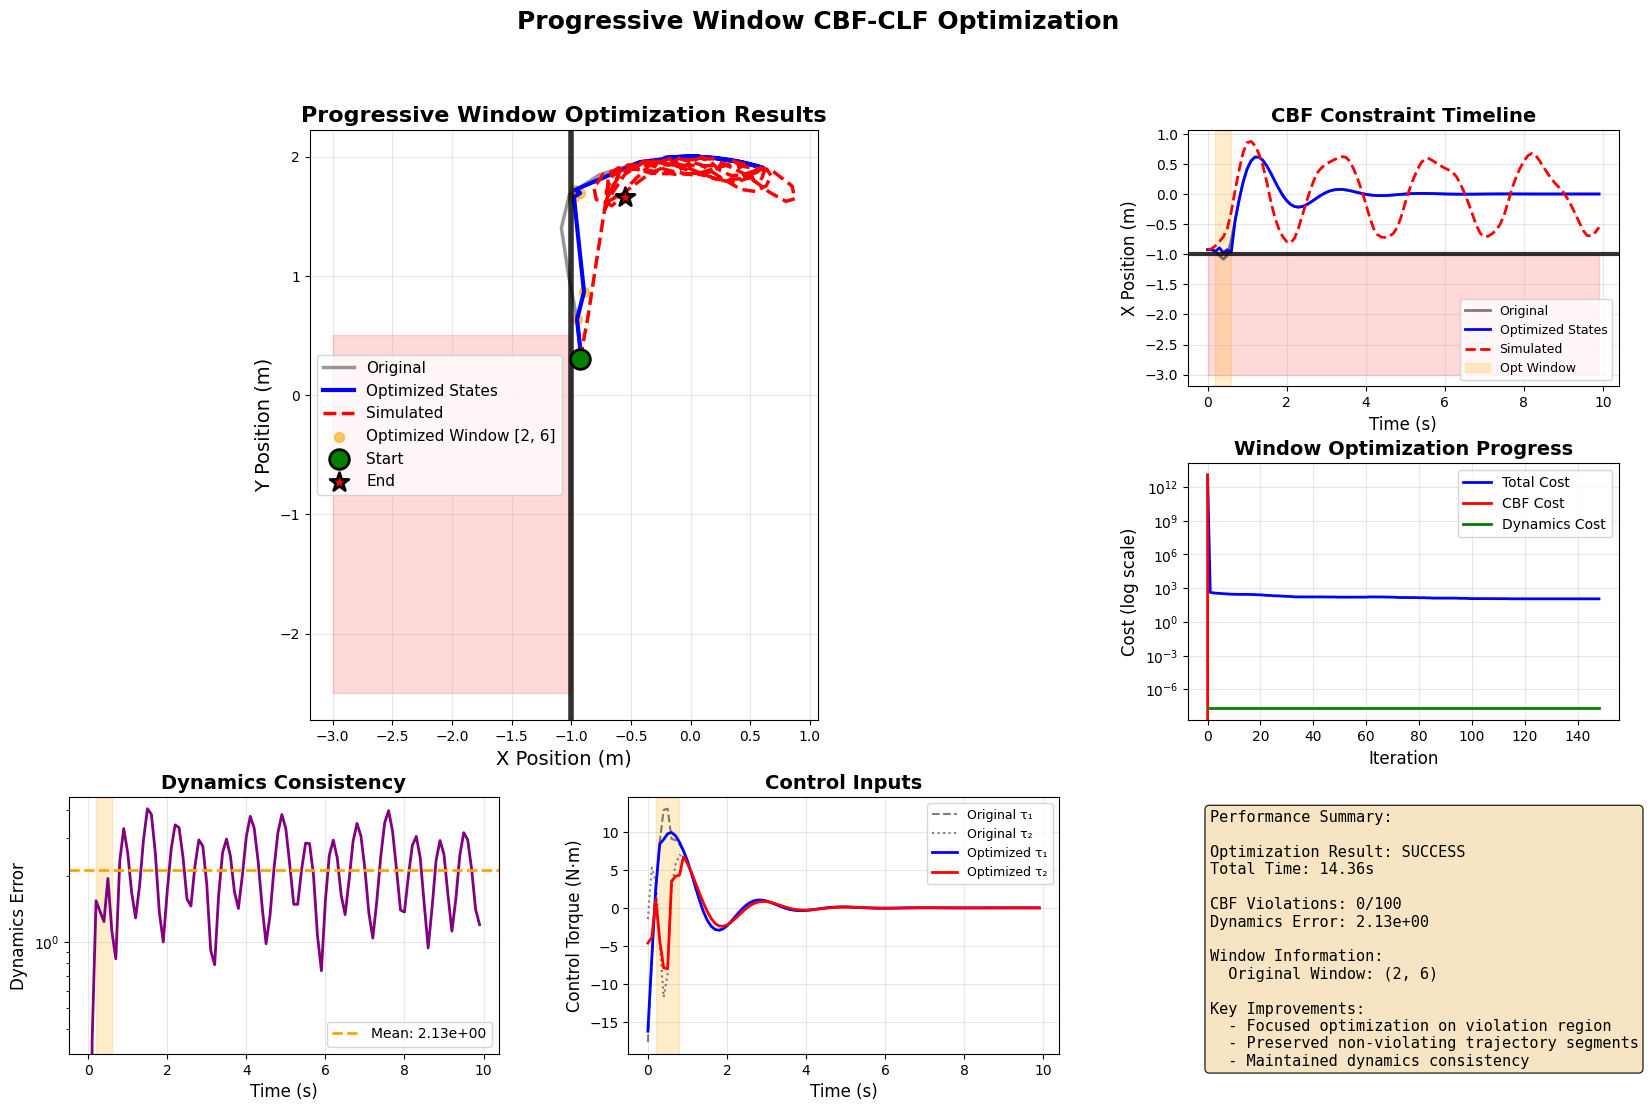


PROGRESSIVE WINDOW OPTIMIZATION REPORT
Result: SUCCESS
CBF Violations: 0 (Original had violations in window)
Dynamics Error: 2.1297e+00
Computation Time: 14.36s
Optimized Window: (2, 6)


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

class ProgressiveWindowOptimizer:
    """
    渐进式窗口优化器
    策略：先识别CBF违反窗口，然后在该窗口内进行局部优化
    如果失败，逐步扩大窗口直到找到解
    """
    def __init__(self, dynamics, dt=0.1, l1=1.0, l2=1.0):
        self.dyn = dynamics
        self.dt = dt
        self.l1 = l1
        self.l2 = l2
        self.cbf_epsilon = 0.01  # CBF软边界
        
    def forward_kinematics(self, state):
        θ1, θ2 = state[0], state[1]
        x1 = self.l1 * np.sin(θ1)
        y1 = -self.l1 * np.cos(θ1)
        x2 = x1 + self.l2 * np.sin(θ2)
        y2 = y1 - self.l2 * np.cos(θ2)
        return np.array([x2, y2])
    
    def simulate(self, initial_state, controls):
        sim_states = [initial_state.copy()]
        for u in controls[:-1]:
            sim_states.append(self.dyn.rk4_step(sim_states[-1], u, self.dt))
        return np.array(sim_states)
    
    def identify_cbf_violation_window(self, states, x_min, margin=0.02):
        """
        识别CBF违反的时间窗口
        返回：(start_idx, end_idx, violation_info)
        """
        violations = []
        
        for t, state in enumerate(states):
            ee_pos = self.forward_kinematics(state)
            if ee_pos[0] < x_min + margin:  # 包含接近边界的点
                violation_depth = max(0, x_min - ee_pos[0])
                violations.append({
                    'time': t,
                    'x_pos': ee_pos[0],
                    'violation_depth': violation_depth
                })
        
        if not violations:
            return None, None, []
        
        # 找到连续违反的窗口
        windows = []
        current_window = [violations[0]['time']]
        
        for i in range(1, len(violations)):
            if violations[i]['time'] - violations[i-1]['time'] <= 2:  # 允许小间隙
                current_window.append(violations[i]['time'])
            else:
                windows.append(current_window)
                current_window = [violations[i]['time']]
        
        if current_window:
            windows.append(current_window)
        
        # 选择最严重的窗口（违反最深或最长）
        max_severity = -1
        best_window = None
        
        for window in windows:
            # 计算窗口严重程度：长度 * 平均违反深度
            window_violations = [v for v in violations if v['time'] in window]
            avg_depth = np.mean([v['violation_depth'] for v in window_violations])
            severity = len(window) * (avg_depth + 1)
            
            if severity > max_severity:
                max_severity = severity
                best_window = window
        
        if best_window:
            start_idx = min(best_window)
            end_idx = max(best_window)
            return start_idx, end_idx, violations
        
        return None, None, []
    
    def compute_window_cost(self,
                            states_window,
                            controls_window,
                            states_orig_window,
                            controls_orig_window,
                            x_min,
                            full_trajectory_context=None):
        """
        计算窗口内的成本，包含：
          1. CBF 软约束
          2. 动力学一致性（在更大区域上计算）
          3. 轨迹相似性（loyalty）
          4. 边界连续性
          5. 控制平滑性
        full_trajectory_context: (full_states, full_controls, window_start, control_start)
        """
        # 解包全轨迹上下文
        full_states, full_controls, window_start, control_start = full_trajectory_context

        # ——— 窗口内仿真，用于 CBF/相似性/边界/平滑 ———
        init_state = full_states[window_start]
        sim_states_window = self.simulate(init_state, controls_window)
        sim_states_window = sim_states_window[:len(states_window)]

        # 1. CBF 软约束
        cbf_cost = 0.0
        for st in np.vstack((states_window, sim_states_window)):
            x_ee = self.forward_kinematics(st)[0]
            if x_ee < x_min + self.cbf_epsilon:
                v = x_min + self.cbf_epsilon - x_ee
                cbf_cost += 1e9 * np.exp(v / self.cbf_epsilon)

        # 2. 动力学一致性：扩 margin 区域仿真
        dyn_margin = 2
        cs, ce = control_start, control_start + len(controls_window)
        rs = max(0, cs - dyn_margin)
        re = min(len(full_states), ce + dyn_margin)
        ctrl_region = full_controls[rs:re]
        sim_region = self.simulate(full_states[rs], ctrl_region)
        sim_region = sim_region[: re - rs]
        orig_region = full_states[rs: rs + len(sim_region)]
        dyn_err = np.sum(np.abs(orig_region - sim_region))
        dynamics_cost = 1e6 * dyn_err
        if dyn_err > 0.1 * len(sim_region):
            dynamics_cost += 1e4 * (dyn_err - 0.1 * len(sim_region))

        # 3. 轨迹相似性（状态窗口 & 控制窗口）
        sim_cost = (np.abs(states_window - states_orig_window).sum() * 10.0 +
                    np.abs(controls_window - controls_orig_window).sum() * 1.0)

        # 4. 边界连续性
        boundary_cost = 0.0
        if window_start > 0:
            boundary_cost = 1e3 * np.linalg.norm(states_window[0] - full_states[window_start])

        # 5. 控制平滑性
        smooth_cost = sum(
            np.abs(controls_window[i+1] - controls_window[i]).sum()
            for i in range(len(controls_window)-1)
        )

        total = cbf_cost + dynamics_cost + sim_cost + boundary_cost + smooth_cost
        comps = {
            'cbf': cbf_cost,
            'dynamics': dynamics_cost,
            'similarity': sim_cost,
            'boundary': boundary_cost,
            'control_smooth': smooth_cost
        }
        return total, comps, sim_states_window
    def generate_window_neighbor(self, states_window, controls_window, temperature, strategy='mixed'):
        """
        生成窗口内的邻域解
        """
        new_states = states_window.copy()
        new_controls = controls_window.copy()
        
        # 自适应噪声
        s_scale = 0.5 * np.sqrt(temperature)
        
        if strategy == 'coordinated' or (strategy == 'mixed' and np.random.rand() < 0.5):
            # 协调扰动：先扰动controls，然后部分传播到states
            control_noise = np.random.normal(0, s_scale * 3.0, controls_window.shape)
            new_controls += control_noise
            new_controls = np.clip(new_controls, -25, 25)
            
            # 使用新controls模拟一部分，混合结果
            sim_partial = self.simulate(new_states[0], new_controls[:min(5, len(new_controls))])
            blend_factor = 0.3 * temperature
            
            for t in range(1, min(len(sim_partial), len(new_states))):
                new_states[t] = (1 - blend_factor) * new_states[t] + blend_factor * sim_partial[t]
                new_states[t, :2] += np.random.normal(0, s_scale * 0.1, 2)
                
        elif strategy == 'smooth' or (strategy == 'mixed' and np.random.rand() < 0.3):
            # 平滑扰动
            # States
            state_noise = np.random.normal(0, s_scale * 0.3, (len(new_states), 4))
            state_noise[:, 2:] *= 2  # 速度噪声更大
            # 平滑滤波
            for i in range(1, len(state_noise)-1):
                state_noise[i] = 0.5 * state_noise[i] + 0.25 * (state_noise[i-1] + state_noise[i+1])
            new_states[1:] += state_noise[1:]  # 不改变初始状态
            
            # Controls
            control_noise = np.random.normal(0, s_scale * 2.0, controls_window.shape)
            for i in range(1, len(control_noise)-1):
                control_noise[i] = 0.5 * control_noise[i] + 0.25 * (control_noise[i-1] + control_noise[i+1])
            new_controls += control_noise
            new_controls = np.clip(new_controls, -25, 25)
            
        else:  # local
            # 局部扰动
            n_perturb_states = max(1, int(len(new_states) * 0.3))
            n_perturb_controls = max(1, int(len(new_controls) * 0.3))
            
            # 扰动states（不包括第一个）
            if len(new_states) > 1:
                perturb_indices = np.random.choice(range(1, len(new_states)), 
                                                 size=min(n_perturb_states, len(new_states)-1), 
                                                 replace=False)
                for idx in perturb_indices:
                    new_states[idx, :2] += np.random.normal(0, s_scale * 0.5, 2)
                    new_states[idx, 2:] += np.random.normal(0, s_scale * 1.0, 2)
            
            # 扰动controls
            perturb_indices = np.random.choice(range(len(new_controls)), 
                                             size=min(n_perturb_controls, len(new_controls)), 
                                             replace=False)
            for idx in perturb_indices:
                new_controls[idx] += np.random.normal(0, s_scale * 3.0, 2)
                new_controls[idx] = np.clip(new_controls[idx], -25, 25)
        
        return new_states, new_controls
    
    def optimize_window(self, states_full, controls_full, window_start, window_end,
                        x_min, T_init=5.0, T_min=0.01, cooling_rate=0.985,
                        max_iter=1500, n_neighbors=40, verbose=True):
        """
        优化指定窗口
        """
        # 扩展控制窗口
        control_start = max(0, window_start - 2)
        control_end = min(len(controls_full), window_end + 3)
        
        # 提取窗口
        states_window = states_full[window_start:window_end+1].copy()
        controls_window = controls_full[control_start:control_end].copy()
        
        # 原始窗口数据
        states_orig_window = states_window.copy()
        controls_orig_window = controls_window.copy()
        
        if verbose:
            print(f"\nOptimizing window [{window_start}, {window_end}]")
            print(f"  States window size: {len(states_window)}")
            print(f"  Controls window: [{control_start}, {control_end-1}], size: {len(controls_window)}")
        
        # 初始化
        curr_states = states_window.copy()
        curr_controls = controls_window.copy()
        
        full_context = (states_full, controls_full, window_start, control_start)

        curr_cost, curr_comp, curr_sim = self.compute_window_cost(
            curr_states, curr_controls, states_orig_window, controls_orig_window,
            x_min, full_context
        )
        
        best_states = curr_states.copy()
        best_controls = curr_controls.copy()
        best_cost = curr_cost
        best_sim = curr_sim.copy()
        
        # 优化历史
        history = {
            'costs': [curr_cost],
            'cbf_costs': [curr_comp['cbf']],
            'dynamics_costs': [curr_comp['dynamics']],
            'best_costs': [curr_cost]
        }
        
        T = T_init
        it = 0
        no_improve_count = 0
        success = False
        
        while T > T_min and it < max_iter:
            # 生成候选解
            candidates = []
            costs = []
            
            for _ in range(n_neighbors):
                # 使用混合策略
                cand_states, cand_controls = self.generate_window_neighbor(
                    curr_states, curr_controls, T, strategy='mixed'
                )
                
                cand_cost, cand_comp, cand_sim = self.compute_window_cost(
                    cand_states, cand_controls, states_orig_window, controls_orig_window,
                    x_min, full_context
                )
                
                candidates.append((cand_states, cand_controls, cand_sim, cand_comp))
                costs.append(cand_cost)
            
            # 选择最佳候选
            best_idx = np.argmin(costs)
            cand_states, cand_controls, cand_sim, cand_comp = candidates[best_idx]
            cand_cost = costs[best_idx]
            
            # 接受判断
            if cand_cost < curr_cost:
                accept = True
            else:
                accept = np.random.rand() < np.exp(-(cand_cost - curr_cost) / T)
            
            if accept:
                curr_states = cand_states
                curr_controls = cand_controls
                curr_cost = cand_cost
                curr_sim = cand_sim
                curr_comp = cand_comp
                
                if curr_cost < best_cost:
                    best_states = curr_states.copy()
                    best_controls = curr_controls.copy()
                    best_cost = curr_cost
                    best_sim = curr_sim.copy()
                    no_improve_count = 0
                    
                    # 检查是否满足约束
                    if curr_comp['cbf'] < 1.0 and curr_comp['dynamics'] < 0.01:
                        success = True
                        if verbose:
                            print(f"  Success at iteration {it}!")
                else:
                    no_improve_count += 1
            else:
                no_improve_count += 1
            
            # 记录历史
            history['costs'].append(curr_cost)
            history['cbf_costs'].append(curr_comp['cbf'])
            history['dynamics_costs'].append(curr_comp['dynamics'])
            history['best_costs'].append(best_cost)
            
            # 温度更新
            if no_improve_count > 30:
                T *= cooling_rate * 0.95
            else:
                T *= cooling_rate
            
            it += 1
            
            if verbose and it % 200 == 0:
                print(f"  Iter {it}: T={T:.4f}, Best={best_cost:.2e}")
                print(f"    CBF={curr_comp['cbf']:.2e}, Dyn={curr_comp['dynamics']:.2e}")
            
            # 提前终止条件
            if success and no_improve_count > 20:
                break
        
        # 返回结果
        result = {
            'success': success,
            'states': best_states,
            'controls': best_controls,
            'simulated': best_sim,
            'cost': best_cost,
            'components': curr_comp,
            'iterations': it,
            'history': history,
            'window': (window_start, window_end),
            'control_window': (control_start, control_end)
        }
        
        return result
    
    def progressive_optimize(self, states_original, controls_original, x_min,
                           window_expansion_factor=1.5, max_window_size=30,
                           max_attempts=5, verbose=True):
        """
        渐进式窗口优化主函数
        """
        print("=== Progressive Window CBF-CLF Optimization ===")
        print(f"Obstacle position: x_min = {x_min}")
        
        start_time = time.time()
        
        # 复制原始轨迹
        states = states_original.copy()
        controls = controls_original.copy()
        
        # 识别初始违反窗口
        window_start, window_end, violations = self.identify_cbf_violation_window(states, x_min)
        
        if window_start is None:
            print("No CBF violations found in the original trajectory!")
            return {
                'success': True,
                'states': states,
                'controls': controls,
                'iterations': 0,
                'time': 0,
                'message': 'No violations to fix'
            }
        
        print(f"\nIdentified violation window: [{window_start}, {window_end}]")
        print(f"Number of violating points: {len([v for v in violations if v['time'] >= window_start and v['time'] <= window_end])}")
        max_violation = max([v['violation_depth'] for v in violations])
        print(f"Maximum violation depth: {max_violation:.4f}m")
        
        # 渐进式优化
        attempt = 0
        success = False
        best_result = None
        
        while attempt < max_attempts and not success:
            print(f"\n--- Attempt {attempt + 1} ---")
            
            # 优化当前窗口
            result = self.optimize_window(
                states, controls, window_start, window_end, x_min,
                T_init=5.0, T_min=0.01, cooling_rate=0.985,
                max_iter=1500, n_neighbors=40, verbose=verbose
            )
            
            if result['success']:
                success = True
                best_result = result
                print(f"✓ Success! Found feasible solution in window [{window_start}, {window_end}]")
            else:
                print(f"✗ Failed to find feasible solution in current window")
                
                # 扩展窗口


                # 每次都向前后扩 1
                window_start = max(0, window_start - 1)
                window_end   = min(len(states) - 1, window_end   + 1)

                
                print(f"  Expanding window to [{window_start}, {window_end}]")
                
                # 保存最好的结果
                if best_result is None or result['cost'] < best_result['cost']:
                    best_result = result
            
            attempt += 1
        
        # 应用最佳结果
        if best_result is not None:
            # 更新states
            states[best_result['window'][0]:best_result['window'][1]+1] = best_result['states']
            
            # 更新controls
            ctrl_start, ctrl_end = best_result['control_window']
            controls[ctrl_start:ctrl_end] = best_result['controls']
        
        # 最终模拟
        final_sim = self.simulate(states[0], controls)
        
        # 检查最终结果
        final_violations = []
        for t, state in enumerate(final_sim):
            ee_pos = self.forward_kinematics(state)
            if ee_pos[0] < x_min:
                final_violations.append(t)
        
        total_time = time.time() - start_time
        
        # 计算动力学误差
        dynamics_error = np.mean(np.linalg.norm(final_sim - states, axis=1))
        
        print(f"\n=== Optimization Complete ===")
        print(f"Total time: {total_time:.2f}s")
        print(f"Final CBF violations: {len(final_violations)}/{len(states)}")
        print(f"Dynamics error: {dynamics_error:.4e}")
        print(f"Success: {'Yes' if len(final_violations) == 0 else 'No'}")
        
        return {
            'success': len(final_violations) == 0,
            'states': states,
            'controls': controls,
            'simulated_states': final_sim,
            'cbf_violations': len(final_violations),
            'dynamics_error': dynamics_error,
            'time': total_time,
            'window_history': best_result['window'] if best_result else None,
            'optimization_history': best_result['history'] if best_result else None,
            'original': (states_original, controls_original),
            'x_min': x_min
        }


def run_progressive_optimization(trajectory_index=0, x_min=-0.3):
    """
    运行渐进式窗口优化
    """
    print(f"Loading trajectory {trajectory_index}...")
    
    # 获取原始轨迹
    try:
        fm_trajectory = generated_trajectories[trajectory_index]
        states_original = fm_trajectory['states']
        controls_original = fm_trajectory['controls']
    except (NameError, IndexError) as e:
        print(f"Error: {e}")
        print("Creating synthetic trajectory for demonstration...")
        
        # 创建合成轨迹
        T = 100
        dt = 0.1
        states_original = np.zeros((T, 4))
        controls_original = np.zeros((T, 2))
        
        # 创建一个会违反CBF的轨迹
        for t in range(T):
            alpha = t / (T - 1)
            # 让轨迹在中段违反CBF
            if 0.3 < alpha < 0.7:
                theta1 = alpha * np.pi - 0.5
            else:
                theta1 = alpha * np.pi
            
            states_original[t] = [
                theta1,
                alpha * np.pi,
                0, 0
            ]
            if t < T - 1:
                controls_original[t] = [1.0, 1.0]
    
    # 初始化动力学模型
    try:
        dyn = DoublePendulumDynamics()
    except NameError:
        print("Error: DoublePendulumDynamics not defined!")
        return None
    
    # 运行渐进式优化
    optimizer = ProgressiveWindowOptimizer(dyn, dt=0.1)
    results = optimizer.progressive_optimize(
        states_original, controls_original, x_min=x_min,
        window_expansion_factor=1.5, max_window_size=30,
        max_attempts=5, verbose=True
    )
    
    return results


def visualize_progressive_results(results):
    """
    可视化渐进式优化结果
    """
    if results is None:
        print("No results to visualize!")
        return
    
    # 提取数据
    states_orig, controls_orig = results['original']
    states_opt = results['states']
    controls_opt = results['controls']
    sim_states = results['simulated_states']
    x_min = results['x_min']
    
    # 计算末端执行器轨迹
    def compute_ee_trajectory(states, l1=1.0, l2=1.0):
        ee_positions = []
        for state in states:
            θ1, θ2 = state[0], state[1]
            x1 = l1 * np.sin(θ1)
            y1 = -l1 * np.cos(θ1)
            x2 = x1 + l2 * np.sin(θ2)
            y2 = y1 - l2 * np.cos(θ2)
            ee_positions.append([x2, y2])
        return np.array(ee_positions)
    
    ee_orig = compute_ee_trajectory(states_orig)
    ee_opt = compute_ee_trajectory(states_opt)
    ee_sim = compute_ee_trajectory(sim_states)
    
    time_steps = np.arange(len(states_orig)) * 0.1
    
    # 创建可视化
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1. 主轨迹对比
    ax1 = fig.add_subplot(gs[0:2, 0:2])
    
    # 原始轨迹
    ax1.plot(ee_orig[:, 0], ee_orig[:, 1], 'k-', linewidth=2.5, alpha=0.4, label='Original')
    
    # 优化后的states轨迹
    ax1.plot(ee_opt[:, 0], ee_opt[:, 1], 'b-', linewidth=3, label='Optimized States')
    
    # 模拟轨迹
    ax1.plot(ee_sim[:, 0], ee_sim[:, 1], 'r--', linewidth=2.5, label='Simulated')
    
    # 障碍物
    ax1.axvline(x=x_min, color='black', linestyle='-', linewidth=4, alpha=0.8)
    ax1.fill_betweenx([-2.5, 0.5], -3, x_min, alpha=0.15, color='red')
    
    # 标记优化窗口（如果有）
    if results['window_history']:
        window_start, window_end = results['window_history']
        ax1.scatter(ee_opt[window_start:window_end+1, 0], ee_opt[window_start:window_end+1, 1],
                   c='orange', s=50, alpha=0.6, label=f'Optimized Window [{window_start}, {window_end}]')
    
    # 起点和终点
    ax1.scatter(ee_orig[0, 0], ee_orig[0, 1], c='green', s=200, marker='o', 
                edgecolors='black', linewidth=2, label='Start', zorder=5)
    ax1.scatter(ee_sim[-1, 0], ee_sim[-1, 1], c='red', s=200, marker='*', 
                edgecolors='black', linewidth=2, label='End', zorder=5)
    
    ax1.set_xlabel('X Position (m)', fontsize=14)
    ax1.set_ylabel('Y Position (m)', fontsize=14)
    ax1.set_title('Progressive Window Optimization Results', fontsize=16, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    
    # 2. CBF检查
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.plot(time_steps, ee_orig[:, 0], 'k-', linewidth=2, alpha=0.5, label='Original')
    ax2.plot(time_steps, ee_opt[:, 0], 'b-', linewidth=2, label='Optimized States')
    ax2.plot(time_steps, ee_sim[:, 0], 'r--', linewidth=2, label='Simulated')
    ax2.axhline(y=x_min, color='black', linestyle='-', linewidth=3, alpha=0.8)
    ax2.fill_between(time_steps, -3, x_min, alpha=0.15, color='red')
    
    # 标记优化窗口
    if results['window_history']:
        window_start, window_end = results['window_history']
        ax2.axvspan(time_steps[window_start], time_steps[window_end], 
                   alpha=0.2, color='orange', label='Opt Window')
    
    ax2.set_xlabel('Time (s)', fontsize=12)
    ax2.set_ylabel('X Position (m)', fontsize=12)
    ax2.set_title('CBF Constraint Timeline', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    # 3. 优化历史（如果有）
    if results['optimization_history']:
        ax3 = fig.add_subplot(gs[1, 2])
        history = results['optimization_history']
        iterations = np.arange(len(history['costs']))
        
        ax3.semilogy(iterations, history['costs'], 'b-', linewidth=2, label='Total Cost')
        ax3.semilogy(iterations, history['cbf_costs'], 'r-', linewidth=2, label='CBF Cost')
        ax3.semilogy(iterations, history['dynamics_costs'], 'g-', linewidth=2, label='Dynamics Cost')
        
        ax3.set_xlabel('Iteration', fontsize=12)
        ax3.set_ylabel('Cost (log scale)', fontsize=12)
        ax3.set_title('Window Optimization Progress', fontsize=14, fontweight='bold')
        ax3.legend(fontsize=10)
        ax3.grid(True, alpha=0.3)
    
    # 4. 动力学误差
    ax4 = fig.add_subplot(gs[2, 0])
    dynamics_error = np.linalg.norm(sim_states - states_opt, axis=1)
    ax4.plot(time_steps, dynamics_error, 'purple', linewidth=2)
    
    # 标记优化窗口
    if results['window_history']:
        window_start, window_end = results['window_history']
        ax4.axvspan(time_steps[window_start], time_steps[window_end], 
                   alpha=0.2, color='orange')
    
    mean_error = np.mean(dynamics_error)
    ax4.axhline(y=mean_error, color='orange', linestyle='--', 
                linewidth=2, label=f'Mean: {mean_error:.2e}')
    
    ax4.set_xlabel('Time (s)', fontsize=12)
    ax4.set_ylabel('Dynamics Error', fontsize=12)
    ax4.set_title('Dynamics Consistency', fontsize=14, fontweight='bold')
    ax4.set_yscale('log')
    ax4.legend(fontsize=10)
    ax4.grid(True, alpha=0.3)
    
    # 5. 控制对比
    ax5 = fig.add_subplot(gs[2, 1])
    ax5.plot(time_steps, controls_orig[:, 0], 'k--', linewidth=1.5, alpha=0.5, label='Original τ₁')
    ax5.plot(time_steps, controls_orig[:, 1], 'k:', linewidth=1.5, alpha=0.5, label='Original τ₂')
    ax5.plot(time_steps, controls_opt[:, 0], 'b-', linewidth=2, label='Optimized τ₁')
    ax5.plot(time_steps, controls_opt[:, 1], 'r-', linewidth=2, label='Optimized τ₂')
    
    # 标记控制窗口
    if results['window_history']:
        ax5.axvspan(time_steps[window_start], time_steps[min(window_end+2, len(time_steps)-1)], 
                   alpha=0.2, color='orange')
    
    ax5.set_xlabel('Time (s)', fontsize=12)
    ax5.set_ylabel('Control Torque (N·m)', fontsize=12)
    ax5.set_title('Control Inputs', fontsize=14, fontweight='bold')
    ax5.legend(fontsize=9)
    ax5.grid(True, alpha=0.3)
    
    # 6. 性能总结
    ax6 = fig.add_subplot(gs[2, 2])
    ax6.axis('off')
    
    summary_text = f"""Performance Summary:
    
Optimization Result: {'SUCCESS' if results['success'] else 'FAILED'}
Total Time: {results['time']:.2f}s

CBF Violations: {results['cbf_violations']}/{len(states_opt)}
Dynamics Error: {results['dynamics_error']:.2e}

Window Information:
  Original Window: {results['window_history'] if results['window_history'] else 'N/A'}
  
Key Improvements:
  - Focused optimization on violation region
  - Preserved non-violating trajectory segments
  - Maintained dynamics consistency"""
    
    ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes, 
             fontsize=11, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.suptitle('Progressive Window CBF-CLF Optimization', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 打印详细报告
    print("\n" + "="*80)
    print("PROGRESSIVE WINDOW OPTIMIZATION REPORT")
    print("="*80)
    print(f"Result: {'SUCCESS' if results['success'] else 'FAILED'}")
    print(f"CBF Violations: {results['cbf_violations']} (Original had violations in window)")
    print(f"Dynamics Error: {results['dynamics_error']:.4e}")
    print(f"Computation Time: {results['time']:.2f}s")
    if results['window_history']:
        print(f"Optimized Window: {results['window_history']}")
    print("="*80)


# 使用示例
if __name__ == "__main__":
    print("Testing Progressive Window CBF-CLF Optimization...")
    
    # 运行优化
    results = run_progressive_optimization(
        trajectory_index=0,
        x_min=-1.0  # 障碍物位置
    )
    
    # 可视化结果
    if results is not None:
        visualize_progressive_results(results)

Testing One-Shot SA Control-Only Optimization...
Loading trajectory 10...
✓ Loaded trajectory with 100 timesteps
=== One-Shot SA Control-Only Optimization ===
Obstacle position: x_min = -0.5

Identified violation window: [9, 15]
Maximum violation depth: 0.4645m

Optimizing control window [6, 17]
  Window size: 12 controls
  For state window [9, 15]
  Iter 200: T=0.0536, Best=1.32e+09, CBF_viol=0, Accept_rate=100.00%
  Iter 250: T=0.0252, Best=4.96e+03, CBF_viol=0, Accept_rate=95.20%
  Iter 300: T=0.0118, Best=4.94e+03, CBF_viol=0, Accept_rate=99.33%
✓ Success! Found feasible solution

=== Optimization Complete ===
Total time: 1.16s
Final CBF violations: 0/100
Success: Yes


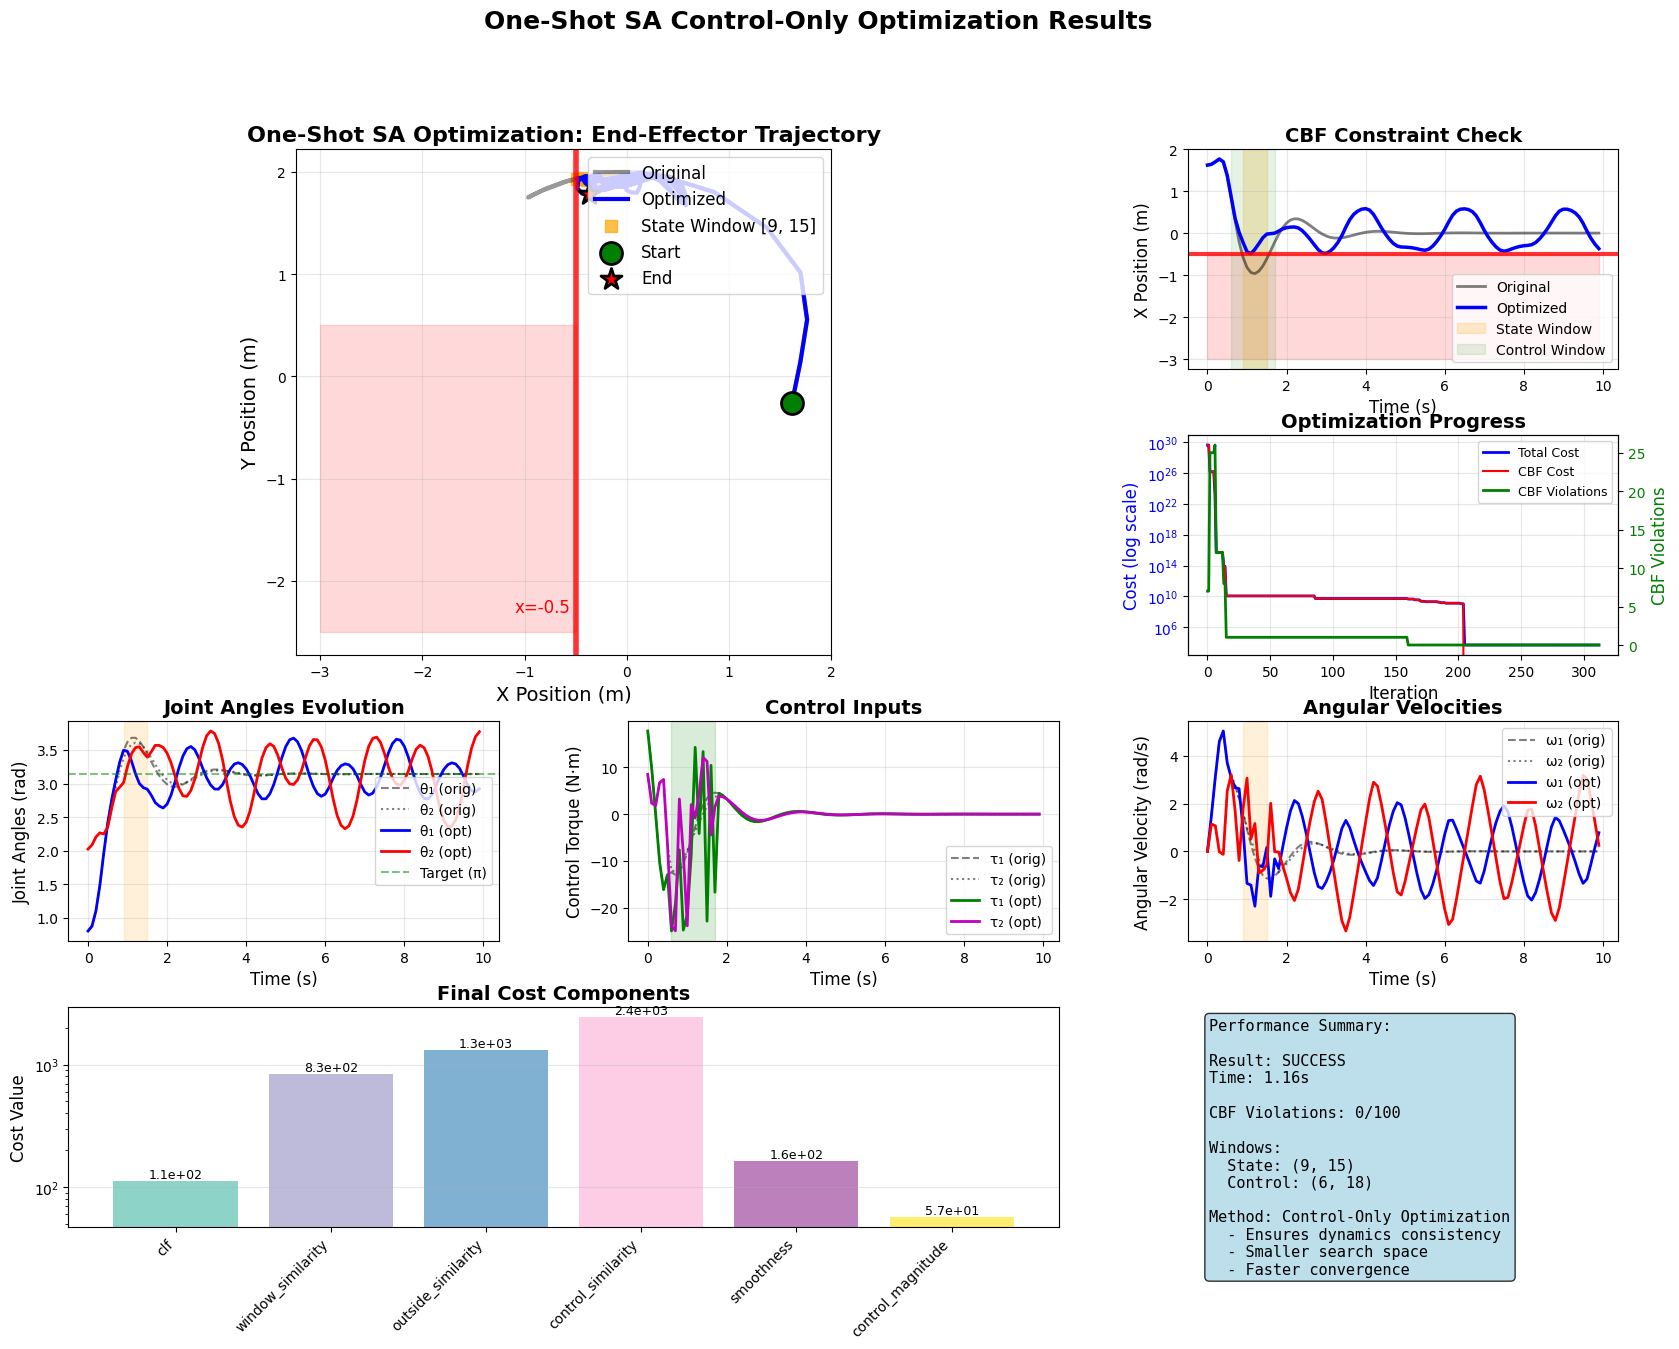


ONE-SHOT SA OPTIMIZATION REPORT
Result: SUCCESS
CBF Violations: 0
Computation Time: 1.16s
Optimized Window: (9, 15)
Control Window: (6, 18)


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

class OneShotSAOptimizer:
    """
    One-Shot Simulated Annealing优化器
    只优化控制量，确保全局动力学一致性
    """
    def __init__(self, dynamics, dt=0.1, l1=1.0, l2=1.0):
        self.dyn = dynamics
        self.dt = dt
        self.l1 = l1
        self.l2 = l2
        self.cbf_epsilon = 0.01  # CBF软边界
        
    def forward_kinematics(self, state):
        """计算末端执行器位置"""
        θ1, θ2 = state[0], state[1]
        x1 = self.l1 * np.sin(θ1)
        y1 = -self.l1 * np.cos(θ1)
        x2 = x1 + self.l2 * np.sin(θ2)
        y2 = y1 - self.l2 * np.cos(θ2)
        return np.array([x2, y2])
    
    def simulate(self, initial_state, controls):
        """从初始状态开始仿真整条轨迹"""
        sim_states = [initial_state.copy()]
        for u in controls[:-1]:
            sim_states.append(self.dyn.rk4_step(sim_states[-1], u, self.dt))
        return np.array(sim_states)
    
    def identify_cbf_violation_window(self, states, x_min, margin=0.02):
        """识别CBF违反的时间窗口"""
        violations = []
        
        for t, state in enumerate(states):
            ee_pos = self.forward_kinematics(state)
            if ee_pos[0] < x_min + margin:
                violation_depth = max(0, x_min - ee_pos[0])
                violations.append({
                    'time': t,
                    'x_pos': ee_pos[0],
                    'violation_depth': violation_depth
                })
        
        if not violations:
            return None, None, []
        
        # 找到连续违反的窗口
        windows = []
        current_window = [violations[0]['time']]
        
        for i in range(1, len(violations)):
            if violations[i]['time'] - violations[i-1]['time'] <= 2:
                current_window.append(violations[i]['time'])
            else:
                windows.append(current_window)
                current_window = [violations[i]['time']]
        
        if current_window:
            windows.append(current_window)
        
        # 选择最严重的窗口
        max_severity = -1
        best_window = None
        
        for window in windows:
            window_violations = [v for v in violations if v['time'] in window]
            avg_depth = np.mean([v['violation_depth'] for v in window_violations])
            severity = len(window) * (avg_depth + 1)
            
            if severity > max_severity:
                max_severity = severity
                best_window = window
        
        if best_window:
            start_idx = min(best_window)
            end_idx = max(best_window)
            return start_idx, end_idx, violations
        
        return None, None, []
    
    def compute_control_only_cost(self, controls_window, context):
        """
        只基于控制量计算成本，包含：
          1. CBF软约束（全轨迹）
          2. CLF目标跟踪
          3. 控制相似性
          4. 控制平滑性
        """
        # 解包上下文
        full_controls_orig = context['controls_orig']
        control_start = context['control_start']
        control_end = context['control_end']
        x_min = context['x_min']
        initial_state = context['initial_state']
        states_orig = context['states_orig']
        
        # 构建完整控制序列
        full_controls = full_controls_orig.copy()
        full_controls[control_start:control_end] = controls_window
        
        # 从初始状态仿真整条轨迹
        sim_states = self.simulate(initial_state, full_controls)
        
        # 1. CBF软约束 - 检查整条轨迹
        cbf_cost = 0.0
        cbf_violations = 0
        for st in sim_states:
            x_ee = self.forward_kinematics(st)[0]
            if x_ee < x_min:
                cbf_violations += 1
            if x_ee < x_min + self.cbf_epsilon:
                violation = x_min + self.cbf_epsilon - x_ee
                cbf_cost += 1e9 * np.exp(violation / self.cbf_epsilon)
        
        # 2. CLF目标跟踪 - 终点误差
        target_state = np.array([np.pi, np.pi, 0, 0])
        final_error = np.linalg.norm(sim_states[-1] - target_state)
        clf_cost = 100 * final_error ** 2
        
        # 3. 轨迹相似性 - 重点关注优化窗口附近
        window_start = context['window_start']
        window_end = context['window_end']
        
        # 窗口内的状态相似性（高权重）
        window_sim_cost = 0.0
        if window_start <= len(sim_states) and window_end <= len(sim_states):
            window_states_diff = sim_states[window_start:window_end+1] - states_orig[window_start:window_end+1]
            window_sim_cost = 50 * np.sum(np.abs(window_states_diff))
        
        # 窗口外的状态相似性（低权重，主要防止过度偏离）
        outside_sim_cost = 0.0
        if window_start > 0:
            pre_diff = sim_states[:window_start] - states_orig[:window_start]
            outside_sim_cost += 5 * np.sum(np.abs(pre_diff))
        if window_end < len(sim_states) - 1:
            post_diff = sim_states[window_end+1:] - states_orig[window_end+1:]
            outside_sim_cost += 5 * np.sum(np.abs(post_diff))
        
        # 控制相似性
        control_sim_cost = 10 * np.sum(np.abs(controls_window - full_controls_orig[control_start:control_end]))
        
        # 4. 控制平滑性
        smooth_cost = 0.0
        for i in range(len(controls_window)-1):
            smooth_cost += 0.5 * np.sum(np.abs(controls_window[i+1] - controls_window[i]))
        
        # 控制幅度惩罚
        control_magnitude_cost = 0.01 * np.sum(controls_window ** 2)
        
        # 总成本
        total_cost = cbf_cost + clf_cost + window_sim_cost + outside_sim_cost + control_sim_cost + smooth_cost + control_magnitude_cost
        
        components = {
            'cbf': cbf_cost,
            'clf': clf_cost,
            'window_similarity': window_sim_cost,
            'outside_similarity': outside_sim_cost,
            'control_similarity': control_sim_cost,
            'smoothness': smooth_cost,
            'control_magnitude': control_magnitude_cost,
            'cbf_violations': cbf_violations
        }
        
        return total_cost, components, sim_states
    
    def generate_control_neighbor(self, controls, temperature, strategy='adaptive'):
        """生成控制量的邻域解"""
        new_controls = controls.copy()
        
        # 自适应扰动强度
        base_scale = 0.5 * np.sqrt(temperature)
        
        if strategy == 'adaptive':
            # 根据温度自适应选择策略
            if temperature > 1.0:  # 高温：全局探索
                # 大范围随机扰动
                noise = np.random.normal(0, base_scale * 5.0, controls.shape)
                new_controls += noise
                
            elif temperature > 0.1:  # 中温：平滑扰动
                # 生成平滑噪声
                noise = np.random.normal(0, base_scale * 2.0, controls.shape)
                # 平滑滤波
                for i in range(1, len(noise)-1):
                    noise[i] = 0.4 * noise[i] + 0.3 * (noise[i-1] + noise[i+1])
                new_controls += noise
                
            else:  # 低温：局部微调
                # 只扰动部分控制点
                n_perturb = max(1, int(len(controls) * 0.3))
                indices = np.random.choice(len(controls), n_perturb, replace=False)
                for idx in indices:
                    new_controls[idx] += np.random.normal(0, base_scale * 1.0, 2)
        
        elif strategy == 'smooth':
            # 始终使用平滑扰动
            noise = np.random.normal(0, base_scale * 2.0, controls.shape)
            kernel = np.array([0.25, 0.5, 0.25])
            for dim in range(controls.shape[1]):
                noise[:, dim] = np.convolve(noise[:, dim], kernel, mode='same')
            new_controls += noise
            
        elif strategy == 'local':
            # 局部扰动
            n_perturb = max(1, int(len(controls) * temperature))
            indices = np.random.choice(len(controls), n_perturb, replace=False)
            for idx in indices:
                new_controls[idx] += np.random.normal(0, base_scale * 3.0, 2)
        
        # 限制控制量范围
        new_controls = np.clip(new_controls, -25, 25)
        
        return new_controls
    
    def optimize_window(self, states_orig, controls_orig, window_start, window_end,
                       x_min, T_init=10.0, T_min=0.01, cooling_rate=0.985,
                       max_iter=2000, verbose=True):
        """优化指定窗口的控制量"""
        # 扩展控制窗口
        control_margin = 3
        control_start = max(0, window_start - control_margin)
        control_end = min(len(controls_orig), window_end + control_margin)
        
        # 提取控制窗口
        controls_window = controls_orig[control_start:control_end].copy()
        
        if verbose:
            print(f"\nOptimizing control window [{control_start}, {control_end-1}]")
            print(f"  Window size: {len(controls_window)} controls")
            print(f"  For state window [{window_start}, {window_end}]")
        
        # 准备优化上下文
        context = {
            'controls_orig': controls_orig,
            'states_orig': states_orig,
            'control_start': control_start,
            'control_end': control_end,
            'window_start': window_start,
            'window_end': window_end,
            'x_min': x_min,
            'initial_state': states_orig[0]
        }
        
        # 初始化
        curr_controls = controls_window.copy()
        curr_cost, curr_comp, curr_sim = self.compute_control_only_cost(curr_controls, context)
        
        best_controls = curr_controls.copy()
        best_cost = curr_cost
        best_sim = curr_sim.copy()
        best_comp = curr_comp.copy()
        
        # 优化历史
        history = {
            'costs': [curr_cost],
            'cbf_costs': [curr_comp['cbf']],
            'cbf_violations': [curr_comp['cbf_violations']],
            'temperatures': [T_init]
        }
        
        # 模拟退火主循环
        T = T_init
        it = 0
        no_improve = 0
        success = False
        
        while T > T_min and it < max_iter:
            # 生成候选解
            candidate_controls = self.generate_control_neighbor(curr_controls, T, strategy='adaptive')
            
            # 计算候选解成本
            cand_cost, cand_comp, cand_sim = self.compute_control_only_cost(candidate_controls, context)
            
            # 接受概率
            delta = cand_cost - curr_cost
            if delta < 0:
                accept = True
            else:
                accept_prob = np.exp(-delta / T)
                accept = np.random.rand() < accept_prob
            
            if accept:
                curr_controls = candidate_controls
                curr_cost = cand_cost
                curr_comp = cand_comp
                curr_sim = cand_sim
                
                # 更新最佳解
                if curr_cost < best_cost:
                    best_controls = curr_controls.copy()
                    best_cost = curr_cost
                    best_sim = curr_sim.copy()
                    best_comp = curr_comp.copy()
                    no_improve = 0
                    
                    # 检查成功条件
                    if curr_comp['cbf_violations'] == 0:
                        success = True
                else:
                    no_improve += 1
            else:
                no_improve += 1
            
            # 记录历史
            history['costs'].append(curr_cost)
            history['cbf_costs'].append(curr_comp['cbf'])
            history['cbf_violations'].append(curr_comp['cbf_violations'])
            history['temperatures'].append(T)
            
            # 温度更新策略
            if no_improve > 50:
                # 长时间无改进，加速冷却
                T *= cooling_rate * 0.95
            else:
                T *= cooling_rate
            
            # 偶尔重热
            if no_improve > 100 and T > 0.1:
                T = min(T * 2, T_init * 0.1)
                no_improve = 0
                if verbose:
                    print(f"  Reheating at iteration {it}, T={T:.4f}")
            
            it += 1
            
            # 进度报告
            if verbose and (it % 200 == 0 or (success and it % 50 == 0)):
                print(f"  Iter {it}: T={T:.4f}, Best={best_cost:.2e}, "
                      f"CBF_viol={best_comp['cbf_violations']}, "
                      f"Accept_rate={(it-no_improve)/it:.2%}")
            
            # 早停条件
            if success and no_improve > 50:
                if verbose:
                    print(f"  Early stopping: Found feasible solution at iteration {it}")
                break
        
        # 返回结果
        result = {
            'success': success,
            'controls': best_controls,
            'simulated_states': best_sim,
            'cost': best_cost,
            'components': best_comp,
            'iterations': it,
            'history': history,
            'window': (window_start, window_end),
            'control_window': (control_start, control_end)
        }
        
        return result
    
    def one_shot_optimize(self, states_original, controls_original, x_min,
                         max_window_expansions=3, verbose=True):
        """One-Shot SA优化主函数"""
        print("=== One-Shot SA Control-Only Optimization ===")
        print(f"Obstacle position: x_min = {x_min}")
        
        start_time = time.time()
        
        # 识别初始违反窗口
        window_start, window_end, violations = self.identify_cbf_violation_window(
            states_original, x_min
        )
        
        if window_start is None:
            print("No CBF violations found!")
            return {
                'success': True,
                'states': states_original,
                'controls': controls_original,
                'simulated_states': states_original,
                'time': 0,
                'message': 'No violations to fix'
            }
        
        print(f"\nIdentified violation window: [{window_start}, {window_end}]")
        max_violation = max([v['violation_depth'] for v in violations])
        print(f"Maximum violation depth: {max_violation:.4f}m")
        
        # 逐步扩大窗口直到找到解
        success = False
        best_result = None
        
        for expansion in range(max_window_expansions + 1):
            if expansion > 0:
                # 扩大窗口
                window_start = max(0, window_start - 1)
                window_end = min(len(states_original) - 1, window_end + 1)
                print(f"\nExpanding window to [{window_start}, {window_end}]")
            
            # 优化当前窗口
            result = self.optimize_window(
                states_original, controls_original,
                window_start, window_end, x_min,
                T_init=10.0, T_min=0.01, cooling_rate=0.985,
                max_iter=2000, verbose=verbose
            )
            
            if result['success']:
                success = True
                best_result = result
                print(f"✓ Success! Found feasible solution")
                break
            else:
                print(f"✗ Failed to find feasible solution")
                if best_result is None or result['cost'] < best_result['cost']:
                    best_result = result
        
        # 应用最佳结果
        if best_result is not None:
            # 构建最终控制序列
            final_controls = controls_original.copy()
            ctrl_start, ctrl_end = best_result['control_window']
            final_controls[ctrl_start:ctrl_end] = best_result['controls']
            
            # 最终仿真
            final_states = self.simulate(states_original[0], final_controls)
            
            # 检查最终结果
            final_violations = 0
            for state in final_states:
                if self.forward_kinematics(state)[0] < x_min:
                    final_violations += 1
        else:
            final_controls = controls_original
            final_states = states_original
            final_violations = len([v for v in violations])
        
        total_time = time.time() - start_time
        
        print(f"\n=== Optimization Complete ===")
        print(f"Total time: {total_time:.2f}s")
        print(f"Final CBF violations: {final_violations}/{len(final_states)}")
        print(f"Success: {'Yes' if final_violations == 0 else 'No'}")
        
        return {
            'success': final_violations == 0,
            'states': final_states,
            'controls': final_controls,
            'simulated_states': final_states,
            'cbf_violations': final_violations,
            'time': total_time,
            'window_history': best_result['window'] if best_result else None,
            'control_window_history': best_result['control_window'] if best_result else None,
            'optimization_history': best_result['history'] if best_result else None,
            'cost_components': best_result['components'] if best_result else None,
            'original': (states_original, controls_original),
            'x_min': x_min
        }


def run_one_shot_sa(trajectory_index=0, x_min=-1.0):
    """运行One-Shot SA优化"""
    print(f"Loading trajectory {trajectory_index}...")
    
    # 获取原始轨迹
    try:
        trajectory = generated_trajectories[trajectory_index]
        states_original = trajectory['states']
        controls_original = trajectory['controls']
        print(f"✓ Loaded trajectory with {len(states_original)} timesteps")
    except (NameError, IndexError) as e:
        print(f"Error loading trajectory: {e}")
        return None
    
    # 初始化动力学模型
    try:
        dyn = DoublePendulumDynamics()
    except NameError:
        print("Error: DoublePendulumDynamics not defined!")
        return None
    
    # 运行优化
    optimizer = OneShotSAOptimizer(dyn, dt=0.1)
    results = optimizer.one_shot_optimize(
        states_original, controls_original, x_min=x_min,
        max_window_expansions=3, verbose=True
    )
    
    return results


def visualize_one_shot_results(results):
    """可视化One-Shot SA结果"""
    if results is None:
        print("No results to visualize!")
        return
    
    # 提取数据
    states_orig, controls_orig = results['original']
    states_opt = results['states']
    controls_opt = results['controls']
    x_min = results['x_min']
    
    # 计算末端执行器轨迹
    def compute_ee_trajectory(states, l1=1.0, l2=1.0):
        ee_positions = []
        for state in states:
            θ1, θ2 = state[0], state[1]
            x1 = l1 * np.sin(θ1)
            y1 = -l1 * np.cos(θ1)
            x2 = x1 + l2 * np.sin(θ2)
            y2 = y1 - l2 * np.cos(θ2)
            ee_positions.append([x2, y2])
        return np.array(ee_positions)
    
    ee_orig = compute_ee_trajectory(states_orig)
    ee_opt = compute_ee_trajectory(states_opt)
    
    time_steps = np.arange(len(states_orig)) * 0.1
    
    # 创建主图
    fig = plt.figure(figsize=(20, 14))
    gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)
    
    # 1. 主轨迹对比 (占2x2)
    ax1 = fig.add_subplot(gs[0:2, 0:2])
    
    # 原始轨迹
    ax1.plot(ee_orig[:, 0], ee_orig[:, 1], 'k-', linewidth=3, alpha=0.4, label='Original')
    
    # 优化后轨迹
    ax1.plot(ee_opt[:, 0], ee_opt[:, 1], 'b-', linewidth=3, label='Optimized')
    
    # 障碍物
    ax1.axvline(x=x_min, color='red', linestyle='-', linewidth=4, alpha=0.8)
    ax1.fill_betweenx([-2.5, 0.5], -3, x_min, alpha=0.15, color='red')
    ax1.text(x_min-0.05, -2.3, f'x={x_min}', fontsize=12, ha='right', color='red')
    
    # 标记优化窗口
    if results['window_history']:
        window_start, window_end = results['window_history']
        ax1.scatter(ee_opt[window_start:window_end+1, 0], ee_opt[window_start:window_end+1, 1],
                   c='orange', s=80, alpha=0.7, marker='s', 
                   label=f'State Window [{window_start}, {window_end}]')
    
    # 起点和终点
    ax1.scatter(ee_orig[0, 0], ee_orig[0, 1], c='green', s=250, marker='o', 
                edgecolors='black', linewidth=2, label='Start', zorder=5)
    ax1.scatter(ee_opt[-1, 0], ee_opt[-1, 1], c='red', s=250, marker='*', 
                edgecolors='black', linewidth=2, label='End', zorder=5)
    
    ax1.set_xlabel('X Position (m)', fontsize=14)
    ax1.set_ylabel('Y Position (m)', fontsize=14)
    ax1.set_title('One-Shot SA Optimization: End-Effector Trajectory', fontsize=16, fontweight='bold')
    ax1.legend(fontsize=12, loc='upper right')
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    
    # 2. CBF检查时间线
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.plot(time_steps, ee_orig[:, 0], 'k-', linewidth=2, alpha=0.5, label='Original')
    ax2.plot(time_steps, ee_opt[:, 0], 'b-', linewidth=2.5, label='Optimized')
    ax2.axhline(y=x_min, color='red', linestyle='-', linewidth=3, alpha=0.8)
    ax2.fill_between(time_steps, -3, x_min, alpha=0.15, color='red')
    
    # 标记窗口
    if results['window_history']:
        ax2.axvspan(time_steps[window_start], time_steps[window_end], 
                   alpha=0.2, color='orange', label='State Window')
    if results['control_window_history']:
        ctrl_start, ctrl_end = results['control_window_history']
        ax2.axvspan(time_steps[ctrl_start], time_steps[min(ctrl_end-1, len(time_steps)-1)], 
                   alpha=0.1, color='green', label='Control Window')
    
    ax2.set_xlabel('Time (s)', fontsize=12)
    ax2.set_ylabel('X Position (m)', fontsize=12)
    ax2.set_title('CBF Constraint Check', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    # 3. 优化历史
    if results['optimization_history']:
        ax3 = fig.add_subplot(gs[1, 2])
        history = results['optimization_history']
        iterations = np.arange(len(history['costs']))
        
        # 双轴图
        ax3_twin = ax3.twinx()
        
        # 左轴：成本
        ax3.semilogy(iterations, history['costs'], 'b-', linewidth=2, label='Total Cost')
        ax3.semilogy(iterations, history['cbf_costs'], 'r-', linewidth=1.5, label='CBF Cost')
        ax3.set_ylabel('Cost (log scale)', fontsize=12, color='b')
        ax3.tick_params(axis='y', labelcolor='b')
        
        # 右轴：违反次数
        ax3_twin.plot(iterations, history['cbf_violations'], 'g-', linewidth=2, label='CBF Violations')
        ax3_twin.set_ylabel('CBF Violations', fontsize=12, color='g')
        ax3_twin.tick_params(axis='y', labelcolor='g')
        
        ax3.set_xlabel('Iteration', fontsize=12)
        ax3.set_title('Optimization Progress', fontsize=14, fontweight='bold')
        ax3.grid(True, alpha=0.3)
        
        # 合并图例
        lines1, labels1 = ax3.get_legend_handles_labels()
        lines2, labels2 = ax3_twin.get_legend_handles_labels()
        ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)
    
    # 4. 状态对比
    ax4 = fig.add_subplot(gs[2, 0])
    ax4.plot(time_steps, states_orig[:, 0], 'k--', alpha=0.5, label='θ₁ (orig)')
    ax4.plot(time_steps, states_orig[:, 1], 'k:', alpha=0.5, label='θ₂ (orig)')
    ax4.plot(time_steps, states_opt[:, 0], 'b-', linewidth=2, label='θ₁ (opt)')
    ax4.plot(time_steps, states_opt[:, 1], 'r-', linewidth=2, label='θ₂ (opt)')
    ax4.axhline(y=np.pi, color='green', linestyle='--', alpha=0.5, label='Target (π)')
    
    if results['window_history']:
        ax4.axvspan(time_steps[window_start], time_steps[window_end], 
                   alpha=0.15, color='orange')
    
    ax4.set_xlabel('Time (s)', fontsize=12)
    ax4.set_ylabel('Joint Angles (rad)', fontsize=12)
    ax4.set_title('Joint Angles Evolution', fontsize=14, fontweight='bold')
    ax4.legend(fontsize=10, loc='right')
    ax4.grid(True, alpha=0.3)
    
    # 5. 控制对比
    ax5 = fig.add_subplot(gs[2, 1])
    ax5.plot(time_steps, controls_orig[:, 0], 'k--', linewidth=1.5, alpha=0.5, label='τ₁ (orig)')
    ax5.plot(time_steps, controls_orig[:, 1], 'k:', linewidth=1.5, alpha=0.5, label='τ₂ (orig)')
    ax5.plot(time_steps, controls_opt[:, 0], 'g-', linewidth=2, label='τ₁ (opt)')
    ax5.plot(time_steps, controls_opt[:, 1], 'm-', linewidth=2, label='τ₂ (opt)')
    
    if results['control_window_history']:
        ctrl_start, ctrl_end = results['control_window_history']
        ax5.axvspan(time_steps[ctrl_start], time_steps[min(ctrl_end-1, len(time_steps)-1)], 
                   alpha=0.15, color='green')
    
    ax5.set_xlabel('Time (s)', fontsize=12)
    ax5.set_ylabel('Control Torque (N·m)', fontsize=12)
    ax5.set_title('Control Inputs', fontsize=14, fontweight='bold')
    ax5.legend(fontsize=10)
    ax5.grid(True, alpha=0.3)
    
    # 6. 速度对比
    ax6 = fig.add_subplot(gs[2, 2])
    ax6.plot(time_steps, states_orig[:, 2], 'k--', alpha=0.5, label='ω₁ (orig)')
    ax6.plot(time_steps, states_orig[:, 3], 'k:', alpha=0.5, label='ω₂ (orig)')
    ax6.plot(time_steps, states_opt[:, 2], 'b-', linewidth=2, label='ω₁ (opt)')
    ax6.plot(time_steps, states_opt[:, 3], 'r-', linewidth=2, label='ω₂ (opt)')
    
    if results['window_history']:
        ax6.axvspan(time_steps[window_start], time_steps[window_end], 
                   alpha=0.15, color='orange')
    
    ax6.set_xlabel('Time (s)', fontsize=12)
    ax6.set_ylabel('Angular Velocity (rad/s)', fontsize=12)
    ax6.set_title('Angular Velocities', fontsize=14, fontweight='bold')
    ax6.legend(fontsize=10)
    ax6.grid(True, alpha=0.3)
    
    # 7. 成本分解
    ax7 = fig.add_subplot(gs[3, 0:2])
    if results['cost_components']:
        components = results['cost_components']
        labels = list(components.keys())
        values = list(components.values())
        
        # 过滤掉违反次数（不是成本）
        cost_labels = [l for l, v in zip(labels, values) if l != 'cbf_violations' and v > 0]
        cost_values = [v for l, v in zip(labels, values) if l != 'cbf_violations' and v > 0]
        
        if cost_values:
            colors = plt.cm.Set3(np.linspace(0, 1, len(cost_labels)))
            bars = ax7.bar(range(len(cost_labels)), cost_values, color=colors)
            ax7.set_xticks(range(len(cost_labels)))
            ax7.set_xticklabels(cost_labels, rotation=45, ha='right')
            ax7.set_ylabel('Cost Value', fontsize=12)
            ax7.set_title('Final Cost Components', fontsize=14, fontweight='bold')
            ax7.set_yscale('log')
            ax7.grid(True, alpha=0.3, axis='y')
            
            # 添加数值标签
            for bar, value in zip(bars, cost_values):
                height = bar.get_height()
                ax7.text(bar.get_x() + bar.get_width()/2., height,
                        f'{value:.1e}', ha='center', va='bottom', fontsize=9)
    
    # 8. 性能总结
    ax8 = fig.add_subplot(gs[3, 2])
    ax8.axis('off')
    
    summary_text = f"""Performance Summary:
    
Result: {'SUCCESS' if results['success'] else 'FAILED'}
Time: {results['time']:.2f}s

CBF Violations: {results['cbf_violations']}/{len(states_opt)}

Windows:
  State: {results['window_history']}
  Control: {results['control_window_history']}

Method: Control-Only Optimization
  - Ensures dynamics consistency
  - Smaller search space
  - Faster convergence"""
    
    ax8.text(0.05, 0.95, summary_text, transform=ax8.transAxes, 
             fontsize=11, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    plt.suptitle('One-Shot SA Control-Only Optimization Results', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 打印报告
    print("\n" + "="*80)
    print("ONE-SHOT SA OPTIMIZATION REPORT")
    print("="*80)
    print(f"Result: {'SUCCESS' if results['success'] else 'FAILED'}")
    print(f"CBF Violations: {results['cbf_violations']}")
    print(f"Computation Time: {results['time']:.2f}s")
    print(f"Optimized Window: {results['window_history']}")
    print(f"Control Window: {results['control_window_history']}")
    print("="*80)


# 测试入口
if __name__ == "__main__":
    print("Testing One-Shot SA Control-Only Optimization...")
    
    # 运行优化
    results = run_one_shot_sa(
        trajectory_index=10,
        x_min=-0.5
    )
    
    # 可视化结果
    if results is not None:
        visualize_one_shot_results(results)

In [18]:

# %%
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

class OneShotRobustOptimizer:
    """
    One-Shot Robust优化器
    增加了最终高度约束和自适应重热机制
    """
    def __init__(self, dynamics, dt=0.1, l1=1.0, l2=1.0):
        self.dyn = dynamics
        self.dt = dt
        self.l1 = l1
        self.l2 = l2
        self.cbf_epsilon = 0.01  # CBF软边界
        self.height_threshold = 1.98  # 最终高度要求
        
    def forward_kinematics(self, state):
        """计算末端执行器位置"""
        θ1, θ2 = state[0], state[1]
        x1 = self.l1 * np.sin(θ1)
        y1 = -self.l1 * np.cos(θ1)
        x2 = x1 + self.l2 * np.sin(θ2)
        y2 = y1 - self.l2 * np.cos(θ2)
        return np.array([x2, y2])
    
    def compute_height(self, state):
        """计算末端执行器高度"""
        _, y = self.forward_kinematics(state)
        return y
    
    def simulate(self, initial_state, controls):
        """从初始状态开始仿真整条轨迹"""
        sim_states = [initial_state.copy()]
        for u in controls[:-1]:
            sim_states.append(self.dyn.rk4_step(sim_states[-1], u, self.dt))
        return np.array(sim_states)
    
    def identify_cbf_violation_window(self, states, x_min, margin=0.02):
        """识别CBF违反的时间窗口"""
        violations = []
        
        for t, state in enumerate(states):
            ee_pos = self.forward_kinematics(state)
            if ee_pos[0] < x_min + margin:
                violation_depth = max(0, x_min - ee_pos[0])
                violations.append({
                    'time': t,
                    'x_pos': ee_pos[0],
                    'violation_depth': violation_depth
                })
        
        if not violations:
            return None, None, []
        
        # 找到连续违反的窗口
        windows = []
        current_window = [violations[0]['time']]
        
        for i in range(1, len(violations)):
            if violations[i]['time'] - violations[i-1]['time'] <= 2:
                current_window.append(violations[i]['time'])
            else:
                windows.append(current_window)
                current_window = [violations[i]['time']]
        
        if current_window:
            windows.append(current_window)
        
        # 选择最严重的窗口
        max_severity = -1
        best_window = None
        
        for window in windows:
            window_violations = [v for v in violations if v['time'] in window]
            avg_depth = np.mean([v['violation_depth'] for v in window_violations])
            severity = len(window) * (avg_depth + 1)
            
            if severity > max_severity:
                max_severity = severity
                best_window = window
        
        if best_window:
            start_idx = min(best_window)
            end_idx = max(best_window)
            return start_idx, end_idx, violations
        
        return None, None, []
    
    def compute_control_robust_cost(self, controls_window, context):
        """
        增强版成本函数，包含高度约束
        """
        # 解包上下文
        full_controls_orig = context['controls_orig']
        control_start = context['control_start']
        control_end = context['control_end']
        x_min = context['x_min']
        initial_state = context['initial_state']
        states_orig = context['states_orig']
        
        # 构建完整控制序列
        full_controls = full_controls_orig.copy()
        full_controls[control_start:control_end] = controls_window
        
        # 从初始状态仿真整条轨迹
        sim_states = self.simulate(initial_state, full_controls)
        
        # 1. CBF软约束
        cbf_cost = 0.0
        cbf_violations = 0
        for st in sim_states:
            x_ee = self.forward_kinematics(st)[0]
            if x_ee < x_min:
                cbf_violations += 1
            if x_ee < x_min + self.cbf_epsilon:
                violation = x_min + self.cbf_epsilon - x_ee
                cbf_cost += 1e9 * np.exp(violation / self.cbf_epsilon)
        
        # 2. 高度约束（新增）
        final_height = self.compute_height(sim_states[-1])
        height_violation = max(0, self.height_threshold - final_height)
        height_cost = 1e8 * height_violation ** 2 if height_violation > 0 else 0
        
        # 3. CLF目标跟踪
        target_state = np.array([np.pi, np.pi, 0, 0])
        final_error = np.linalg.norm(sim_states[-1] - target_state)
        clf_cost = 100 * final_error ** 2
        
        # 4. 轨迹相似性
        window_start = context['window_start']
        window_end = context['window_end']
        
        window_sim_cost = 0.0
        if window_start <= len(sim_states) and window_end <= len(sim_states):
            window_states_diff = sim_states[window_start:window_end+1] - states_orig[window_start:window_end+1]
            window_sim_cost = 50 * np.sum(np.abs(window_states_diff))
        
        outside_sim_cost = 0.0
        if window_start > 0:
            pre_diff = sim_states[:window_start] - states_orig[:window_start]
            outside_sim_cost += 5 * np.sum(np.abs(pre_diff))
        if window_end < len(sim_states) - 1:
            post_diff = sim_states[window_end+1:] - states_orig[window_end+1:]
            outside_sim_cost += 5 * np.sum(np.abs(post_diff))
        
        control_sim_cost = 10 * np.sum(np.abs(controls_window - full_controls_orig[control_start:control_end]))
        
        # 5. 控制平滑性
        smooth_cost = 0.0
        for i in range(len(controls_window)-1):
            smooth_cost += 0.5 * np.sum(np.abs(controls_window[i+1] - controls_window[i]))
        
        control_magnitude_cost = 0.01 * np.sum(controls_window ** 2)
        
        # 总成本
        total_cost = (cbf_cost + height_cost + clf_cost + window_sim_cost + 
                     outside_sim_cost + control_sim_cost + smooth_cost + control_magnitude_cost)
        
        components = {
            'cbf': cbf_cost,
            'height': height_cost,
            'clf': clf_cost,
            'window_similarity': window_sim_cost,
            'outside_similarity': outside_sim_cost,
            'control_similarity': control_sim_cost,
            'smoothness': smooth_cost,
            'control_magnitude': control_magnitude_cost,
            'cbf_violations': cbf_violations,
            'final_height': final_height
        }
        
        return total_cost, components, sim_states
    
    def generate_control_neighbor(self, controls, temperature, strategy='adaptive'):
        """生成控制量的邻域解"""
        new_controls = controls.copy()
        base_scale = 0.5 * np.sqrt(temperature)
        
        if strategy == 'adaptive':
            if temperature > 1.0:
                noise = np.random.normal(0, base_scale * 5.0, controls.shape)
                new_controls += noise
            elif temperature > 0.1:
                noise = np.random.normal(0, base_scale * 2.0, controls.shape)
                for i in range(1, len(noise)-1):
                    noise[i] = 0.4 * noise[i] + 0.3 * (noise[i-1] + noise[i+1])
                new_controls += noise
            else:
                n_perturb = max(1, int(len(controls) * 0.3))
                indices = np.random.choice(len(controls), n_perturb, replace=False)
                for idx in indices:
                    new_controls[idx] += np.random.normal(0, base_scale * 1.0, 2)
        
        new_controls = np.clip(new_controls, -25, 25)
        return new_controls
    
    def optimize_window_robust(self, states_orig, controls_orig, window_start, window_end,
                              x_min, window_size_ratio, T_init=10.0, T_min=0.01, 
                              cooling_rate=0.985, max_iter=2000, verbose=True):
        """带重热机制的窗口优化"""
        # 扩展控制窗口
        control_margin = 3
        control_start = max(0, window_start - control_margin)
        control_end = min(len(controls_orig), window_end + control_margin)
        
        controls_window = controls_orig[control_start:control_end].copy()
        
        if verbose:
            print(f"\nOptimizing control window [{control_start}, {control_end-1}]")
            print(f"  Window size: {len(controls_window)} controls")
            print(f"  Window size ratio: {window_size_ratio:.2%}")
        
        # 准备优化上下文
        context = {
            'controls_orig': controls_orig,
            'states_orig': states_orig,
            'control_start': control_start,
            'control_end': control_end,
            'window_start': window_start,
            'window_end': window_end,
            'x_min': x_min,
            'initial_state': states_orig[0]
        }
        
        # 初始化
        curr_controls = controls_window.copy()
        curr_cost, curr_comp, curr_sim = self.compute_control_robust_cost(curr_controls, context)
        
        best_controls = curr_controls.copy()
        best_cost = curr_cost
        best_sim = curr_sim.copy()
        best_comp = curr_comp.copy()
        
        history = {
            'costs': [curr_cost],
            'cbf_costs': [curr_comp['cbf']],
            'height_costs': [curr_comp['height']],
            'cbf_violations': [curr_comp['cbf_violations']],
            'final_heights': [curr_comp['final_height']],
            'temperatures': [T_init]
        }
        
        # 模拟退火主循环
        T = T_init
        it = 0
        no_improve = 0
        success = False
        reheats = 0
        
        while T > T_min and it < max_iter:
            candidate_controls = self.generate_control_neighbor(curr_controls, T, strategy='adaptive')
            cand_cost, cand_comp, cand_sim = self.compute_control_robust_cost(candidate_controls, context)
            
            delta = cand_cost - curr_cost
            if delta < 0:
                accept = True
            else:
                accept_prob = np.exp(-delta / T)
                accept = np.random.rand() < accept_prob
            
            if accept:
                curr_controls = candidate_controls
                curr_cost = cand_cost
                curr_comp = cand_comp
                curr_sim = cand_sim
                
                if curr_cost < best_cost:
                    best_controls = curr_controls.copy()
                    best_cost = curr_cost
                    best_sim = curr_sim.copy()
                    best_comp = curr_comp.copy()
                    no_improve = 0
                    
                    # 检查成功条件：CBF和高度都满足
                    if (curr_comp['cbf_violations'] == 0 and 
                        curr_comp['final_height'] >= self.height_threshold):
                        success = True
                else:
                    no_improve += 1
            else:
                no_improve += 1
            
            history['costs'].append(curr_cost)
            history['cbf_costs'].append(curr_comp['cbf'])
            history['height_costs'].append(curr_comp['height'])
            history['cbf_violations'].append(curr_comp['cbf_violations'])
            history['final_heights'].append(curr_comp['final_height'])
            history['temperatures'].append(T)
            
            # 温度更新
            if no_improve > 50:
                T *= cooling_rate * 0.95
            else:
                T *= cooling_rate
            
            it += 1
            
            if verbose and (it % 200 == 0 or (success and it % 50 == 0)):
                print(f"  Iter {it}: T={T:.4f}, Best={best_cost:.2e}, "
                      f"CBF_viol={best_comp['cbf_violations']}, "
                      f"Height={best_comp['final_height']:.3f}, "
                      f"Reheats={reheats}")
            
            # 早停条件
            if success and no_improve > 50:
                if verbose:
                    print(f"  Early stopping: Found robust solution")
                break
        
        # 在温度降低后，检查是否需要重热
        should_reheat = False
        if not success and T <= T_min:
            # 基于窗口大小的重热概率
            reheat_prob = min(0.8, 0.2 + 0.6 * window_size_ratio)
            if np.random.rand() < reheat_prob:
                should_reheat = True
                reheats += 1
                
                if verbose:
                    print(f"  🔥 Reheating! (Probability: {reheat_prob:.2%}, Total reheats: {reheats})")
                
                # 重新开始优化
                T = T_init * 0.5  # 从中等温度开始
                no_improve = 0
                it_reheat = 0
                
                while T > T_min and it_reheat < max_iter//2:
                    candidate_controls = self.generate_control_neighbor(curr_controls, T, strategy='adaptive')
                    cand_cost, cand_comp, cand_sim = self.compute_control_robust_cost(candidate_controls, context)
                    
                    delta = cand_cost - curr_cost
                    if delta < 0 or np.random.rand() < np.exp(-delta / T):
                        curr_controls = candidate_controls
                        curr_cost = cand_cost
                        curr_comp = cand_comp
                        curr_sim = cand_sim
                        
                        if curr_cost < best_cost:
                            best_controls = curr_controls.copy()
                            best_cost = curr_cost
                            best_sim = curr_sim.copy()
                            best_comp = curr_comp.copy()
                            
                            if (curr_comp['cbf_violations'] == 0 and 
                                curr_comp['final_height'] >= self.height_threshold):
                                success = True
                                if verbose:
                                    print(f"  ✓ Success after reheating!")
                                break
                    
                    T *= cooling_rate
                    it_reheat += 1
                    it += 1
        
        result = {
            'success': success,
            'controls': best_controls,
            'simulated_states': best_sim,
            'cost': best_cost,
            'components': best_comp,
            'iterations': it,
            'history': history,
            'window': (window_start, window_end),
            'control_window': (control_start, control_end),
            'reheated': should_reheat,
            'total_reheats': reheats
        }
        
        return result
    
    def one_shot_robust_optimize(self, states_original, controls_original, x_min,
                                max_window_expansions=5, verbose=True):
        """One-Shot Robust优化主函数"""
        print("=== One-Shot Robust Optimization ===")
        print(f"Obstacle position: x_min = {x_min}")
        print(f"Height requirement: h_final >= {self.height_threshold}")
        
        start_time = time.time()
        
        # 检查原始轨迹的最终高度
        orig_final_height = self.compute_height(states_original[-1])
        print(f"Original trajectory final height: {orig_final_height:.3f}")
        
        # 识别初始违反窗口
        window_start, window_end, violations = self.identify_cbf_violation_window(
            states_original, x_min
        )
        
        if window_start is None:
            print("No CBF violations found!")
            # 但还要检查高度
            if orig_final_height < self.height_threshold:
                print(f"But height constraint not satisfied! Setting full trajectory as window.")
                window_start, window_end = 0, len(states_original) - 1
            else:
                return {
                    'success': True,
                    'states': states_original,
                    'controls': controls_original,
                    'simulated_states': states_original,
                    'time': 0,
                    'message': 'No violations to fix'
                }
        else:
            print(f"\nIdentified violation window: [{window_start}, {window_end}]")
            max_violation = max([v['violation_depth'] for v in violations])
            print(f"Maximum violation depth: {max_violation:.4f}m")
        
        # 逐步扩大窗口
        success = False
        best_result = None
        total_window_size = len(states_original)
        
        for expansion in range(max_window_expansions + 1):
            if expansion > 0:
                window_start = max(0, window_start - 2)
                window_end = min(len(states_original) - 1, window_end + 2)
                print(f"\n📏 Expanding window to [{window_start}, {window_end}]")
            
            # 计算窗口大小比例
            window_size = window_end - window_start + 1
            window_size_ratio = window_size / total_window_size
            
            # 优化当前窗口
            result = self.optimize_window_robust(
                states_original, controls_original,
                window_start, window_end, x_min,
                window_size_ratio=window_size_ratio,
                T_init=10.0, T_min=0.01, cooling_rate=0.985,
                max_iter=2000, verbose=verbose
            )
            
            # 检查是否满足所有约束
            if result['success']:
                success = True
                best_result = result
                print(f"✓ Success! Found robust solution")
                break
            else:
                print(f"✗ Failed to find robust solution")
                print(f"  CBF violations: {result['components']['cbf_violations']}")
                print(f"  Final height: {result['components']['final_height']:.3f}")
                
                if best_result is None or result['cost'] < best_result['cost']:
                    best_result = result
                
                # 如果是因为高度不满足，可能需要更大的窗口
                if (result['components']['cbf_violations'] == 0 and 
                    result['components']['final_height'] < self.height_threshold):
                    print(f"  → Height constraint not satisfied, need larger window")
        
        # 应用最佳结果
        if best_result is not None:
            final_controls = controls_original.copy()
            ctrl_start, ctrl_end = best_result['control_window']
            final_controls[ctrl_start:ctrl_end] = best_result['controls']
            
            final_states = self.simulate(states_original[0], final_controls)
            
            final_violations = 0
            for state in final_states:
                if self.forward_kinematics(state)[0] < x_min:
                    final_violations += 1
            
            final_height = self.compute_height(final_states[-1])
            height_satisfied = final_height >= self.height_threshold
        else:
            final_controls = controls_original
            final_states = states_original
            final_violations = len([v for v in violations]) if violations else 0
            final_height = orig_final_height
            height_satisfied = final_height >= self.height_threshold
        
        total_time = time.time() - start_time
        
        print(f"\n=== Optimization Complete ===")
        print(f"Total time: {total_time:.2f}s")
        print(f"Final CBF violations: {final_violations}/{len(final_states)}")
        print(f"Final height: {final_height:.3f} ({'✓' if height_satisfied else '✗'})")
        print(f"Success: {'Yes' if final_violations == 0 and height_satisfied else 'No'}")
        
        return {
            'success': final_violations == 0 and height_satisfied,
            'states': final_states,
            'controls': final_controls,
            'simulated_states': final_states,
            'cbf_violations': final_violations,
            'final_height': final_height,
            'height_satisfied': height_satisfied,
            'time': total_time,
            'window_history': best_result['window'] if best_result else None,
            'control_window_history': best_result['control_window'] if best_result else None,
            'optimization_history': best_result['history'] if best_result else None,
            'cost_components': best_result['components'] if best_result else None,
            'total_reheats': best_result.get('total_reheats', 0) if best_result else 0,
            'original': (states_original, controls_original),
            'x_min': x_min
        }


# 测试函数
def test_one_shot_robust():
    """测试One-Shot Robust优化器"""
    print("Testing One-Shot Robust Optimization...")
    
    # 获取轨迹
    try:
        trajectory_index = 19
        trajectory = generated_trajectories[trajectory_index]
        states_original = trajectory['states']
        controls_original = trajectory['controls']
        print(f"✓ Loaded trajectory {trajectory_index} with {len(states_original)} timesteps")
    except (NameError, IndexError) as e:
        print(f"Error loading trajectory: {e}")
        return None
    
    # 初始化动力学
    try:
        dyn = DoublePendulumDynamics()
    except NameError:
        print("Error: DoublePendulumDynamics not defined!")
        return None
    
    # 运行优化
    optimizer = OneShotRobustOptimizer(dyn, dt=0.1)
    results = optimizer.one_shot_robust_optimize(
        states_original, controls_original, 
        x_min=-0.1,
        max_window_expansions=5, 
        verbose=True
    )
    
    return results


# 可视化函数（添加高度信息）
def visualize_robust_results(results):
    """可视化Robust优化结果（改进版）"""
    if results is None:
        print("No results to visualize!")
        return

    # 关闭之前所有图，避免叠加
    plt.close('all')

    states_orig, controls_orig = results['original']
    states_opt = results['states']
    x_min = results['x_min']

    # 计算末端执行器轨迹和高度
    def compute_ee_trajectory_and_height(states, l1=1.0, l2=1.0):
        ee_positions, heights = [], []
        for θ1, θ2, *_ in states:
            x1 = l1 * np.sin(θ1)
            y1 = -l1 * np.cos(θ1)
            x2 = x1 + l2 * np.sin(θ2)
            y2 = y1 - l2 * np.cos(θ2)
            ee_positions.append([x2, y2])
            heights.append(y2)
        return np.array(ee_positions), np.array(heights)

    ee_orig, heights_orig = compute_ee_trajectory_and_height(states_orig)
    ee_opt, heights_opt = compute_ee_trajectory_and_height(states_opt)
    time_steps = np.arange(len(states_orig)) * 0.1

    # 主 Figure + GridSpec
    fig = plt.figure(figsize=(22, 16))
    gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

    # 1. 主轨迹对比
    ax1 = fig.add_subplot(gs[0:2, 0:2])
    ax1.plot(ee_orig[:, 0], ee_orig[:, 1], 'k-', lw=3, alpha=0.4, label='Original')
    ax1.plot(ee_opt[:, 0], ee_opt[:, 1], 'b-', lw=3, label='Optimized')
    ax1.axvline(x=x_min, color='red', lw=4, alpha=0.8)
    ax1.fill_betweenx([-2.5, 0.5], -3, x_min, alpha=0.15, color='red')
    ax1.axhline(y=1.98, color='green', ls='--', lw=2, alpha=0.7, label='Height threshold')
    ax1.scatter(*ee_orig[0], c='green', s=250, marker='o', edgecolors='black', lw=2, label='Start', zorder=5)
    ax1.scatter(*ee_opt[-1], c='red', s=250, marker='*', edgecolors='black', lw=2, label='End', zorder=5)
    ax1.set_xlabel('X Position (m)', fontsize=14)
    ax1.set_ylabel('Y Position (m)', fontsize=14)
    ax1.set_title('One-Shot Robust: End-Effector Trajectory', fontsize=16, fontweight='bold')
    ax1.legend(fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')

    # 2. 高度时间线
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.plot(time_steps, heights_orig, 'k-', lw=2, alpha=0.5, label='Original')
    ax2.plot(time_steps, heights_opt, 'b-', lw=2.5, label='Optimized')
    ax2.axhline(1.98, color='green', ls='--', lw=2, alpha=0.7, label='Threshold')
    ax2.scatter(time_steps[-1], heights_orig[-1], c='black', s=100, marker='o', alpha=0.5)
    ax2.scatter(time_steps[-1], heights_opt[-1], c='blue', s=100, marker='o')
    ax2.text(time_steps[-1]-0.5, heights_orig[-1], f'{heights_orig[-1]:.3f}',
             ha='right', va='center', fontsize=10, color='black', alpha=0.7)
    ax2.text(time_steps[-1]-0.5, heights_opt[-1], f'{heights_opt[-1]:.3f}',
             ha='right', va='center', fontsize=10, color='blue', fontweight='bold')
    ax2.set_xlabel('Time (s)', fontsize=12)
    ax2.set_ylabel('Height (m)', fontsize=12)
    ax2.set_title('End-Effector Height', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    # 3. CBF检查
    ax3 = fig.add_subplot(gs[1, 2])
    ax3.plot(time_steps, ee_orig[:, 0], 'k-', lw=2, alpha=0.5, label='Original')
    ax3.plot(time_steps, ee_opt[:, 0], 'b-', lw=2.5, label='Optimized')
    ax3.axhline(x_min, color='red', ls='-', lw=3, alpha=0.8)
    ax3.fill_between(time_steps, -3, x_min, alpha=0.15, color='red')
    ax3.set_xlabel('Time (s)', fontsize=12)
    ax3.set_ylabel('X Position (m)', fontsize=12)
    ax3.set_title('CBF Constraint Check', fontsize=14, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)

    # 4. 优化历史（嵌套 GridSpec）
    history = results.get('optimization_history')
    if history:
        gs2 = gs[2:, 2].subgridspec(3, 1, hspace=0.2)
        # 成本演化
        ax4_1 = fig.add_subplot(gs2[0, 0])
        iters = np.arange(len(history['costs']))
        ax4_1.semilogy(iters, history['costs'], 'b-', label='Total')
        ax4_1.semilogy(iters, history['cbf_costs'], 'r-', alpha=0.7, label='CBF')
        ax4_1.semilogy(iters, history['height_costs'], 'g-', alpha=0.7, label='Height')
        ax4_1.set_ylabel('Cost', fontsize=10)
        ax4_1.legend(fontsize=8)
        ax4_1.grid(True, alpha=0.3)

        # 违反次数
        ax4_2 = fig.add_subplot(gs2[1, 0], sharex=ax4_1)
        ax4_2.plot(iters, history['cbf_violations'], 'r-', lw=2)
        ax4_2.set_ylabel('CBF Violations', fontsize=10)
        ax4_2.grid(True, alpha=0.3)

        # 最终高度
        ax4_3 = fig.add_subplot(gs2[2, 0], sharex=ax4_1)
        ax4_3.plot(iters, history['final_heights'], 'b-', lw=2)
        ax4_3.axhline(1.98, color='green', ls='--', alpha=0.7)
        ax4_3.set_xlabel('Iteration', fontsize=10)
        ax4_3.set_ylabel('Final Height', fontsize=10)
        ax4_3.grid(True, alpha=0.3)

    # 5. 性能总结
    ax5 = fig.add_subplot(gs[3, 0:2])
    ax5.axis('off')
    summary = (
        f"Performance Summary:\n\n"
        f"Result: {'SUCCESS' if results['success'] else 'FAILED'}\n"
        f"Time: {results['time']:.2f}s\n\n"
        f"Constraints:\n"
        f"  CBF Violations: {results['cbf_violations']}/{len(states_opt)}\n"
        f"  Final Height: {results['final_height']:.3f}m "
        f"({'✓' if results['height_satisfied'] else '✗'} >= 1.98m)\n\n"
        f"Optimization Details:\n"
        f"  Total Reheats: {results.get('total_reheats', 0)}\n"
        f"  Window: {results.get('window_history')}\n"
    )
    ax5.text(0.05, 0.95, summary, transform=ax5.transAxes,
             fontsize=12, va='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

    plt.suptitle('One-Shot Robust Optimization Results', fontsize=18, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    
    # 打印报告
    print("\n" + "="*80)
    print("ONE-SHOT ROBUST OPTIMIZATION REPORT")
    print("="*80)
    print(f"Result: {'SUCCESS' if results['success'] else 'FAILED'}")
    print(f"CBF Violations: {results['cbf_violations']}")
    print(f"Final Height: {results['final_height']:.3f}m ({'PASS' if results['height_satisfied'] else 'FAIL'})")
    print(f"Total Reheats: {results.get('total_reheats', 0)}")
    print(f"Computation Time: {results['time']:.2f}s")
    print("="*80)


# 运行测试
if __name__ == "__main__":
    results = test_one_shot_robust()
    if results is not None:
        visualize_robust_results(results)



Testing One-Shot Robust Optimization...
✓ Loaded trajectory 19 with 100 timesteps
=== One-Shot Robust Optimization ===
Obstacle position: x_min = -0.1
Height requirement: h_final >= 1.98
Original trajectory final height: 2.000

Identified violation window: [12, 20]
Maximum violation depth: 0.3586m

Optimizing control window [9, 22]
  Window size: 14 controls
  Window size ratio: 9.00%
  Iter 200: T=0.4867, Best=1.78e+13, CBF_viol=2, Height=1.998, Reheats=0
  Iter 400: T=0.0237, Best=1.78e+13, CBF_viol=2, Height=2.000, Reheats=0
✗ Failed to find robust solution
  CBF violations: 2
  Final height: 2.000

📏 Expanding window to [10, 22]

Optimizing control window [7, 24]
  Window size: 18 controls
  Window size ratio: 13.00%
  Iter 200: T=0.1496, Best=1.80e+13, CBF_viol=7, Height=1.981, Reheats=0
  🔥 Reheating! (Probability: 27.80%, Total reheats: 1)
✗ Failed to find robust solution
  CBF violations: 2
  Final height: 2.000

📏 Expanding window to [8, 24]

Optimizing control window [5, 26]


RuntimeError: latex was not able to process the following string:
b'  Final Height: 2.000m (\\u2713 >= 1.98m)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpv_dahl24 146d41e9bf1c3a403b7014ca50bced9f2a42398b92f971edca5d3aed152739b3.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./146d41e9bf1c3a403b7014ca50bced9f2a42398b92f971edca5d3aed152739b3.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/la

<Figure size 2200x1600 with 7 Axes>


ONE-SHOT ROBUST OPTIMIZATION REPORT
Result: FAILED
CBF Violations: 2
Final Height: 2.000m (PASS)
Total Reheats: 0
Computation Time: 13.42s


Starting batch optimization with parameters:
  Number of trajectories: 20
  Barrier position: -1.0
  Starting point threshold: > -1.0
=== Generating 20 Robust Annealing Trajectories ===
Barrier position: x_min = -1.0
Starting point threshold: x > -1.0
Step 1: Filtering trajectories with valid starting points...
  Found 18 valid trajectories out of 20
Step 2: Selected 18 trajectories for optimization
  Original indices: [19, 12, 8, 16, 17, 4, 11, 9, 0, 15, 6, 13, 1, 3, 10, 7, 2, 14]
Step 3: Starting parallel optimization...
=== One-Shot Robust Optimization ===
Obstacle position: x_min = -1.0
Height requirement: h_final >= 1.98
Original trajectory final height: 2.000
No CBF violations found!
=== One-Shot Robust Optimization ===
Obstacle position: x_min = -1.0
Height requirement: h_final >= 1.98
Original trajectory final height: 2.000
No CBF violations found!
=== One-Shot Robust Optimization ===
Obstacle position: x_min = -1.0
Height requirement: h_final >= 1.98
Original trajectory final 

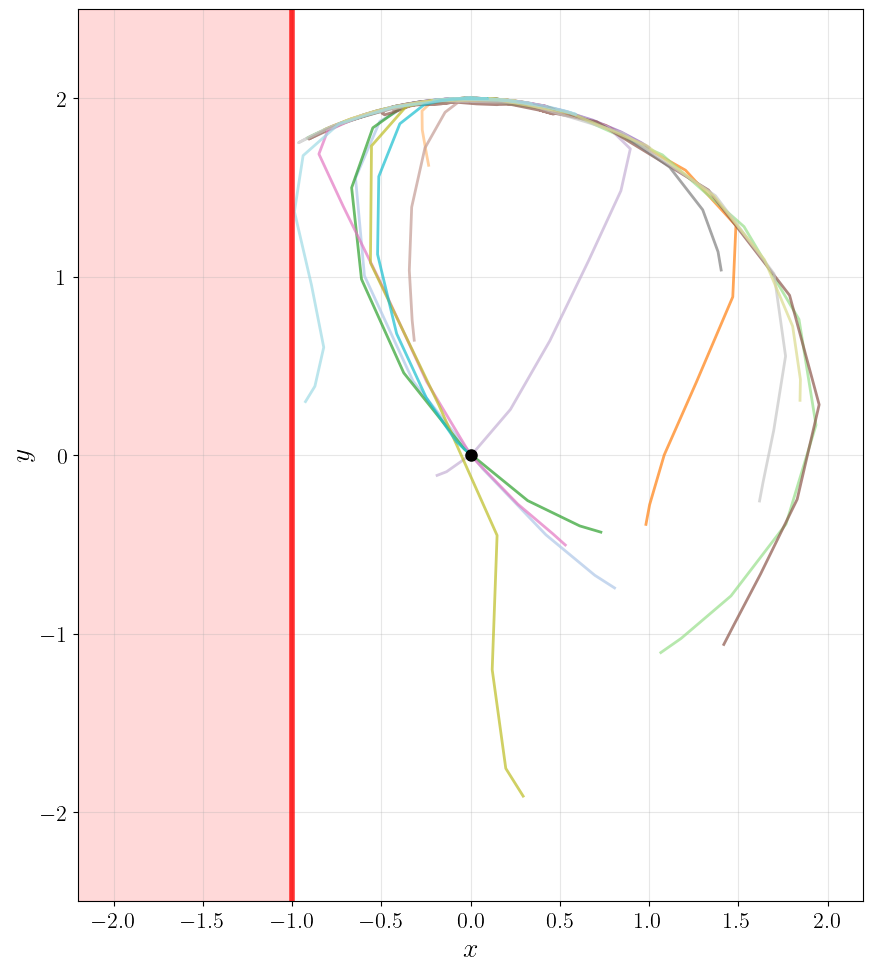

In [20]:
# %%
import numpy as np
import matplotlib.pyplot as plt
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
import warnings
warnings.filterwarnings('ignore')
import matplotlib as mpl
mpl.rc('text', usetex=True)
mpl.rc('text.latex', preamble=r'\usepackage{amsmath,amsfonts}')
mpl.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
mpl.rcParams.update({'font.size': 16})


def filter_valid_trajectories(generated_trajectories, x_threshold=-1.2):
    """
    筛选起始点X坐标大于阈值的轨迹
    """
    valid_trajectories = []
    valid_indices = []
    
    # 临时动力学模型用于计算末端执行器位置
    temp_optimizer = OneShotRobustOptimizer(DoublePendulumDynamics(), dt=0.1)
    
    for i, traj in enumerate(generated_trajectories):
        initial_state = traj['states'][0]
        ee_pos = temp_optimizer.forward_kinematics(initial_state)
        
        if ee_pos[0] > x_threshold:
            valid_trajectories.append(traj)
            valid_indices.append(i)
    
    return valid_trajectories, valid_indices

def optimize_single_trajectory(args):
    """
    优化单条轨迹的包装函数（用于并行处理）
    """
    trajectory_index, states_orig, controls_orig, x_min = args
    
    try:
        # 初始化优化器
        dyn = DoublePendulumDynamics()
        optimizer = OneShotRobustOptimizer(dyn, dt=0.1)
        
        # 运行优化
        result = optimizer.one_shot_robust_optimize(
            states_orig, controls_orig, 
            x_min=x_min,
            max_window_expansions=3, 
            verbose=False  # 关闭详细输出避免并行时混乱
        )
        
        return trajectory_index, result
        
    except Exception as e:
        print(f"Error optimizing trajectory {trajectory_index}: {e}")
        return trajectory_index, None

def generate_robust_annealing_batch(n_trajectories=20, x_min=-1.2, x_threshold=-1.2):
    """
    批量生成robust annealing优化轨迹
    """
    print(f"=== Generating {n_trajectories} Robust Annealing Trajectories ===")
    print(f"Barrier position: x_min = {x_min}")
    print(f"Starting point threshold: x > {x_threshold}")
    print("="*70)
    
    # 1. 筛选有效的原始轨迹
    print("Step 1: Filtering trajectories with valid starting points...")
    try:
        valid_trajectories, valid_indices = filter_valid_trajectories(
            generated_trajectories, x_threshold
        )
        print(f"  Found {len(valid_trajectories)} valid trajectories out of {len(generated_trajectories)}")
        
        if len(valid_trajectories) < n_trajectories:
            print(f"  Warning: Only {len(valid_trajectories)} valid trajectories available")
            n_trajectories = len(valid_trajectories)
        
    except NameError:
        print("Error: generated_trajectories not found!")
        return None
    
    # 2. 选择要优化的轨迹
    selected_indices = np.random.choice(len(valid_trajectories), n_trajectories, replace=False)
    selected_trajectories = [valid_trajectories[i] for i in selected_indices]
    selected_original_indices = [valid_indices[i] for i in selected_indices]
    
    print(f"Step 2: Selected {n_trajectories} trajectories for optimization")
    print(f"  Original indices: {selected_original_indices}")
    
    # 3. 准备并行优化任务
    print("Step 3: Starting parallel optimization...")
    optimization_tasks = []
    for i, traj in enumerate(selected_trajectories):
        task = (
            selected_original_indices[i],  # 原始索引
            traj['states'],
            traj['controls'],
            x_min
        )
        optimization_tasks.append(task)
    
    # 4. 并行执行优化
    start_time = time.time()
    successful_results = []
    failed_count = 0
    
    # 使用线程池并行处理
    with ThreadPoolExecutor(max_workers=min(8, n_trajectories)) as executor:
        # 提交所有任务
        future_to_index = {
            executor.submit(optimize_single_trajectory, task): task[0] 
            for task in optimization_tasks
        }
        
        # 收集结果
        for future in as_completed(future_to_index):
            traj_index = future_to_index[future]
            try:
                original_index, result = future.result()
                
                if result is not None and result['success']:
                    # 计算最终高度（如果结果中没有）
                    if 'final_height' not in result:
                        final_state = result['states'][-1]
                        temp_optimizer = OneShotRobustOptimizer(DoublePendulumDynamics(), dt=0.1)
                        ee_pos = temp_optimizer.forward_kinematics(final_state)
                        result['final_height'] = ee_pos[1]
                    
                    successful_results.append({
                        'original_index': original_index,
                        'result': result
                    })
                    print(f"  ✓ Trajectory {original_index}: Success "
                          f"(CBF: {result.get('cbf_violations', 0)}, "
                          f"Height: {result.get('final_height', 0):.3f})")
                else:
                    failed_count += 1
                    if result is not None:
                        print(f"  ✗ Trajectory {original_index}: Failed "
                              f"(CBF: {result.get('cbf_violations', 0)}, "
                              f"Height: {result.get('final_height', 0):.3f})")
                    else:
                        print(f"  ✗ Trajectory {original_index}: Error during optimization")
                        
            except Exception as e:
                failed_count += 1
                print(f"  ✗ Trajectory {traj_index}: Exception - {e}")
    
    total_time = time.time() - start_time
    
    print(f"\nStep 4: Optimization completed in {total_time:.2f}s")
    print(f"  Successful: {len(successful_results)}")
    print(f"  Failed: {failed_count}")
    print(f"  Success rate: {len(successful_results)/n_trajectories*100:.1f}%")
    
    return successful_results, x_min

def plot_robust_annealing_batch(results, x_min):
    """
    绘制批量robust annealing结果 - 仅显示末端执行器轨迹
    """
    if not results:
        print("No successful results to plot!")
        return
    
    print(f"\nPlotting {len(results)} successful trajectories...")
    
    # 创建单个图形
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    
    # 颜色映射
    colors = plt.cm.tab20(np.linspace(0, 1, len(results)))
    
    # 计算末端执行器轨迹
    def compute_ee_trajectory(states, l1=1.0, l2=1.0):
        ee_positions = []
        for state in states:
            θ1, θ2 = state[0], state[1]
            x1 = l1 * np.sin(θ1)
            y1 = -l1 * np.cos(θ1)
            x2 = x1 + l2 * np.sin(θ2)
            y2 = y1 - l2 * np.cos(θ2)
            ee_positions.append([x2, y2])
        return np.array(ee_positions)
    
    # 绘制所有轨迹
    for i, result_data in enumerate(results):
        result = result_data['result']
        
        # 计算末端执行器轨迹
        ee_traj = compute_ee_trajectory(result['states'])
        
        # 绘制轨迹（无标签，无标记点）
        ax.plot(ee_traj[:, 0], ee_traj[:, 1], 
                color=colors[i], linewidth=2, alpha=0.7)
    
    # 添加障碍物和约束
    ax.axvline(x=x_min, color='red', linestyle='-', linewidth=4, alpha=0.8, label='Barrier')
    ax.fill_betweenx([-2.5, 2.5], -3, x_min, alpha=0.15, color='red', label='Forbidden Zone')
    
    # 设置图形属性
    #ax.set_xlabel('X Position (m)', fontsize=14)
    ax.set_xlabel(r'$x$', fontsize=20)
    #ax.set_ylabel('Y Position (m)', fontsize=14)
    ax.set_ylabel(r'$y$', fontsize=20)
    #ax.set_title(f'End-Effector Trajectories ({len(results)} trajectories)', fontsize=16, fontweight='bold')
    #ax.legend(fontsize=12, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.5, 2.5)
    ax.plot(0, 0, marker='o', markersize=8, color='black')
    
    plt.tight_layout()
    plt.show()

# 主执行函数
def run_robust_annealing_batch():
    """
    运行批量robust annealing优化的主函数
    """
    # 检查数据可用性
    try:
        if 'generated_trajectories' not in globals():
            print("Error: generated_trajectories not found!")
            print("Please make sure the MPC trajectory data is loaded first.")
            return None
    except:
        print("Error: Cannot access generated_trajectories!")
        return None
    
    # 参数设置
    N_TRAJECTORIES = 20
    X_MIN_BARRIER = -1.0
    X_THRESHOLD = -1.0
    
    print(f"Starting batch optimization with parameters:")
    print(f"  Number of trajectories: {N_TRAJECTORIES}")
    print(f"  Barrier position: {X_MIN_BARRIER}")
    print(f"  Starting point threshold: > {X_THRESHOLD}")
    
    # 生成优化轨迹
    results, x_min = generate_robust_annealing_batch(
        n_trajectories=N_TRAJECTORIES,
        x_min=X_MIN_BARRIER,
        x_threshold=X_THRESHOLD
    )
    
    if results:
        # 绘制结果
        plot_robust_annealing_batch(results, x_min)
        return results
    else:
        print("No successful results to display!")
        return None

# 运行批量优化
if __name__ == "__main__":
    results = run_robust_annealing_batch()
    #

Starting End Effector RMSE Benchmark...
Error: Required classes not found - name 'OneShotRobustOptimizer' is not defined
